# Avance 1. Arquitectura, integración y selección de componentes del sistema

# Proyecto Berry-Vision

## Clasificación de arándanos defectuosos mediante visión computacional e inteligencia artificial

---

**Equipo #6**  
**Proyecto Integrador MNA**  
**Empresa:** SOLID México  
**Metodología:** CRISP-ML(Q)

---

### Integrantes del equipo

| Nombre | Matrícula |
|---|---|
| José Luis Parada Gutiérrez | A00939669 |
| Kevin Rosario Cota Rodríguez | A01796705 |
| Rolando David Villarreal Martínez | A00609894 |

Este avance mantiene el entregable comprometido en el plan de trabajo de la Semana 1: la **arquitectura completa de la máquina de clasificación por visión**. Siguiendo la recomendación del profesor, se utiliza la rúbrica del *Avance 1* como guía de estructura y cada criterio se **traduce a un componente real de la solución**.

Los cálculos son reproducibles: todos los supuestos se concentran en la celda de parámetros (§4.0) y se distinguen de los valores **medidos** sobre el dataset real entregado por SOLID México (161 fotografías y 480 recortes en la corrida registrada) y sobre una fotografía representativa de la banda. La arquitectura de referencia es la descrita en §0–§2: banda con guías, caída libre, cámaras lineales, PC *soft real-time* y salidas por DAQ.

### Correspondencia rúbrica → proyecto

| Criterio de la rúbrica (EDA) | Traducción en Berry-Vision | Sección |
|---|---|---|
| **Estructura de los datos** (forma, tipos, estadísticas, frecuencias, faltantes) | Inventario de datos y señales del sistema: imagen cruda, recortes 200×200, metadatos y E/S digitales, incluyendo tipo, tamaño, frecuencia y flujo. También se analiza la estructura del dataset real: fotografías, recortes, tamaños, estadísticas y fotografías sin detección como equivalente de valores faltantes. | 3, 4.2–4.4 |
| **Análisis univariante** (histogramas, boxplots, barras) | Análisis individual de cada subsistema: cámara, iluminación, cómputo, comunicaciones, control y actuadores, junto con su dimensionamiento. Se estudia además la distribución de tamaño, color y calidad de los recortes, el histograma promedio y la paleta de colores. | 4.5, 5 |
| **Análisis bi/multivariante** (correlaciones) | Relaciones entre resolución ↔ defecto mínimo, velocidad ↔ desenfoque ↔ exposición, velocidad ↔ latencia ↔ distancia cámara-eyector y producción ↔ capacidad de inferencia. Incluye matriz de dependencias entre componentes, correlaciones, PCA, agrupamiento y deriva por orden de captura. | 4.6, 4.7, 6 |
| **Preprocesamiento** (faltantes, atípicos, cardinalidad) | Cadena de visión previa al modelo: extractor integrado, control de calidad, detección de duplicados, normalización de tamaño, partición por fotografía y plantilla de etiquetado. Para la imagen de banda se incorpora normalización de fondo y segmentación mediante *watershed*. | 4.7–4.8 |
| **Conclusiones** | Decisiones de arquitectura, riesgos y respuestas a las preguntas guía adaptadas al proyecto. | 13 |

> **Alcance.** El Avance 1 delimita las responsabilidades del equipo y de SOLID México. El equipo desarrolla el MVP: captura, preprocesamiento, inferencia, registro y visualización. SOLID México aporta el tracking físico, la parte mecánica y neumática, la HMI industrial, los actuadores y los parámetros de velocidad de producción. Este documento diseña la **arquitectura industrial objetivo** y señala qué parte corresponde al MVP (§8, tabla de mapeo).

### Contenido

0. Descripcion de Operación
1. Arquitectura  
2. Memoria de cálculos  
3. Datos y señales del sistema
4. Dataset real y preprocesamiento
5. Dimensionamiento de subsistemas
6. Relaciones entre parámetros
7. Presupuesto de latencia y sincronización
8. Arquitectura general y flujo de información
9. Selección de componentes
10. Comunicaciones y E/S
11. HMI
12. Manejo de errores, seguridad, trazabilidad, escalabilidad y riesgos
13. Conclusiones


## 0. Descripción de la operación

### Funcionamiento del equipo de visión

Berry-Vision se plantea como un sistema de clasificación de bajo costo basado en una computadora con arquitectura soft real-time, buscando evitar el uso de un sistema operativo de tiempo real. Se pretende que un programa principal **Main** coordine y supervise los diferentes procesos, ejecutándolos de manera asíncrona y asignando tareas específicas a distintos núcleos del CPU para reducir interferencias y mejorar los tiempos de ejecución.

Los arándanos serán transportados mediante una **banda con guías aproximadamente cada 2 cm**, cuya función será mantenerlos ordenados y conducirlos hacia el centro de los canales de eyección. Al final de la banda, los frutos entrarán en una zona de **caída libre**, donde se realizará la inspección por visión antes de que alcancen el punto de clasificación.

La **adquisición de imágenes** se realizará mediante una cámara lineal de **4096 píxeles de ancho**, funcionando de manera similar a un escáner: adquirirá líneas sucesivas mientras los arándanos se encuentran en caída libre. Se busca que un programa desarrollado en C/C++ realice la adquisición y transfiera continuamente los bloques de imagen a Python mediante memoria compartida.

El algoritmo de **procesamiento de imagen** deberá concatenar los bloques recibidos y conservar parte de la imagen anterior cuando un fruto quede incompleto entre bloques. Posteriormente deberá convertir la imagen a escala de grises, segmentar los frutos, detectar sus contornos y obtener para cada arándano su posición, radio y un recorte individual normalizado a **200×200 píxeles**.

Estos recortes se enviarán a una **red neuronal convolucional (CNN)** que inicialmente deberá clasificar cada fruto como **bueno o malo**. Se busca que **Main** mantenga asociada cada predicción con la posición correspondiente del fruto para conservar su trazabilidad espacial durante el procesamiento y posteriormente relacionarla con la acción física de clasificación.

Debido a que los arándanos continúan desplazándose durante la caída libre, el sistema deberá realizar la adquisición, procesamiento, inferencia y generación de acciones en un tiempo suficientemente corto para que la decisión esté disponible antes de que el fruto alcance la zona de eyección. Por esta razón, la velocidad de ejecución de los diferentes algoritmos y la distribución de tareas entre núcleos del CPU son elementos críticos del diseño.

El algoritmo **set_actions** deberá transformar la posición de los frutos clasificados como malos en una matriz de acciones de salida. Estas acciones se convertirán en palabras binarias y se almacenarán en un **buffer circular de memoria compartida**, permitiendo que el procesamiento de visión continúe independientemente de la ejecución física de las salidas.

El proceso **actions** deberá ejecutar las acciones con temporización de alta resolución desde la computadora y controlar directamente tarjetas de adquisición de datos de entradas y salidas mediante las APIs de **Advantech y NI**.

Los arándanos clasificados como defectuosos serán rechazados mediante **chorros de aire controlados por electroválvulas**. La posición de cada fruto, junto con las guías mecánicas de la banda, permitirá determinar qué salida deberá activarse para desviar el arándano correspondiente. Los frutos clasificados como buenos continuarán su trayectoria sin activar el sistema de rechazo.

Para la comunicación interna se pretende utilizar dos mecanismos. **SQLite** se utilizará para parámetros de operación y comunicación con el HMI, mientras que la **memoria compartida** se utilizará para la información que necesite intercambiarse rápidamente entre los diferentes procesos. El HMI escribirá parámetros en la base de datos y **Main** deberá detectar estos cambios y ejecutar las acciones correspondientes.

El programa **Main** deberá supervisar continuamente la adquisición, procesamiento de imagen, inferencia, generación de acciones, E/S, comunicación SQL y almacenamiento. También deberá monitorear los procesos críticos mediante mecanismos como heartbeat para detectar fallas y reiniciar aquellos procesos que dejen de responder.

Los recortes y resultados de clasificación podrán almacenarse para **auditoría, trazabilidad y futuro reentrenamiento de la red neuronal**, permitiendo utilizar información obtenida durante la operación real para mejorar posteriormente el modelo.

**Flujo general propuesto:**  
Banda con guías → caída libre → cámara lineal → adquisición → memoria compartida → procesamiento de imagen → recortes 200×200 → CNN → trazabilidad espacial → set_actions → buffer circular → actions → módulos NI/Advantech → electroválvulas → eyección por aire, mientras SQLite + HMI + Main administrarán los parámetros, monitoreo y supervisión general del sistema.

## 1. Arquitectura

In [1]:
# ============================================================
# BERRY-VISION - CONFIGURACIÓN DE DIAGRAMAS
# ============================================================

!apt-get -qq install graphviz > /dev/null
!pip -q install graphviz

from graphviz import Digraph
from IPython.display import display, HTML, Markdown
import re
import os, time, math, warnings
import seaborn as sns

warnings.filterwarnings("ignore")


def diagrama(
    nombre,
    titulo,
    nodos,
    conexiones,
    rankdir="TB",
    escala=70,
    alineacion="center"
):

    # --------------------------------------------------------
    # CREAR DIAGRAMA
    # --------------------------------------------------------

    g = Digraph(nombre, format="svg")

    g.attr(
        rankdir=rankdir,
        bgcolor="transparent",
        nodesep="0.25",
        ranksep="0.35",
        pad="0.10"
    )

    # --------------------------------------------------------
    # NODOS
    # --------------------------------------------------------

    g.attr(
        "node",
        shape="box",
        style="rounded",
        fontname="Helvetica",
        fontsize="9",
        margin="0.08,0.05"
    )

    # --------------------------------------------------------
    # CONEXIONES
    # --------------------------------------------------------

    g.attr(
        "edge",
        fontname="Helvetica",
        fontsize="8",
        arrowsize="0.65"
    )

    # --------------------------------------------------------
    # AGREGAR NODOS
    # --------------------------------------------------------

    for ID, texto in nodos.items():
        g.node(ID, texto)

    # --------------------------------------------------------
    # AGREGAR CONEXIONES
    # --------------------------------------------------------

    for c in conexiones:

        if len(c) == 2:

            g.edge(
                c[0],
                c[1]
            )

        else:

            g.edge(
                c[0],
                c[1],
                label=c[2]
            )

    # --------------------------------------------------------
    # GENERAR SVG
    # --------------------------------------------------------

    svg = g.pipe(format="svg").decode("utf-8")

    # --------------------------------------------------------
    # ALINEACIÓN
    # --------------------------------------------------------

    if alineacion == "left":

        margen_svg = "0 auto 0 0"
        alineacion_div = "left"

    elif alineacion == "right":

        margen_svg = "0 0 0 auto"
        alineacion_div = "right"

    else:

        margen_svg = "0 auto"
        alineacion_div = "center"

    # --------------------------------------------------------
    # MODIFICAR TAMAÑO DEL SVG
    # --------------------------------------------------------

    svg = re.sub(
        r'<svg width="[^"]+" height="[^"]+"',
        (
            f'<svg '
            f'style="'
            f'width:{escala}%; '
            f'height:auto; '
            f'display:block; '
            f'margin:{margen_svg};'
            f'"'
        ),
        svg,
        count=1
    )

    # --------------------------------------------------------
    # MOSTRAR TÍTULO
    # --------------------------------------------------------

    display(
        Markdown(
            f"### {titulo}"
        )
    )

    # --------------------------------------------------------
    # MOSTRAR DIAGRAMA
    # --------------------------------------------------------

    display(
        HTML(
            f"""
            <div style="
                width:20%;
                overflow:visible;
                text-align:{alineacion_div};
                padding:10px 0px;
            ">
                {svg}
            </div>
            """
        )
    )

In [2]:
# ============================================================
# 1. ARQUITECTURA GENERAL BERRY-VISION
# ============================================================

nodos = {
    "banda":
        "Banda transportadora\nGuías ~2 cm",

    "caida":
        "Caída libre",

    "camara":
        "Cámara lineal\n4096 px",

    "cpp":
        "Adquisición\nC / C++",

    "mem_img":
        "Shared Memory\nImagen",

    "acquire":
        "image_acquire.py",

    "main":
        "MAIN\nCoordinación",

    "process":
        "image_processing.py\nDetección + recortes",

    "cnn":
        "CNN\nBueno / Malo",

    "set":
        "set_actions.py",

    "buffer":
        "Shared Memory\nBuffer circular",

    "actions":
        "actions.py\nSoft real-time",

    "io":
        "DAQ\nAdvantech / NI",

    "valv":
        "Electroválvulas",

    "aire":
        "Eyección por aire",

    "sql":
        "SQLite\nTEST.db",

    "sqlpy":
        "sql.py",

    "param":
        "Shared Memory\nParámetros",

    "hmi":
        "HMI",

    "save":
        "save.py\nGood / Bad"
}


conexiones = [
    ("banda", "caida"),
    ("caida", "camara"),

    ("camara", "cpp"),
    ("cpp", "mem_img"),
    ("mem_img", "acquire"),
    ("acquire", "main"),

    ("main", "process"),
    ("process", "main", "posición + recortes"),

    ("main", "cnn"),
    ("cnn", "main", "predicciones"),

    ("main", "set"),
    ("set", "buffer"),
    ("buffer", "actions"),

    ("actions", "io"),
    ("io", "valv"),
    ("valv", "aire"),

    ("hmi", "sql", "escribe"),
    ("sql", "sqlpy"),
    ("sqlpy", "param"),
    ("param", "main"),

    ("main", "save")
]


diagrama(
    "arquitectura_general",
    "Arquitectura general Berry-Vision",
    nodos,
    conexiones,
    "LR",
    escala=400,
    alineacion="left"
)

### Arquitectura general Berry-Vision

In [3]:
# ============================================================
# 2. MAIN
# ============================================================

nodos = {
    "ini":
        "Inicio",

    "cpu":
        "Asignar CPU\n"
        "Crear Pool + heartbeat",

    "model":
        "Inicializar modelo\n"
        "Test / CNN",

    "sql":
        "Inicializar SQL",

    "actions":
        "Iniciar actions.py",

    "cpp":
        "Iniciar acquire.exe\n"
        "si no está en TEST_MODE",

    "mem":
        "Abrir SharedMemory\n"
        "C++ ↔ Python",

    "loop":
        "Loop principal",

    "sqlread":
        "Leer cambios SQL",

    "acq":
        "Ejecutar\n"
        "image_acquire",

    "proc":
        "Ejecutar\n"
        "image_processing",

    "nn":
        "Ejecutar CNN",

    "set":
        "Ejecutar\n"
        "set_actions",

    "save":
        "Guardar imágenes\n"
        "si está habilitado",

    "heart":
        "Heartbeat\n"
        "supervisión actions",

    "end":
        "Cerrar procesos"
}


conexiones = [
    ("ini", "cpu"),
    ("cpu", "model"),
    ("model", "sql"),
    ("sql", "actions"),
    ("actions", "cpp"),
    ("cpp", "mem"),
    ("mem", "loop"),

    ("loop", "sqlread"),
    ("sqlread", "acq"),
    ("acq", "proc"),
    ("proc", "nn"),
    ("nn", "set"),
    ("set", "save"),
    ("save", "heart"),

    ("heart", "loop", "continuar"),
    ("loop", "end", "Terminate Program")
]


diagrama(
    "main",
    "MainVision2026.py",
    nodos,
    conexiones
)

### MainVision2026.py

In [4]:
# ============================================================
# 3. IMAGE ACQUIRE
# ============================================================

nodos = {
    "ini":
        "image_acquire()",

    "cpu":
        "Afinidad CPU",

    "test":
        "¿TEST_MODE?",

    "file":
        "Leer imagen\n"
        "de prueba",

    "shared":
        "Leer SharedMemory\n"
        "C/C++",

    "reshape":
        "Convertir a\n"
        "100 × 4096 × 3",

    "buffer":
        "Agregar bloque a\n"
        "unique_colors_list",

    "ret":
        "Retornar bloques"
}

conexiones = [
    ("ini", "cpu"),
    ("cpu", "test"),

    ("test", "file", "Sí"),
    ("test", "shared", "No"),

    ("file", "buffer"),

    ("shared", "reshape"),
    ("reshape", "buffer"),

    ("buffer", "ret")
]

diagrama(
    "image_acquire",
    "image_acquire.py",
    nodos,
    conexiones
)

### image_acquire.py

In [5]:
# ============================================================
# 4. IMAGE PROCESSING
# ============================================================

nodos = {
    "ini":
        "image_processing()",

    "concat":
        "Concatenar bloques\n"
        "+ imagen anterior",

    "gray":
        "Convertir a\n"
        "escala de grises",

    "threshold":
        "Threshold",

    "contours":
        "Detectar contornos",

    "geo":
        "Calcular\n"
        "x, y y radio",

    "filter":
        "Filtrar objetos\n"
        "radio > 50 px",

    "crop":
        "Recorte individual",

    "resize":
        "Resize\n"
        "200 × 200",

    "tensor":
        "Crear tensor\n"
        "para CNN",

    "track":
        "Guardar posición\n"
        "guide_matrix + radio",

    "overlap":
        "Conservar parte final\n"
        "para siguiente bloque",

    "ret":
        "Retornar objetos,\n"
        "recortes y posición"
}

conexiones = [
    ("ini", "concat"),
    ("concat", "gray"),
    ("gray", "threshold"),
    ("threshold", "contours"),
    ("contours", "geo"),
    ("geo", "filter"),
    ("filter", "crop"),
    ("crop", "resize"),
    ("resize", "tensor"),
    ("tensor", "track"),
    ("track", "overlap"),
    ("overlap", "ret")
]

diagrama(
    "image_processing",
    "image_processing.py",
    nodos,
    conexiones
)

### image_processing.py

In [6]:
# ============================================================
# 5. RED NEURONAL - PENDIENTE
# ============================================================

nodos = {
    "in":
        "Recortes\n"
        "200 × 200",

    "cnn":
        "Red neuronal\n"
        "CNN",

    "pred":
        "Predicción",

    "good":
        "0 = Bueno",

    "bad":
        "1 = Malo"
}

conexiones = [
    ("in", "cnn"),
    ("cnn", "pred"),
    ("pred", "good"),
    ("pred", "bad")
]

diagrama(
    "neural_network",
    "neural_network.py - Pendiente",
    nodos,
    conexiones
)

### neural_network.py - Pendiente

In [7]:
# ============================================================
# 6. SET ACTIONS
# ============================================================

nodos = {
    "ini":
        "set_actions()",

    "input":
        "Posición + radio\n"
        "+ predicción",

    "matrix":
        "Crear\n"
        "outputs_matrix",

    "bad":
        "¿Fruto malo?",

    "mark":
        "Marcar zona\n"
        "de eyección",

    "bits":
        "Convertir fila a\n"
        "value1 / value2 / value3",

    "indexes":
        "Calcular índices\n"
        "de escritura",

    "buffer":
        "Escribir en\n"
        "buffer circular",

    "publish":
        "Actualizar\n"
        "write_index_end"
}

conexiones = [
    ("ini", "input"),
    ("input", "matrix"),
    ("matrix", "bad"),

    ("bad", "mark", "Sí"),
    ("bad", "bits", "No"),

    ("mark", "bits"),
    ("bits", "indexes"),
    ("indexes", "buffer"),
    ("buffer", "publish")
]

diagrama(
    "set_actions",
    "set_actions.py",
    nodos,
    conexiones
)

### set_actions.py

In [8]:
# ============================================================
# 7. ACTIONS
# ============================================================

nodos = {
    "ini":
        "actions()",

    "cpu":
        "Afinidad CPU",

    "daq":
        "Inicializar módulos\n"
        "Advantech / NI",

    "loop":
        "Loop continuo",

    "mode":
        "¿Manual / Automático?",

    "manual":
        "Leer valores\n"
        "manuales",

    "timer":
        "Temporización\n"
        "perf_counter_ns",

    "buffer":
        "Leer siguiente acción\n"
        "del buffer circular",

    "values":
        "value1\n"
        "value2\n"
        "value3",

    "bytes":
        "Convertir a bytes",

    "outputs":
        "Escribir salidas\n"
        "DAQ",

    "watch":
        "Supervisión\n"
        "heartbeat",

    "end":
        "Cerrar DAQ"
}

conexiones = [
    ("ini", "cpu"),
    ("cpu", "daq"),
    ("daq", "loop"),
    ("loop", "mode"),

    ("mode", "manual", "Manual"),
    ("mode", "timer", "Automático"),

    ("timer", "buffer"),

    ("manual", "values"),
    ("buffer", "values"),

    ("values", "bytes"),
    ("bytes", "outputs"),
    ("outputs", "watch"),

    ("watch", "loop", "OK"),
    ("watch", "end", "Timeout")
]

diagrama(
    "actions",
    "actions.py",
    nodos,
    conexiones
)

### actions.py

In [9]:
# ============================================================
# 8. SQL
# ============================================================

nodos = {
    "ini":
        "sql()",

    "cpu":
        "Afinidad CPU",

    "db":
        "Abrir TEST.db",

    "mode":
        "¿read_all?",

    "all":
        "Leer todos\n"
        "los parámetros",

    "active":
        "Leer registros\n"
        "ACTIVE = 1",

    "values":
        "Actualizar\n"
        "parametros_db",

    "addr":
        "Actualizar\n"
        "address_db",

    "clear":
        "ACTIVE = 0",

    "close":
        "Cerrar DB",

    "return":
        "Retornar flag"
}

conexiones = [
    ("ini", "cpu"),
    ("cpu", "db"),
    ("db", "mode"),

    ("mode", "all", "Sí"),
    ("mode", "active", "No"),

    ("all", "values"),
    ("active", "values"),

    ("values", "addr"),
    ("addr", "clear"),
    ("clear", "close"),
    ("close", "return")
]

diagrama(
    "sql",
    "sql.py",
    nodos,
    conexiones
)

### sql.py

In [10]:
# ============================================================
# 9. ACTIONS DATA
# ============================================================

nodos = {
    "ini":
        "ActionsDATA.py",

    "names":
        "Definir nombres\n"
        "de SharedMemory",

    "flags":
        "Definir\n"
        "FLAGS_DTYPE",

    "actions":
        "Definir\n"
        "ACTIONS_DTYPE",

    "sizes":
        "Calcular tamaños\n"
        "de memoria",

    "viewer":
        "Mostrar estructura\n"
        "si se ejecuta directamente"
}

conexiones = [
    ("ini", "names"),
    ("names", "flags"),
    ("flags", "actions"),
    ("actions", "sizes"),
    ("sizes", "viewer")
]

diagrama(
    "actions_data",
    "ActionsDATA.py",
    nodos,
    conexiones
)

### ActionsDATA.py

In [11]:
# ============================================================
# 10. SAVE
# ============================================================

nodos = {
    "ini":
        "save()",

    "cpu":
        "Afinidad CPU",

    "folders":
        "Revisar carpetas\n"
        "good / bad",

    "index":
        "Calcular siguiente\n"
        "índice disponible",

    "loop":
        "Por cada recorte",

    "pred":
        "¿Predicción?",

    "good":
        "Guardar en good",

    "bad":
        "Guardar en bad"
}

conexiones = [
    ("ini", "cpu"),
    ("cpu", "folders"),
    ("folders", "index"),
    ("index", "loop"),
    ("loop", "pred"),

    ("pred", "good", "0"),
    ("pred", "bad", "1")
]

diagrama(
    "save",
    "save.py",
    nodos,
    conexiones
)

### save.py

## 2. Memoria de Calculo

En esta memoria de cálculo se determina la velocidad de adquisición requerida para la cámara lineal en función de la velocidad de la banda transportadora y de la resolución longitudinal deseada. Para este sistema se establece como criterio de diseño obtener **10 líneas de imagen por cada milímetro de desplazamiento del arándano**.

Debido a que se utiliza una cámara lineal, la velocidad de adquisición se expresa como **line rate**, es decir, el número de líneas capturadas por segundo. Este valor se obtiene multiplicando la velocidad de la banda, convertida a milímetros por segundo, por la cantidad de líneas requeridas por milímetro:

**Line rate [líneas/s] = Velocidad de banda [mm/s] × 10 líneas/mm**

A partir de esta relación, la memoria de cálculo permite determinar el *line rate* mínimo requerido para cada velocidad de operación de la banda. De manera complementaria, se calcula el tiempo disponible entre la adquisición de líneas consecutivas, con el objetivo de verificar que la capacidad de la cámara, el tiempo de exposición y el sistema de iluminación sean compatibles con las condiciones de operación seleccionadas.

El simulador realiza estos cálculos automáticamente al modificar la velocidad de la banda, permitiendo evaluar el desempeño requerido del sistema de visión para mantener una resolución constante de **10 líneas/mm**.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets

G = 9.81
ALTURA_FOTO = 0.20      # m
ALTURA_RECHAZO = 0.30   # m
ALTURA_ZONA = 0.42      # m, altura visual donde se muestran las zonas de destino
FRAMES_POR_MM = 10       # líneas/frames capturados por cada mm de avance

print('Simulador actualizado correctamente.')

Simulador actualizado correctamente.


In [13]:
def calcular_eventos(velocidad_banda, altura_foto=ALTURA_FOTO, altura_rechazo=ALTURA_RECHAZO):
    t_foto = np.sqrt(2 * altura_foto / G)
    t_rechazo = np.sqrt(2 * altura_rechazo / G)

    x_foto = velocidad_banda * t_foto
    x_rechazo = velocidad_banda * t_rechazo

    dt = t_rechazo - t_foto
    dx = x_rechazo - x_foto

    vy_foto = G * t_foto
    vy_rechazo = G * t_rechazo

    return {
        't_foto': t_foto,
        't_rechazo': t_rechazo,
        'x_foto': x_foto,
        'x_rechazo': x_rechazo,
        'dt': dt,
        'dx': dx,
        'vy_foto': vy_foto,
        'vy_rechazo': vy_rechazo,
    }


def simulador(velocidad_banda_m_s=1.0):
    datos = calcular_eventos(velocidad_banda_m_s)

    velocidad_mm_s = velocidad_banda_m_s * 1000.0
    fps_requeridos = velocidad_mm_s * FRAMES_POR_MM
    tiempo_entre_frames_us = 1e6 / fps_requeridos if fps_requeridos > 0 else 0

    # Se extiende la trayectoria hasta una zona inferior para visualizar mejor la caída final
    t_final = np.sqrt(2 * ALTURA_ZONA / G)
    t = np.linspace(0, t_final, 300)
    x = velocidad_banda_m_s * t
    y = 0.5 * G * t**2

    fig, ax = plt.subplots(figsize=(11, 6.5))

    # Banda
    largo_banda = max(0.20, datos['x_rechazo'] * 0.25)
    ax.plot([-largo_banda, 0], [0, 0], linewidth=8, label='Banda transportadora')

    # Trayectoria natural del arándano
    ax.plot(x, y, linewidth=2.5, label='Trayectoria natural del arándano')

    # Arándano al salir
    ax.scatter([0], [0], s=220, zorder=5, label='Arándano')

    # Punto de fotografía
    ax.scatter([datos['x_foto']], [ALTURA_FOTO], s=150, marker='s', zorder=6,
               label='Fotografía')
    ax.axhline(ALTURA_FOTO, linestyle='--', linewidth=1)

    # Punto de rechazo
    ax.scatter([datos['x_rechazo']], [ALTURA_RECHAZO], s=180, marker='X', zorder=6,
               label='Rechazo por aire')
    ax.axhline(ALTURA_RECHAZO, linestyle='--', linewidth=1)

    # Línea vertical separadora entre buenos y defectuosos
    x_separador = datos['x_rechazo']
    ax.vlines(x_separador, ALTURA_RECHAZO - 0.01, ALTURA_ZONA,
              linestyles='-.', linewidth=2,
              label='Separación buenos / defectuosos')

    # Trayectoria ilustrativa del rechazo por aire hacia la izquierda
    x_rechazo_aire = np.linspace(datos['x_rechazo'], max(0.0, datos['x_rechazo'] - max(0.05, datos['dx'] * 1.1)), 40)
    y_rechazo_aire = np.linspace(ALTURA_RECHAZO, ALTURA_ZONA, 40)
    ax.plot(x_rechazo_aire, y_rechazo_aire, linestyle=':', linewidth=2,
            label='Trayectoria estimada por soplado')

    # Etiquetas de zonas
    ax.text(x_separador - max(0.015, datos['x_rechazo'] * 0.04), ALTURA_ZONA - 0.01,
            'Zona\ndefectuosos', ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.25', alpha=0.15))
    ax.text(x_separador + max(0.015, datos['x_rechazo'] * 0.04), ALTURA_ZONA - 0.01,
            'Zona\nbuenos', ha='left', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.25', alpha=0.15))

    # Texto de FOTO: arriba de la línea de foto para evitar cruce con rechazo
    ax.annotate(
        f'FOTO\n20 cm\nt = {datos["t_foto"]*1000:.1f} ms\nx = {datos["x_foto"]*1000:.1f} mm',
        (datos['x_foto'], ALTURA_FOTO),
        xytext=(0, 48), textcoords='offset points',
        ha='center', va='bottom',
        arrowprops=dict(arrowstyle='->')
    )

    # Texto de RECHAZO: a la derecha y más abajo para no interponerse con FOTO
    ax.annotate(
        f'RECHAZO\n30 cm\nt = {datos["t_rechazo"]*1000:.1f} ms\nx = {datos["x_rechazo"]*1000:.1f} mm',
        (datos['x_rechazo'], ALTURA_RECHAZO),
        xytext=(26, -8), textcoords='offset points',
        ha='left', va='top',
        arrowprops=dict(arrowstyle='->')
    )

    x_hasta_zona = velocidad_banda_m_s * t_final
    margen_x = max(0.08, x_hasta_zona * 0.20)
    ax.set_xlim(-largo_banda * 1.15, x_hasta_zona + margen_x)
    ax.set_ylim(-0.04, ALTURA_ZONA + 0.03)
    ax.invert_yaxis()

    ax.set_xlabel('Distancia horizontal x [m]')
    ax.set_ylabel('Caída vertical desde la banda [m]')
    ax.set_title(
        f'Caída del arándano — banda = {velocidad_banda_m_s:.2f} m/s | '
        f'Cámara = {fps_requeridos:,.0f} líneas/s'
    )
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best')
    plt.show()

    print('RESULTADOS')
    print('----------------------------------------------')
    print(f'Velocidad de banda          : {velocidad_banda_m_s:.3f} m/s')
    print(f'Resolución longitudinal     : {FRAMES_POR_MM:.1f} frames/mm')
    print(f'FPS / line rate requerido   : {fps_requeridos:,.1f} líneas/s')
    print(f'Tiempo entre líneas         : {tiempo_entre_frames_us:.3f} µs')
    print(f'Tiempo hasta fotografía     : {datos["t_foto"]*1000:.3f} ms')
    print(f'Posición X de fotografía    : {datos["x_foto"]*1000:.3f} mm')
    print(f'Tiempo hasta rechazo        : {datos["t_rechazo"]*1000:.3f} ms')
    print(f'Posición X de rechazo       : {datos["x_rechazo"]*1000:.3f} mm')
    print(f'Tiempo FOTO -> RECHAZO      : {datos["dt"]*1000:.3f} ms')
    print(f'Distancia X FOTO -> RECHAZO : {datos["dx"]*1000:.3f} mm')
    print(f'Velocidad vertical en FOTO  : {datos["vy_foto"]:.3f} m/s')
    print(f'Velocidad vertical rechazo  : {datos["vy_rechazo"]:.3f} m/s')


slider_velocidad = widgets.FloatSlider(
    value=1.0,
    min=0.10,
    max=5.00,
    step=0.05,
    description='Banda [m/s]:',
    continuous_update=False,
    readout_format='.2f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='600px')
)

widgets.interact(simulador, velocidad_banda_m_s=slider_velocidad);

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Banda [m/s]:', layout=Layou…

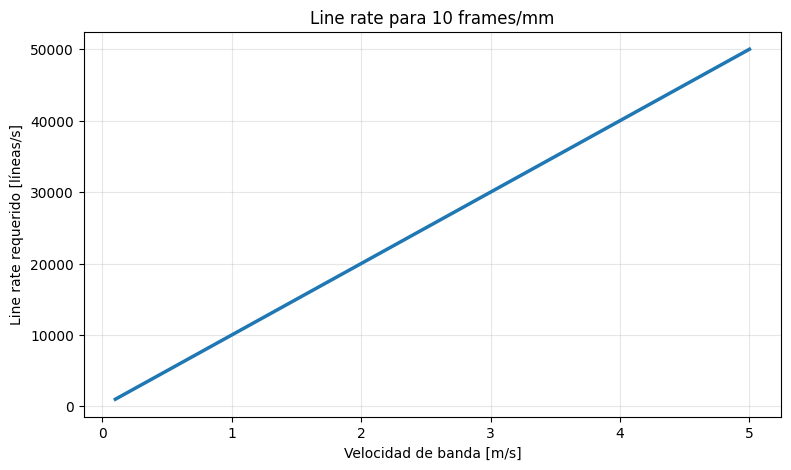

In [14]:
velocidades = np.linspace(0.1, 5.0, 100)
fps = velocidades * 1000 * FRAMES_POR_MM

plt.figure(figsize=(9, 5))
plt.plot(velocidades, fps, linewidth=2.5)
plt.xlabel('Velocidad de banda [m/s]')
plt.ylabel('Line rate requerido [líneas/s]')
plt.title(f'Line rate para {FRAMES_POR_MM} frames/mm')
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
VELOCIDAD_ANIMACION = 1.0  # m/s

def animar_caida(velocidad_banda=1.0):
    datos = calcular_eventos(velocidad_banda)
    t_final = np.sqrt(2 * ALTURA_ZONA / G)
    t = np.linspace(0, t_final, 120)
    x = velocidad_banda * t
    y = 0.5 * G * t**2

    fig, ax = plt.subplots(figsize=(11, 6.5))

    largo_banda = max(0.20, datos['x_rechazo'] * 0.25)
    x_hasta_zona = velocidad_banda * t_final
    margen_x = max(0.08, x_hasta_zona * 0.20)
    x_separador = datos['x_rechazo']

    ax.plot([-largo_banda, 0], [0, 0], linewidth=8)
    ax.plot(x, y, linestyle='--', linewidth=1.5, label='Trayectoria natural')
    ax.axhline(ALTURA_FOTO, linestyle='--', linewidth=1)
    ax.axhline(ALTURA_RECHAZO, linestyle='--', linewidth=1)
    ax.vlines(x_separador, ALTURA_RECHAZO - 0.01, ALTURA_ZONA,
              linestyles='-.', linewidth=2, label='Separación zonas')

    ax.scatter([datos['x_foto']], [ALTURA_FOTO], s=120, marker='s', label='Foto')
    ax.scatter([datos['x_rechazo']], [ALTURA_RECHAZO], s=150, marker='X', label='Rechazo')

    ax.text(x_separador - max(0.015, datos['x_rechazo'] * 0.04), ALTURA_ZONA - 0.01,
            'Defectuosos', ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.25', alpha=0.15))
    ax.text(x_separador + max(0.015, datos['x_rechazo'] * 0.04), ALTURA_ZONA - 0.01,
            'Buenos', ha='left', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.25', alpha=0.15))

    bolita, = ax.plot([], [], marker='o', markersize=14, linestyle='None')
    recorrido, = ax.plot([], [], linewidth=2.5)
    texto_tiempo = ax.text(0.02, 0.95, '', transform=ax.transAxes, va='top')

    ax.set_xlim(-largo_banda * 1.15, x_hasta_zona + margen_x)
    ax.set_ylim(-0.04, ALTURA_ZONA + 0.03)
    ax.invert_yaxis()
    ax.set_xlabel('Distancia horizontal x [m]')
    ax.set_ylabel('Caída vertical [m]')
    ax.set_title(f'Animación — banda = {velocidad_banda:.2f} m/s')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best')

    def init():
        bolita.set_data([0], [0])
        recorrido.set_data([], [])
        texto_tiempo.set_text('t = 0.0 ms')
        return bolita, recorrido, texto_tiempo

    def update(i):
        bolita.set_data([x[i]], [y[i]])
        recorrido.set_data(x[:i+1], y[:i+1])

        evento = ''
        if abs(t[i] - datos['t_foto']) < (t[1] - t[0]):
            evento = '  |  FOTO'
        if abs(t[i] - datos['t_rechazo']) < (t[1] - t[0]):
            evento = '  |  RECHAZO'

        texto_tiempo.set_text(f't = {t[i]*1000:.1f} ms{evento}')
        return bolita, recorrido, texto_tiempo

    anim = FuncAnimation(
        fig,
        update,
        frames=len(t),
        init_func=init,
        interval=25,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())

display(animar_caida(VELOCIDAD_ANIMACION))

## 3. Datos y señales del sistema

La máquina de visión estará compuesta por diferentes procesos encargados de la adquisición de imágenes, procesamiento, clasificación, seguimiento de los arándanos, generación de acciones de rechazo y supervisión del sistema. Debido a que varias de estas funciones deberán ejecutarse de manera simultánea, será necesario establecer una arquitectura que permita compartir información entre los diferentes procesos de forma rápida y ordenada.

Para ello se propone utilizar principalmente **memoria compartida** y una base de datos **SQLite**, asignando a cada una funciones diferentes dentro del sistema.

La **memoria compartida** se utilizará para los datos que formen parte del proceso de tiempo real. Al encontrarse directamente en la memoria RAM de la computadora, permitirá que diferentes procesos accedan a la misma información sin necesidad de guardar archivos o realizar transferencias innecesarias de datos.

A través de memoria compartida podrán intercambiarse, por ejemplo:

- Imágenes o bloques de imagen provenientes de las cámaras.
- Estados de adquisición.
- Resultados del procesamiento de imagen.
- Resultados de clasificación.
- Posición y seguimiento de los arándanos.
- Acciones pendientes de rechazo.
- Estados y señales necesarias para coordinar los diferentes procesos.

De forma conceptual, el flujo de información será:

**Adquisición → Procesamiento de imagen → Clasificación → Seguimiento → Generación de acciones → Salidas de rechazo**

Cada etapa podrá publicar sus resultados en memoria para que la siguiente etapa los utilice, evitando que todos los procesos tengan que comunicarse directamente entre sí.

La información relacionada con las acciones de rechazo deberá mantenerse igualmente en memoria. Una vez determinada la posición y clasificación de un arándano, el sistema podrá almacenar la acción que deberá realizarse y mantenerla pendiente hasta que el producto alcance la posición física correspondiente a las electroválvulas.

Por otro lado, **SQLite** se propone para almacenar información que debe conservarse aun después de apagar o reiniciar la máquina. Su función será principalmente almacenar parámetros y configuraciones del sistema, por ejemplo:

- Parámetros de operación.
- Configuración de cámaras.
- Configuración de iluminación.
- Tiempos y parámetros de rechazo.
- Ajustes realizados desde la HMI.
- Recetas o configuraciones de producto.
- Información de producción y estadísticas que se desee conservar.

De esta manera, **SQLite funcionará como almacenamiento permanente**, mientras que la **memoria compartida funcionará como espacio de intercambio rápido de información durante la operación de la máquina**.

Al iniciar el sistema, los parámetros necesarios podrán cargarse desde SQLite hacia la memoria. Durante la operación, los diferentes procesos utilizarán principalmente la información disponible en RAM. Si algún parámetro es modificado desde la interfaz de usuario, el nuevo valor podrá actualizarse tanto en la memoria compartida como en la base de datos para conservarlo posteriormente.

La arquitectura general propuesta puede representarse como:

**SQLite → Parámetros de operación → Memoria compartida**

y para el proceso de visión:

**Cámaras → Memoria → Procesamiento → Clasificación → Memoria → Acciones de rechazo → Módulo de salidas → Electroválvulas**

Esta arquitectura permite separar las funciones de **almacenamiento**, **procesamiento** y **control en tiempo real**, evitando que operaciones relativamente lentas, como escribir en una base de datos o actualizar la interfaz gráfica, interfieran con las etapas críticas de adquisición, clasificación y rechazo.

### Inventario de datos y señales

Equivalente a describir «forma y tipos de datos» de la rúbrica: qué información circula, en qué formato, a qué ritmo y con qué volumen. Los tamaños y las tasas se justifican en la memoria de cálculo (§2) y en el dimensionamiento (§5).

La arquitectura propuesta utiliza **memoria compartida en RAM** para el intercambio de información que forma parte del proceso de tiempo real y **SQLite** para parámetros, configuraciones, eventos y datos que deban conservarse después de apagar la máquina.

El flujo general será:

**Cámaras → Memoria compartida → Procesamiento → Inferencia → Tracking → Acciones → Memoria compartida → USB-5856 → Electroválvulas**

Mientras que la información persistente seguirá el flujo:

**SQLite ↔ Parámetros / configuración ↔ Procesos de la máquina**

| ID | Dato / señal | Origen → Destino | Tipo / formato propuesto | Tamaño aproximado | Frecuencia | Observación |
|---|---|---|---|---|---|---|
| D1 | Líneas de imagen cruda | Cámaras → PC / memoria de adquisición | 4096 px × 3 canales, RGB, típicamente uint8 | ≈12.3 kB por línea y cámara | Hasta 20,000 líneas/s a 2 m/s | Es el flujo de mayor volumen. Las líneas se almacenan temporalmente en RAM para formar la imagen utilizada en procesamiento |
| D2 | Imagen / bloque de procesamiento | Adquisición → Procesamiento | Matriz NumPy en memoria RAM | Variable | Continuo | Se mantiene en memoria compartida o buffers de RAM; no debe escribirse a disco durante operación normal |
| D3 | Recorte individual de fruto | Procesamiento → Inferencia | 200×200; escala de grises en la primera fase del modelo (Avance 0), aunque el dataset conserva el color RGB; posteriormente tensor para la red neuronal | ≈40 kB (gris, uint8) / ≈120 kB (RGB, uint8) / ≈160 kB (gris, float32) | = frutos procesados/s | Entrada individual al modelo de clasificación |
| D4 | Metadatos del fruto | Procesamiento → Tracking | ID, posición, tamaño, cámara, línea/timestamp y otros datos geométricos | ≈32–64 B | = frutos/s | Permite relacionar la predicción de la red con la posición física del arándano |
| D5 | Resultado de clasificación | Inferencia → Tracking / lógica de rechazo | ID, clase y confianza | ≈8–16 B | = frutos/s | Para la primera etapa: bueno / defectuoso |
| D6 | Acción de rechazo programada | Tracking / lógica de rechazo → Memoria compartida de acciones | Canal o máscara de salidas, posición/instante objetivo y duración del pulso | ≈16–32 B | Solo frutos rechazados | No activa inmediatamente la válvula; representa una acción que deberá ejecutarse cuando el fruto alcance el punto de rechazo |
| D7 | Estado de salidas | Memoria de acciones → `actions` → USB-5856 | Máscara binaria de salidas digitales | 32 bits por USB-5856 | Según acciones programadas | `actions` consume las órdenes almacenadas en memoria y las convierte en estados físicos de salida |
| D8 | Señal de posición | Encoder → Sistema de adquisición / tracking | Pulsos A/B o pulsos de posición | — | kHz, según resolución del encoder | Recomendado para relacionar el movimiento físico con la adquisición y el rechazo. El dispositivo exacto de lectura todavía debe definirse |
| D9 | Disparo de línea | Encoder / hardware de sincronización → Cámara | Pulso digital compatible con la entrada de la cámara | — | Hasta 20 kHz para 2 m/s y 10 líneas/mm | En una cámara lineal se habla de **line trigger**, no de FPS. Permite conservar una resolución espacial constante aunque cambie la velocidad |
| D10 | Parámetros de operación | SQLite → Proceso de configuración → Memoria compartida | Valores numéricos, booleanos y configuración | Muy bajo | Inicio y cuando existe un cambio | Incluye velocidades, tiempos, parámetros de visión, iluminación, rechazo, recetas, etc. |
| D11 | Cambios desde HMI | HMI → SQLite / memoria compartida | Parámetro + valor | Muy bajo | Bajo demanda | Los cambios necesarios inmediatamente pueden actualizarse en RAM y posteriormente almacenarse en SQLite |
| D12 | Eventos y alarmas | Procesos → SQLite / HMI | Código, severidad, timestamp y descripción | ≈50–200 B | Esporádico | No debe formar parte del camino crítico de procesamiento |
| D13 | Estadísticas de producción | Procesamiento → SQLite / HMI | Conteos, porcentajes de rechazo, producción, confianza, lote | ≈1 kB por registro | Agregada, por ejemplo cada 1 s o por lote | Se utiliza para reportes y trazabilidad |

#### Criterio de uso de memoria

Los datos que necesitan ser utilizados inmediatamente por otro proceso se mantendrán principalmente en **RAM mediante memoria compartida**. Esto incluye imágenes, resultados de procesamiento, clasificaciones, posiciones de frutos y acciones pendientes de rechazo.

**SQLite no deberá utilizarse como medio de comunicación en tiempo real entre los procesos.** Su función será almacenar de manera permanente parámetros, configuraciones, eventos, estadísticas y registros de producción.

De esta manera, la información crítica sigue una trayectoria rápida:

**RAM → RAM → RAM → salida**

mientras que la información que requiere persistencia puede seguir una trayectoria más lenta:

**RAM → SQLite → almacenamiento permanente**

Esta separación permite que las operaciones de escritura en base de datos, actualización de la HMI o generación de estadísticas no retrasen la adquisición de imágenes ni la ejecución de los rechazos.

## 4. Dataset real y cadena de preprocesamiento


SOLID México entregó fotografías de arándanos y el equipo desarrolló un **extractor** (Otsu + contornos + círculo mínimo) que genera los recortes individuales. En esta sección el extractor se integra a la libreta como funciones reproducibles y se analiza el dataset resultante con la estructura de la rúbrica:

| Subsección | Contenido |
|---|---|
| 4.1 | Extractor integrado y parámetros |
| 4.2 | Inventario y consistencia de las carpetas entregadas |
| 4.3 | Ejecución del extractor: recortes, características por fruto y tiempos |
| 4.4 | **Estructura de los datos** (tamaños, tipos, estadísticas, faltantes) |
| 4.5 | **Análisis univariante** (histogramas, boxplots, histograma promedio de color, paleta) |
| 4.6 | **Análisis bi/multivariante** (correlaciones, PCA, agrupamiento sin etiquetas, tendencia por captura) |
| 4.7 | **Preprocesamiento** (calidad, duplicados, tamaño, partición, plantilla de etiquetado) |
| 4.8 | Vista de banda (foto del equipo en operación): normalización de fondo, watershed y escala de trabajo |

> El dataset llegó **sin clasificar**; el equipo lo etiquetó (bueno/malo) y el resultado se lee de `etiquetas.csv` en §4.7. El análisis de §4.4–4.6 es no supervisado y sirve para entender la estructura de los datos; las partes supervisadas (balance de clases, relevancia de características y verificación de sesgo entre clase y sesión de captura) se activan automáticamente cuando existe ese archivo.

### 4.0 Parámetros y supuestos de diseño

Importaciones, rutas y supuestos que alimentan el resto del documento. Los valores marcados como **SUPUESTO** deben validarse con SOLID México o medirse en los Avances 2 y 4; las especificaciones de componentes provienen de las hojas de datos de los fabricantes.

In [16]:
import os, time, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyBboxPatch, Rectangle
from scipy import ndimage as ndi, stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40, "display.width", 170, "display.max_colwidth", 90)

# ---- Rutas locales (la imagen NO se sube al repo: convenio de confidencialidad) ----
IMG_PATH    = Path(os.environ.get("BERRY_IMAGE", "../Datos/muestras/muestra_01.jpg"))
SHOW_IMAGES = os.environ.get("BERRY_SHOW_IMAGES", "0") == "1"   # mostrar la foto/recortes reales (False por confidencialidad)

# ---- SUPUESTOS del proceso (validar con SOLID México) ----
FRUTO_DIAM_MM      = 14.0    # diámetro típico del arándano (rango 10–20 mm; 2–6 g según Avance 0)
FRUTO_PESO_G       = 4.0     # peso medio
PRODUCCION_KG_H    = 1000.0  # capacidad objetivo del MVP/línea piloto (equipos industriales >5 000 kg/h)
VELOCIDAD_BANDA_MS = 2.0     # m/s, velocidad de diseño de la banda (el simulador de §2 permite explorar 0.1–5 m/s)
ANCHO_TOTAL_MM     = 800.0   # ancho total de inspección de la banda
ANCHO_GUIA_MM      = 20.0    # separación entre guías (~2 cm) = ancho de cada canal de eyección
LINEAS_POR_MM      = 10.0    # resolución longitudinal de la cámara lineal (§2)
DEFECTO_MIN_MM     = 1.0     # defecto más pequeño a detectar (cicatriz, flor seca, golpe)
PX_POR_DEFECTO     = 4       # píxeles mínimos que debe abarcar ese defecto
PX_FRUTO_NATIVO    = 100     # diámetro (px) para que el recorte de 200×200 NO requiera ampliar la imagen
CROP_PX            = 200     # entrada del modelo (Avance 0)

# ---- Geometría de caída libre (§2): el fruto sale de la banda con la velocidad horizontal de la banda ----
G_MS2            = 9.81
ALTURA_FOTO_M    = 0.20      # la línea de captura está a 20 cm de caída
ALTURA_RECHAZO_M = 0.30      # las boquillas de eyección están a 30 cm de caída

# ---- Datos de hoja del fabricante (cámara Teledyne DALSA Linea2 4k, lente Hikrobot 20 mm) ----
PIXELS_CAMARA    = 4096
PIXEL_UM         = 7.0
FOCAL_MM         = 20.0
LINE_RATE_MAX_HZ = 40000.0
USB_SALIDAS      = 32        # salidas digitales aisladas por módulo Advantech USB-5856
T_DAQ_OPTO_MS    = 0.1       # tiempo de respuesta del optoacoplador del USB-5856 (~100 µs)
T_VALVULA_MS     = 2.0       # apertura de la electroválvula Matrix 821 ISD (< 2 ms)

# ---- SUPUESTOS de software y neumática (se medirán en los Avances 2 y 4) ----
BLOQUE_LINEAS          = 256   # líneas por bloque transferido de la adquisición C++ a Python
FRUTOS_POR_BLOQUE_PICO = 10    # máximo de frutos simultáneos dentro de un bloque (caso pico)
INFER_MS_CROP          = 2.0   # inferencia por recorte en lote, GPU (MobileNetV2/EfficientNet-B0 con TensorRT)
T_COLA_TRACK_MS        = 2.0   # asociación fruto-ID + set_actions + escritura en el buffer circular
T_USB_OS_MS            = 5.0   # latencia/jitter del comando USB + sistema operativo (no determinista)
T_AIRE_MS              = 2.0   # propagación del aire de la electroválvula a la boquilla
EXPOSICION_MAX_BLUR_LINEAS = 0.5  # desenfoque de movimiento tolerable, en líneas de barrido
MARGEN_LATENCIA        = 0.25  # margen de seguridad sobre la suma de latencias

# ---- Parámetros derivados ----
FRUTOS_POR_S = PRODUCCION_KG_H * 1000 / 3600 / FRUTO_PESO_G
print(f"Producción objetivo: {PRODUCCION_KG_H:.0f} kg/h → {FRUTOS_POR_S:.1f} frutos/s")

Producción objetivo: 1000 kg/h → 69.4 frutos/s


### 4.1 Extractor integrado

In [17]:
import re
import os, time, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyBboxPatch, Rectangle
from scipy import ndimage as ndi
from IPython.display import display, Markdown
from scipy import stats

MIN_RADIUS = 50
CROP_PADDING = 20
ASPECT_RANGE = (0.55, 1.45)
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def detectar(img, min_radius=MIN_RADIUS, aspect=ASPECT_RANGE):
    h, w = img.shape[:2]
    blur = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    thr, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    dets = []

    for c in cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        a = cv2.contourArea(c)
        if a <= 0: continue
        x, y, bw, bh = cv2.boundingRect(c)
        if x <= 2 or y <= 2 or x+bw >= w-2 or y+bh >= h-2: continue

        (cx, cy), r = cv2.minEnclosingCircle(c)
        r = int(round(r))
        if r <= min_radius or not (aspect[0] <= bw/float(bh) <= aspect[1]): continue

        dets.append(dict(cx=cx, cy=cy, radio=r, area=a, bw=bw, bh=bh))

    dets.sort(key=lambda d: (int(d["cy"]/200), d["cx"]))
    return dets, thr

def recortar_ext(img, d, pad=CROP_PADDING):
    h, w = img.shape[:2]
    cx, cy = int(round(d["cx"])), int(round(d["cy"]))
    R = d["radio"] + pad
    return img[max(0,cy-R):min(h,cy+R), max(0,cx-R):min(w,cx+R)]

def feats_crop(c200):
    gray = cv2.cvtColor(c200, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(c200, cv2.COLOR_BGR2HSV)

    _, m = cv2.threshold(cv2.GaussianBlur(gray, (5,5), 0), 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
    cnts = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    ring = np.concatenate([c200[:6].reshape(-1,3), c200[-6:].reshape(-1,3),
                           c200[:,:6].reshape(-1,3), c200[:,-6:].reshape(-1,3)])

    r = {"fondo_B":np.median(ring[:,0]), "fondo_G":np.median(ring[:,1]), "fondo_R":np.median(ring[:,2]),
         "brillo":gray.mean(), "contraste":gray.std(), "nitidez":cv2.Laplacian(gray, cv2.CV_64F).var()}

    pix = hr = hg = None

    if cnts:
        c = max(cnts, key=cv2.contourArea)
        A = cv2.contourArea(c)
        fm = np.zeros(gray.shape, np.uint8)
        cv2.drawContours(fm, [c], -1, 255, -1)
        sel = fm > 0
        px = c200[sel]

        r.update(
            area_fruto_pct=A/gray.size,
            circularidad=A/(np.pi*cv2.minEnclosingCircle(c)[1]**2),
            R_fruto=px[:,2].mean(), G_fruto=px[:,1].mean(), B_fruto=px[:,0].mean(),
            brillo_fruto=gray[sel].mean(), saturacion=hsv[...,1][sel].mean(),
            matiz=hsv[...,0][sel].mean()*2,
            pct_sobreexpuesto=(gray[sel]>=250).mean(),
            contraste_fruto_fondo=abs(gray[sel].mean()-gray[~sel].mean()) if (~sel).any() else np.nan
        )

        idx = np.random.default_rng(0).choice(len(px), min(400,len(px)), replace=False)
        pix = px[idx][:,::-1]
        hr = np.stack([np.bincount(px[:,2-k], minlength=256) for k in range(3)]) / len(px)
        hg = np.bincount(gray[sel], minlength=256) / sel.sum()

    sm = cv2.resize(gray, (17,16), interpolation=cv2.INTER_AREA)
    r["dhash"] = format(int("".join("1" if v else "0" for v in (sm[:,1:] > sm[:,:-1]).ravel()), 2), "064x")
    r["md5"] = __import__("hashlib").md5(c200.tobytes()).hexdigest()

    return r, pix, hr, hg

### 4.2 Inventario y consistencia de las carpetas entregadas

In [18]:
import os, re
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive")
DS_DIR  = Path(os.environ.get("BERRY_DATA_DIR", ROOT/"ProyectoIntegrador/Semana3"))
REC_DIR = Path(os.environ.get("BERRY_CROPS_DIR", ROOT/"ProyectoIntegrador/Datos/recortes_locales"))
OUT_DIR = Path(os.environ.get("BERRY_OUT_DIR", ROOT/"ProyectoIntegrador/Datos/resultados_avance1"))

SAVE_CROPS = os.environ.get("BERRY_SAVE_CROPS", "1") == "1"
SEED = 42

lst = lambda d: sorted(p for p in (DS_DIR/d).glob("*") if p.suffix.lower() in EXTS) if (DS_DIR/d).is_dir() else []

orig_files, out_files, bnd_files = lst("image"), lst("output"), lst("Bondary")
HAS_DS = bool(orig_files)

if HAS_DS:
    s_orig = {p.stem for p in orig_files}
    s_out = [re.sub(r"_blueberry_\d+$", "", p.stem) for p in out_files]
    s_bnd = {p.stem.replace("_detected", "") for p in bnd_files}

    inv = pd.DataFrame([
        ["Fotos originales", len(orig_files), ""],
        ["Recortes", len(out_files), f"{len(set(s_out)&s_orig)} fotos"],
        ["Límites", len(bnd_files), ""],
        ["Originales sin recortes", len(s_orig-set(s_out)), ""],
        ["Recortes huérfanos", sum(s not in s_orig for s in s_out), ""],
        ["Límites sin original", len(s_bnd-s_orig), ""],
        ["Originales sin límites", len(s_orig-s_bnd), ""],
        ["Primera foto con recortes", min(s_out) if s_out else "—", ""]
    ], columns=["Concepto","n","Observación"])

    display(inv)
else:
    print(f"No se encontró el dataset en {DS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Concepto,n,Observación
0,Fotos originales,161,
1,Recortes,463,160 fotos
2,Límites,161,
3,Originales sin recortes,1,
4,Recortes huérfanos,0,
5,Límites sin original,0,
6,Originales sin límites,0,
7,Primera foto con recortes,IMG_1369_HEIC_enhanced,


### 4.3 Ejecución del extractor sobre las fotos originales

In [19]:
if HAS_DS:
    filas_f, filas_c, C200, pool, HRGB, HGRAY = [], [], [], [], [], []

    for p in orig_files:
        tam_archivo_mb = p.stat().st_size / 1024**2

        t0 = time.perf_counter()
        data = np.fromfile(str(p), np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        t_dec = (time.perf_counter()-t0)*1000

        m = re.search(r"(\d+)", p.stem)
        foto_n = int(m.group(1)) if m else len(filas_f)

        if img is None:
            filas_f.append(dict(
                foto=p.stem,
                foto_n=foto_n,
                ok=False,
                tam_archivo_mb=tam_archivo_mb
            ))
            continue

        t0 = time.perf_counter()
        dets, thr = detectar(img)
        t_det = (time.perf_counter()-t0)*1000

        h, w = img.shape[:2]
        sm = cv2.resize(img, None, fx=.1, fy=.1, interpolation=cv2.INTER_AREA)

        filas_f.append(dict(
            foto=p.stem,
            foto_n=foto_n,
            ok=True,
            alto=h,
            ancho=w,
            mp=h*w/1e6,
            canales=img.shape[2],
            tam_archivo_mb=tam_archivo_mb,
            detecciones=len(dets),
            otsu=thr,
            t_decodificar_ms=t_dec,
            t_detectar_ms=t_det,
            foto_brillo=cv2.cvtColor(sm, cv2.COLOR_BGR2GRAY).mean()
        ))

        for k, d in enumerate(dets, 1):
            crop = recortar_ext(img, d)
            c200 = cv2.resize(crop, (200,200), interpolation=cv2.INTER_AREA)
            f, pix, hr, hg = feats_crop(c200)

            f.update(
                crop_id=f"{p.stem}_blueberry_{k:03d}",
                foto=p.stem,
                foto_n=foto_n,
                cx=d["cx"],
                cy=d["cy"],
                radio=d["radio"],
                area_contorno=d["area"],
                lado_px=max(crop.shape[:2]),
                cuadrado=crop.shape[0]==crop.shape[1]
            )

            filas_c.append(f)
            C200.append(c200)
            pool.append(pix)
            HRGB.append(hr)
            HGRAY.append(hg)

            if SAVE_CROPS:
                REC_DIR.mkdir(parents=True, exist_ok=True)
                cv2.imencode(".png", c200)[1].tofile(
                    str(REC_DIR/(f["crop_id"]+".png"))
                )

    df_f, df_c = pd.DataFrame(filas_f), pd.DataFrame(filas_c)
    C200 = np.stack(C200)

    df_c["factor_reduccion"] = df_c.lado_px/200
    df_c["diam_px"] = 2*df_c.radio

    T_EXTRACT_MS = float(df_f.t_detectar_ms.median())
    N_FOTOS, N_CROPS = int(df_f.ok.sum()), len(df_c)
    DS_DIAM_PX, DS_MP = float(df_c.diam_px.median()), float(df_f.mp.median())

    print(f"{N_FOTOS} fotos → {N_CROPS} recortes")
    print(f"Detección: {T_EXTRACT_MS:.0f} ms/foto | Diámetro mediano: {DS_DIAM_PX:.0f} px")

else:
    df_f = df_c = None
    C200 = None
    pool = HRGB = HGRAY = []
    T_EXTRACT_MS, N_FOTOS, N_CROPS, DS_DIAM_PX, DS_MP = 150.0, 0, 0, 720.0, 12.2

161 fotos → 480 recortes
Detección: 48 ms/foto | Diámetro mediano: 728 px


### 4.4 Estructura de los datos

In [20]:
if HAS_DS:
    print("Fotos originales:")
    display(df_f.dtypes.to_frame("dtype").T)
    display(df_f.groupby(["ancho","alto","canales"]).size().rename("fotos").reset_index())
    display(df_f[["mp","tam_archivo_mb","detecciones","otsu","t_decodificar_ms","t_detectar_ms","foto_brillo"]].describe().T.round(2))

    print("Recortes:")
    display(df_c[["radio","diam_px","lado_px","factor_reduccion","area_fruto_pct","circularidad"]].describe().T.round(2))

    print(f"Cuadrados: {df_c.cuadrado.all()} | tamaños: {df_c.lado_px.nunique()} | rango: {df_c.lado_px.min()}–{df_c.lado_px.max()} px")

Fotos originales:


,foto,foto_n,ok,alto,ancho,mp,canales,tam_archivo_mb,detecciones,otsu,t_decodificar_ms,t_detectar_ms,foto_brillo
dtype,object,int64,bool,int64,int64,float64,int64,float64,int64,float64,float64,float64,float64


,ancho,alto,canales,fotos
0,3024,4032,3,2
1,4032,3024,3,159


,count,mean,std,min,25%,50%,75%,max
mp,161.0,12.19,0.00,12.19,12.19,12.19,12.19,12.19
tam_archivo_mb,161.0,6.06,2.41,2.36,4.67,5.28,6.32,13.63
detecciones,161.0,2.98,0.84,1.00,3.00,3.00,3.00,5.00
otsu,161.0,142.12,10.69,121.00,135.00,143.00,150.00,194.00
t_decodificar_ms,161.0,188.52,24.67,153.81,172.06,179.17,202.61,276.30
t_detectar_ms,161.0,49.67,9.71,37.75,42.83,47.62,52.37,93.83
foto_brillo,161.0,199.47,8.52,173.35,193.95,199.25,205.58,220.20


Recortes:


,count,mean,std,min,25%,50%,75%,max
radio,480.0,360.54,102.15,51.00,314.00,364.00,420.00,608.00
diam_px,480.0,721.08,204.30,102.00,628.00,728.00,840.00,1216.00
lado_px,480.0,761.08,204.30,142.00,668.00,768.00,880.00,1256.00
factor_reduccion,480.0,3.81,1.02,0.71,3.34,3.84,4.40,6.28
area_fruto_pct,480.0,0.55,0.08,0.02,0.52,0.56,0.58,0.74
circularidad,480.0,0.78,0.12,0.19,0.76,0.81,0.85,0.96


Cuadrados: True | tamaños: 248 | rango: 142–1256 px


In [21]:
if HAS_DS:
    FEATS = ["radio","lado_px","factor_reduccion","R_fruto","G_fruto","B_fruto","brillo","brillo_fruto","contraste","saturacion","matiz","nitidez","area_fruto_pct","circularidad","pct_sobreexpuesto","contraste_fruto_fondo","fondo_R","fondo_G","fondo_B"]

    d = df_c[FEATS].describe().T
    d["asimetria"] = df_c[FEATS].skew()
    d["curtosis"] = df_c[FEATS].kurt()
    display(d.round(3))

    falt = df_c[FEATS].isna().sum()
    display(falt[falt > 0].to_frame("faltantes") if (falt > 0).any() else "Sin faltantes")

    sin_det = df_f[df_f.ok & (df_f.detecciones == 0)]
    print(f"Fotos sin recortes: {len(sin_det)} de {N_FOTOS}")
    print("Frecuencia de clases: se reporta en §4.7, donde se leen las etiquetas.")

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
radio,480.0,360.542,102.148,51.000,314.000,364.000,420.000,608.000,-0.821,1.822
lado_px,480.0,761.083,204.295,142.000,668.000,768.000,880.000,1256.000,-0.821,1.822
factor_reduccion,480.0,3.805,1.021,0.710,3.340,3.840,4.400,6.280,-0.821,1.822
R_fruto,480.0,64.504,19.450,26.345,55.214,60.631,68.148,195.516,3.430,16.212
G_fruto,480.0,72.674,19.616,29.970,62.725,70.176,77.166,193.948,3.085,13.430
B_fruto,480.0,89.277,20.800,36.226,78.217,88.662,96.854,194.722,1.908,7.134
brillo,480.0,133.619,14.798,86.946,125.651,132.470,139.118,195.526,1.264,4.442
brillo_fruto,480.0,72.110,19.469,29.582,61.894,69.803,76.654,194.681,3.115,13.796
contraste,480.0,76.020,9.545,3.464,74.217,77.337,80.175,91.808,-4.243,24.492
saturacion,480.0,90.933,22.507,0.992,80.596,96.203,106.016,135.934,-1.052,1.333


'Sin faltantes'

Fotos sin recortes: 0 de 161
Frecuencia de clases: se reporta en §4.7, donde se leen las etiquetas.


### 4.5 Análisis univariante


Variables continuas → histograma con KDE y boxplot; conteos → gráfico de barras. Se añaden el **histograma promedio** por canal y la **paleta de colores** del fruto.

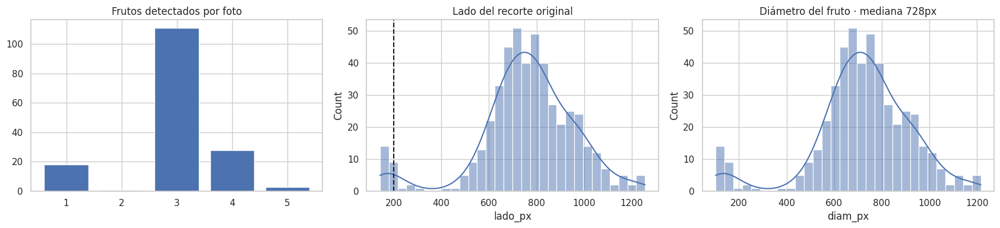

In [22]:
if HAS_DS:
    fig, ax = plt.subplots(1, 3, figsize=(17,4))

    vc = df_f[df_f.ok].detecciones.value_counts().sort_index()
    ax[0].bar(vc.index.astype(str), vc.values)
    ax[0].set_title("Frutos detectados por foto")

    sns.histplot(df_c.lado_px, bins=30, kde=True, ax=ax[1])
    ax[1].axvline(200, ls="--", c="k")
    ax[1].set_title("Lado del recorte original")

    sns.histplot(df_c.diam_px, bins=30, kde=True, ax=ax[2])
    ax[2].set_title(f"Diámetro del fruto · mediana {DS_DIAM_PX:.0f}px")

    plt.tight_layout()
    plt.show()

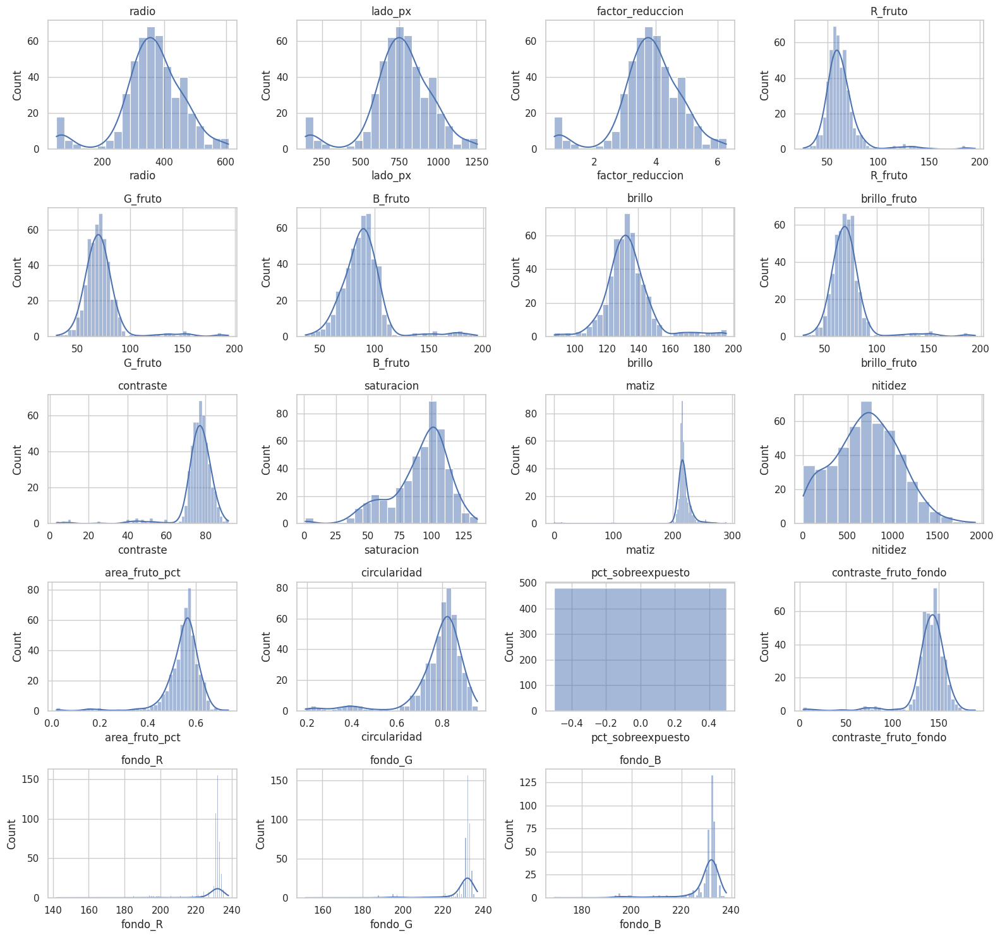

In [23]:
def grid(tipo,cols,df,ncols=4):
    nrows=math.ceil(len(cols)/ncols)
    fig,axs=plt.subplots(nrows,ncols,figsize=(4*ncols,3*nrows))
    axs=np.array(axs).ravel()

    for ax,c in zip(axs,cols):
        if tipo=="box":
            sns.boxplot(y=df[c],ax=ax)
        elif tipo=="hist":
            sns.histplot(df[c],kde=True,ax=ax)
        ax.set_title(c)

    for ax in axs[len(cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if HAS_DS:
    grid("hist",FEATS,df_c)

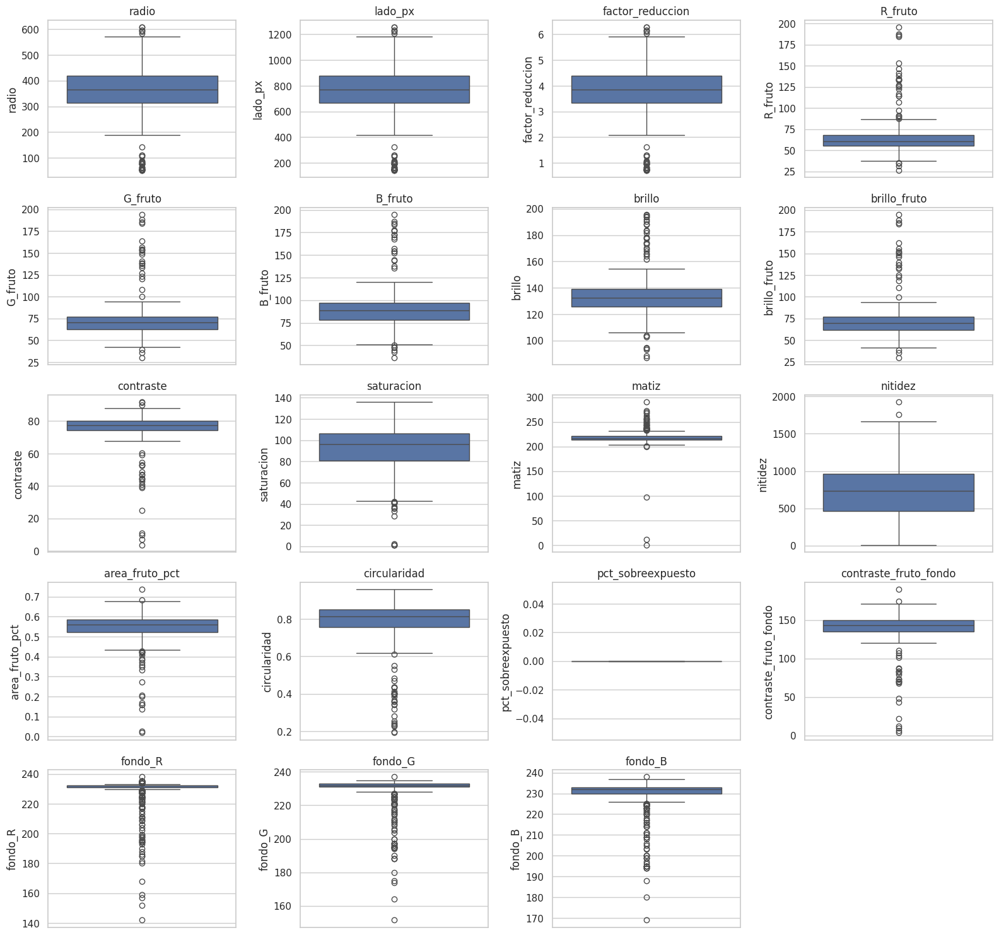

In [24]:
if HAS_DS:
    grid("box",FEATS,df_c)

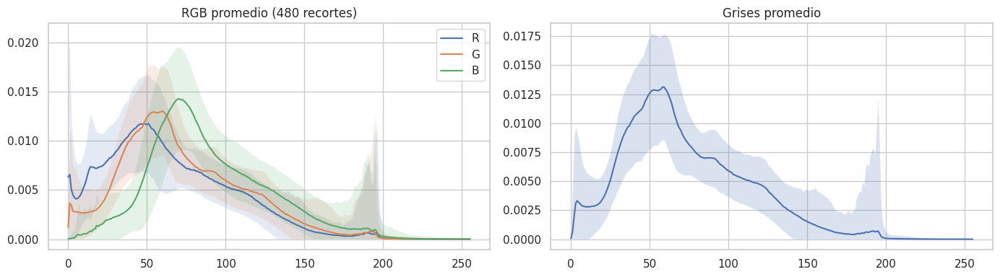

Pico de grises: 59


In [25]:
if HAS_DS:
    HR = np.stack([h for h in HRGB if h is not None])
    HG = np.stack([h for h in HGRAY if h is not None])
    x = np.arange(256)

    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    for k, nm in enumerate(["R","G","B"]):
        mu, sd = HR[:,k].mean(0), HR[:,k].std(0)
        ax[0].plot(x, mu, label=nm)
        ax[0].fill_between(x, np.maximum(mu-sd,0), mu+sd, alpha=.15)

    ax[0].set_title(f"RGB promedio ({len(HR)} recortes)")
    ax[0].legend()

    mu, sd = HG.mean(0), HG.std(0)
    ax[1].plot(x, mu)
    ax[1].fill_between(x, np.maximum(mu-sd,0), mu+sd, alpha=.2)
    ax[1].set_title("Grises promedio")

    plt.tight_layout()
    plt.show()

    print(f"Pico de grises: {int(HG.mean(0).argmax())}")

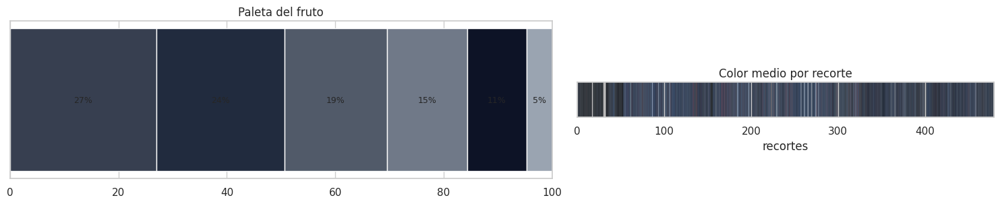

,color,porcentaje,L,a,b
0,#373f50,27.0,68.0,1.0,-10.0
1,#212b3e,23.6,44.0,2.0,-14.0
2,#515a69,19.0,97.0,1.0,-9.0
3,#707988,14.7,130.0,0.0,-8.0
4,#0d1326,11.0,16.0,5.0,-14.0
5,#9aa4b1,4.7,172.0,-0.0,-7.0


Fondo: R=232 G=232 B=232 | brillo p5-p95: [204. 234.]


In [26]:
if HAS_DS:
    K = 6
    cv2.setRNGSeed(SEED)

    P = np.vstack([p for p in pool if p is not None]).astype(np.uint8)
    lab = cv2.cvtColor(P.reshape(-1,1,3), cv2.COLOR_RGB2LAB).reshape(-1,3).astype(np.float32)

    _, lbl, cen = cv2.kmeans(lab, K, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 60, .5), 3, cv2.KMEANS_PP_CENTERS)
    cen_rgb = cv2.cvtColor(cen.reshape(-1,1,3).astype(np.uint8), cv2.COLOR_LAB2RGB).reshape(-1,3)

    share = np.bincount(lbl.ravel(), minlength=K) / len(lbl)
    order = np.argsort(-share)

    PALETA = pd.DataFrame({
        "color":[f"#{r:02x}{g:02x}{b:02x}" for r,g,b in cen_rgb[order]],
        "porcentaje":(share[order]*100).round(1),
        "L":cen[order,0].round(0),
        "a":(cen[order,1]-128).round(0),
        "b":(cen[order,2]-128).round(0)
    })

    fig, ax = plt.subplots(1, 2, figsize=(15,3.2), gridspec_kw={"width_ratios":[1.3,1]})

    left = 0
    for c, s in zip(PALETA.color, PALETA.porcentaje):
        ax[0].barh(0, s, left=left, color=c, edgecolor="white")
        ax[0].text(left+s/2, 0, f"{s:.0f}%", ha="center", va="center", fontsize=9)
        left += s
    ax[0].set_xlim(0,100); ax[0].set_yticks([]); ax[0].set_title("Paleta del fruto")

    tira = df_c.sort_values(["foto_n","crop_id"])[["R_fruto","G_fruto","B_fruto"]].values.astype(np.uint8)[None]
    ax[1].imshow(np.repeat(tira, 40, axis=0))
    ax[1].set_yticks([]); ax[1].set_xlabel("recortes"); ax[1].set_title("Color medio por recorte")

    plt.tight_layout()
    plt.show()
    display(PALETA)

    fb = (df_c.fondo_R + df_c.fondo_G + df_c.fondo_B) / 3
    print(f"Fondo: R={df_c.fondo_R.median():.0f} G={df_c.fondo_G.median():.0f} B={df_c.fondo_B.median():.0f} | brillo p5-p95: {np.percentile(fb,[5,95]).round(0)}")

Cada subsistema se dimensiona con un criterio explícito. Los gráficos muestran la sensibilidad de la decisión a su parámetro principal.

### 4.6 Análisis bi/multivariante


Sin etiquetas se estudian (a) las relaciones entre variables independientes (redundancia → reducción de dimensionalidad), (b) la estructura global con PCA y agrupamiento y (c) la deriva de captura. Con etiquetas (§4.7) se añade la relación característica ↔ clase.

Análisis sobre 453/480 recortes.


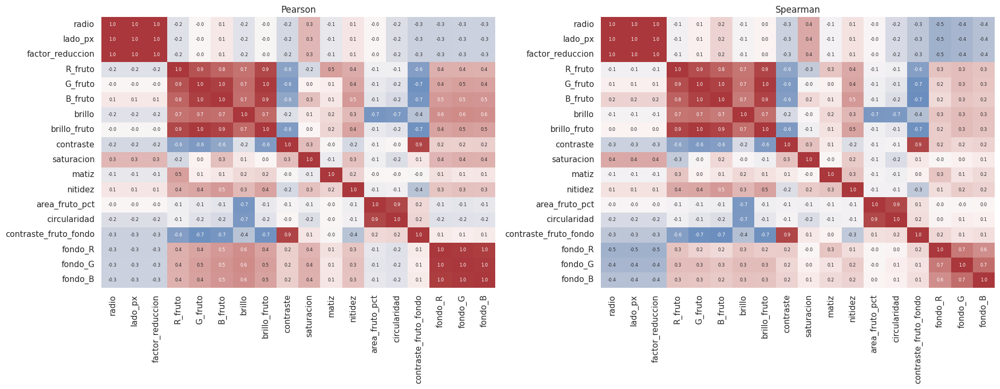

,level_0,level_1,|rho|
0,radio,lado_px,1.000000
1,radio,factor_reduccion,1.000000
17,lado_px,factor_reduccion,1.000000
64,G_fruto,brillo_fruto,0.987505
62,G_fruto,B_fruto,0.952741
76,B_fruto,brillo_fruto,0.938097
51,R_fruto,brillo_fruto,0.935464
113,contraste,contraste_fruto_fondo,0.927720
138,area_fruto_pct,circularidad,0.917953


Retenidas: 12/18
['nitidez', 'saturacion', 'radio', 'R_fruto', 'B_fruto', 'area_fruto_pct', 'brillo', 'contraste_fruto_fondo', 'matiz', 'fondo_B', 'fondo_G', 'fondo_R']


In [27]:
if HAS_DS:
    fx = [f for f in FEATS if df_c[f].nunique() > 1]
    dfa = df_c[df_c.radio >= .5*df_c.radio.median()].copy()

    print(f"Análisis sobre {len(dfa)}/{len(df_c)} recortes.")

    fig, ax = plt.subplots(1,2,figsize=(19,7.5))
    for a, m in zip(ax, ["pearson","spearman"]):
        sns.heatmap(dfa[fx].corr(method=m), cmap="vlag", center=0, vmin=-1, vmax=1,
                    annot=True, fmt=".1f", annot_kws={"size":6}, ax=a, cbar=False)
        a.set_title(m.capitalize())
    plt.tight_layout()
    plt.show()

    cm = dfa[fx].corr(method="spearman").abs()
    pares = cm.where(np.triu(np.ones(cm.shape),1).astype(bool)).stack().rename("|rho|").reset_index()
    pares = pares[pares["|rho|"] > .9].sort_values("|rho|", ascending=False)
    display(pares if len(pares) else "Sin pares > 0.9")

    cv = (dfa[fx].std()/dfa[fx].mean().abs()).abs()
    ret = []
    for f in cv.sort_values(ascending=False).index:
        if all(cm.loc[f,r] < .9 for r in ret): ret.append(f)

    print(f"Retenidas: {len(ret)}/{len(fx)}")
    print(ret)

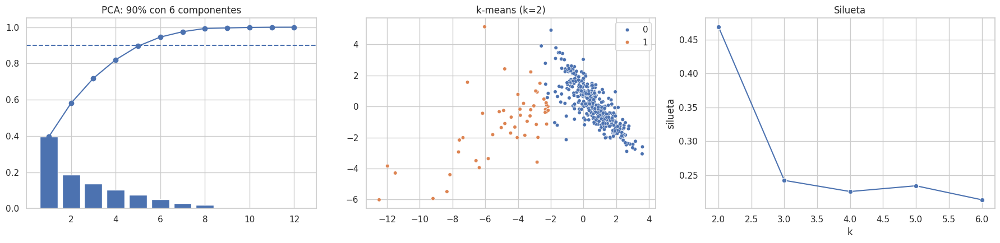

Mejor k: 2 | silueta=0.47


,radio,brillo_fruto,R_fruto,B_fruto,saturacion,nitidez,circularidad
grupo_kmeans,,,,,,,
0.0,373.4,70.2,62.3,88.6,97.0,790.9,0.8
1.0,412.5,54.6,50.2,63.4,65.2,374.9,0.9


In [28]:
if HAS_DS:
    X = dfa[ret].dropna()
    Z = ((X-X.mean())/X.std(ddof=0)).values

    U,S,Vt = np.linalg.svd(Z, full_matrices=False)
    expl = S**2/(S**2).sum()
    cum = np.cumsum(expl)
    k90 = np.searchsorted(cum,.9)+1
    sc = U[:,:min(5,Z.shape[1])] * S[:min(5,Z.shape[1])]

    def sil(Xs, lb):
        D = np.sqrt(((Xs[:,None]-Xs[None,:])**2).sum(-1))
        return np.mean([
            (min(D[i,lb==k].mean() for k in set(lb) if k!=lb[i]) -
             D[i,lb==lb[i]].sum()/max((lb==lb[i]).sum()-1,1)) /
            max(min(D[i,lb==k].mean() for k in set(lb) if k!=lb[i]),
                D[i,lb==lb[i]].sum()/max((lb==lb[i]).sum()-1,1))
            for i in range(len(Xs))
        ])

    res = []
    for k in range(2,7):
        cv2.setRNGSeed(SEED)
        _,lb,_ = cv2.kmeans(sc.astype(np.float32), k, None, (3,100,.1), 5, cv2.KMEANS_PP_CENTERS)
        res.append((k,sil(sc,lb.ravel())))

    sil_df = pd.DataFrame(res, columns=["k","silueta"])
    kbest = int(sil_df.loc[sil_df.silueta.idxmax(),"k"])

    cv2.setRNGSeed(SEED)
    _,lb,_ = cv2.kmeans(sc.astype(np.float32), kbest, None, (3,100,.1), 5, cv2.KMEANS_PP_CENTERS)
    df_c.loc[X.index,"grupo_kmeans"] = lb.ravel()

    fig,ax = plt.subplots(1,3,figsize=(18,4.5))
    ax[0].bar(range(1,len(expl)+1),expl); ax[0].plot(range(1,len(expl)+1),cum,"o-"); ax[0].axhline(.9,ls="--")
    ax[0].set_title(f"PCA: 90% con {k90} componentes")
    sns.scatterplot(x=sc[:,0],y=sc[:,1],hue=lb.ravel(),s=22,ax=ax[1]); ax[1].set_title(f"k-means (k={kbest})")
    sns.lineplot(data=sil_df,x="k",y="silueta",marker="o",ax=ax[2]); ax[2].set_title("Silueta")
    plt.tight_layout(); plt.show()

    print(f"Mejor k: {kbest} | silueta={sil_df.silueta.max():.2f}")

    display(df_c.groupby("grupo_kmeans")[["radio","brillo_fruto","R_fruto","B_fruto","saturacion","nitidez","circularidad"]].mean().round(1))

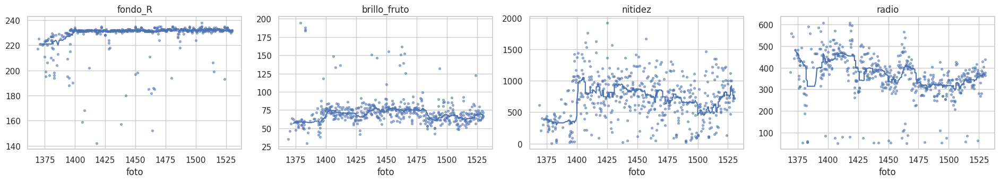

,rho,p,eta2_por_foto
caracteristica,,,
fondo_R,0.458,0.000,0.339
brillo_fruto,-0.010,0.820,0.610
nitidez,0.042,0.362,0.525
radio,-0.418,0.000,0.483
R_fruto,-0.004,0.927,0.601
saturacion,0.066,0.148,0.698


eta² alto = mayor efecto de la foto de origen → dividir entrenamiento/validación por foto.


In [29]:
if HAS_DS:
    tend = ["fondo_R","brillo_fruto","nitidez","radio"]

    fig, ax = plt.subplots(1,4,figsize=(19,3.6))
    for a,f in zip(ax,tend):
        d = df_c.sort_values("foto_n")
        a.scatter(d.foto_n,d[f],s=8,alpha=.5)
        a.plot(d.foto_n,d[f].rolling(25,min_periods=5).median())
        a.set_title(f); a.set_xlabel("foto")
    plt.tight_layout(); plt.show()

    rows = []
    for f in ["fondo_R","brillo_fruto","nitidez","radio","R_fruto","saturacion"]:
        rho,p = stats.spearmanr(df_c.foto_n,df_c[f])
        g = df_c.groupby("foto")[f]
        ssb = (g.count()*(g.mean()-df_c[f].mean())**2).sum()
        sst = ((df_c[f]-df_c[f].mean())**2).sum()
        rows.append([f,rho,p,ssb/sst])

    TEND = pd.DataFrame(rows,columns=["caracteristica","rho","p","eta2_por_foto"]).set_index("caracteristica")
    display(TEND.round(3))

    print("eta² alto = mayor efecto de la foto de origen → dividir entrenamiento/validación por foto.")

    fx_q = [f for f in ["nitidez","brillo_fruto"] if f in df_c]

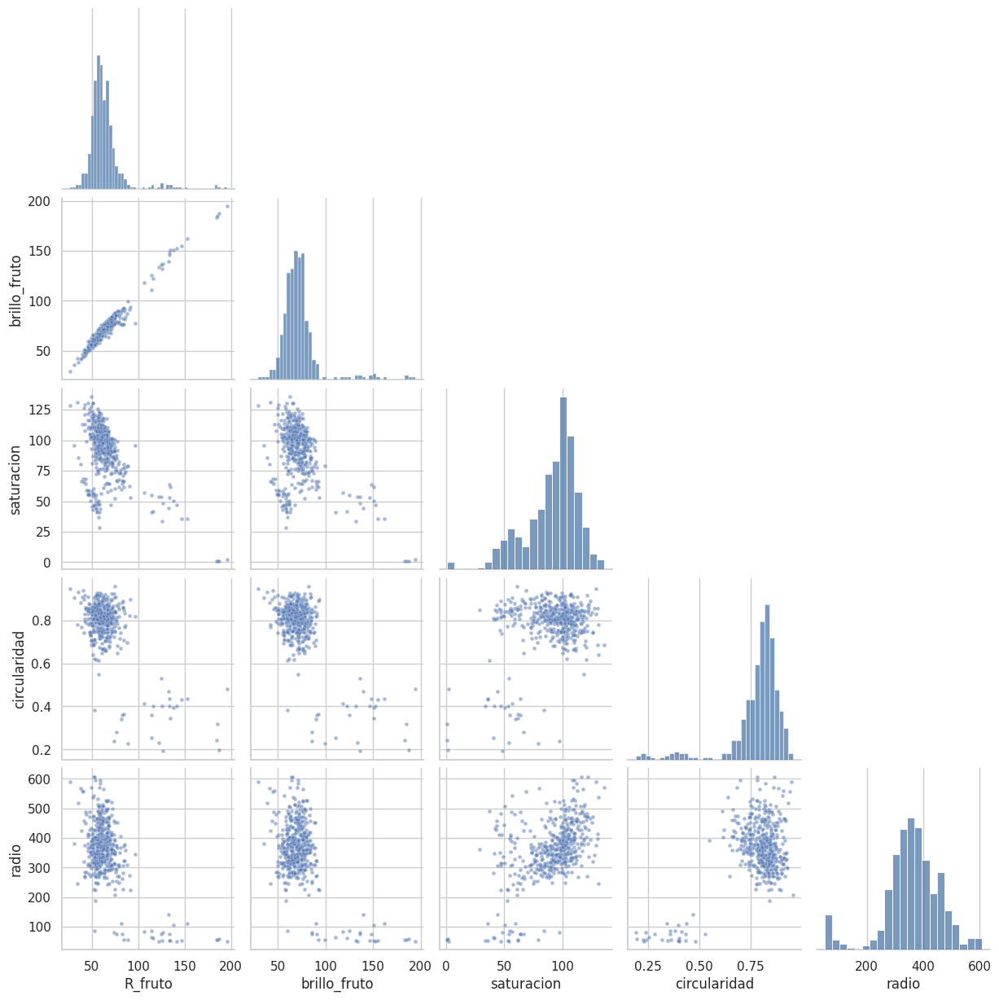

In [30]:
if HAS_DS:
    top = ["R_fruto", "brillo_fruto", "saturacion", "circularidad", "radio"]
    sns.pairplot(df_c[top], corner=True, plot_kws={"s": 12, "alpha": .5}, diag_kws={"color": "#4c78a8"}); plt.show()

### 4.7 Preprocesamiento

Cada decisión se justifica. Las transformaciones sobre las características tabulares sirven al análisis y al control de calidad; los modelos CNN consumirán los píxeles redimensionados y normalizados (Avances 3 y 4).

In [31]:
if HAS_DS:
    dup = df_c.duplicated("md5")
    print("Duplicados exactos:", dup.sum())

    H = [int(h,16) for h in df_c.dhash]
    pares = [(df_c.crop_id.iat[i],df_c.crop_id.iat[j],bin(H[i]^H[j]).count("1"))
             for i in range(len(H)) for j in range(i+1,len(H))
             if df_c.foto.iat[i]!=df_c.foto.iat[j] and bin(H[i]^H[j]).count("1")<=6]

    near = pd.DataFrame(pares,columns=["recorte_a","recorte_b","hamming"])
    print("Casi-duplicados:",len(near))
    display(near.head(10) if len(near) else "Ninguno")

    med = df_c.radio.median()
    ln = np.log1p(df_c.nitidez)
    q1,q3 = ln.quantile([.25,.75])
    lo = q1-3*(q3-q1)

    qc = pd.DataFrame({
        "muy_pequeño":df_c.radio<.5*med,
        "borrosa":ln<lo,
        "sobreexpuesto":df_c.pct_sobreexpuesto>.05,
        "no_cuadrado":~df_c.cuadrado,
        "sin_fruto":df_c.area_fruto_pct.isna()|(df_c.area_fruto_pct<.05),
        "duplicado":dup
    })

    display(qc.sum().to_frame("n").T)

    df_c["qc_falla"] = qc.any(axis=1)
    df_c["qc_motivo"] = qc.apply(lambda r: ",".join(r.index[r]),axis=1)

    tab = []
    for f in ["R_fruto","G_fruto","B_fruto","saturacion","circularidad","radio"]:
        s = df_c[f].dropna()
        a,b = s.quantile([.25,.75]); I = b-a
        tab.append([f,((s<a-1.5*I)|(s>b+1.5*I)).sum(),((s<a-3*I)|(s>b+3*I)).sum()])

    display(pd.DataFrame(tab,columns=["caracteristica","1.5IQR","3IQR"]).set_index("caracteristica").T)

    print(f"Excluidos por calidad: {df_c.qc_falla.sum()}/{len(df_c)}")
    df_q = df_c[~df_c.qc_falla].copy().reset_index(drop=True)

Duplicados exactos: 0
Casi-duplicados: 0


'Ninguno'

,muy_pequeño,borrosa,sobreexpuesto,no_cuadrado,sin_fruto,duplicado
n,27,13,0,0,2,0


caracteristica,R_fruto,G_fruto,B_fruto,saturacion,circularidad,radio
1.5IQR,29,24,25,14,29,33
3IQR,19,19,14,4,25,0


Excluidos por calidad: 33/480


In [32]:
if HAS_DS:
    sesg = df_q[fx].skew()
    res = []

    for f in sesg[sesg.abs()>1].index:
        s = df_q[f].dropna()
        if s.nunique()>2:
            y,lam = stats.yeojohnson(s)
            df_q.loc[s.index,f+"_yj"] = y
            res.append([f,s.skew(),pd.Series(y).skew(),lam])

    display(pd.DataFrame(
        res,
        columns=["caracteristica","antes","despues","lambda"]
    ).round(3) if res else "Sin transformación")

    print(
        f"Reducción a 200×200: mediana "
        f"{df_q.factor_reduccion.median():.1f}× | "
        f"rango {df_q.factor_reduccion.min():.1f}–"
        f"{df_q.factor_reduccion.max():.1f}×"
    )

    FRUTO_DIAM_MM = 14.0
    DEFECTO_MIN_MM = 1.0

    niv = pd.DataFrame({"escala":[1,.5,.25,.14,.10]})
    niv["diam_px"] = DS_DIAM_PX*niv.escala
    niv["mm_px"] = FRUTO_DIAM_MM/niv.diam_px
    niv[f"px_defecto_{DEFECTO_MIN_MM}mm"] = DEFECTO_MIN_MM/niv.mm_px

    display(niv.round(3))

,caracteristica,antes,despues,lambda
0,matiz,2.716,0.000,-5.762
1,fondo_R,-4.376,-0.450,39.780
2,fondo_G,-4.237,-0.869,39.800
3,fondo_B,-4.009,-0.175,38.729


Reducción a 200×200: mediana 3.9× | rango 2.1–6.3×


,escala,diam_px,mm_px,px_defecto_1.0mm
0,1.00,728.00,0.019,52.00
1,0.50,364.00,0.038,26.00
2,0.25,182.00,0.077,13.00
3,0.14,101.92,0.137,7.28
4,0.10,72.80,0.192,5.20


In [33]:
if HAS_DS:
    rng = np.random.default_rng(SEED)
    fotos = df_q.foto.unique().copy()
    rng.shuffle(fotos)

    cnt, tot, asign, acum = df_q.foto.value_counts(), len(df_q), {}, 0

    for f in fotos:
        asign[f] = "train" if acum < .70*tot else ("val" if acum < .85*tot else "test")
        acum += cnt[f]

    df_q["particion"] = df_q.foto.map(asign)

    display(
        df_q.groupby("particion").agg(
            recortes=("crop_id","size"),
            fotos=("foto","nunique")
        ).assign(
            porcentaje=lambda d:(d.recortes/tot*100).round(1)
        )
    )

    assert df_q.groupby("foto").particion.nunique().max() == 1

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    plantilla = df_c[
        ["crop_id","foto","cx","cy","radio"]
    ].assign(
        clase="",
        defecto="",
        notas=""
    )

    plantilla.to_csv(
        OUT_DIR/"etiquetas_plantilla.csv",
        index=False
    )

    df_q[
        ["crop_id","foto","foto_n","particion",
         "radio","lado_px","md5"] + fx
    ].to_csv(
        OUT_DIR/"manifiesto_recortes.csv",
        index=False
    )

    df_c[df_c.qc_falla][
        ["crop_id","foto","qc_motivo"]
    ].to_csv(
        OUT_DIR/"revisar_manual_qc.csv",
        index=False
    )

    print(f"Archivos guardados en {OUT_DIR}")

    lab_path = next(
        (
            p for p in [
                DS_DIR/"etiquetas.csv",
                OUT_DIR/"etiquetas.csv"
            ]
            if p.exists()
        ),
        None
    )

    HAS_LAB = False

    if lab_path:

        try:
            et = pd.read_csv(lab_path, encoding="utf-8")
        except UnicodeDecodeError:
            et = pd.read_csv(lab_path, encoding="cp1252")

        et["clase"] = (
            et.clase.astype(str)
            .str.strip()
            .str.lower()
            .replace({
                "buena":"bueno",
                "mala":"malo",
                "nan":np.nan,
                "":np.nan
            })
        )

        cols = ["crop_id","clase"] + (
            ["defecto"] if "defecto" in et else []
        )

        df_q = (
            df_q
            .drop(
                columns=[
                    c for c in ["clase","defecto"]
                    if c in df_q
                ]
            )
            .merge(
                et[cols],
                on="crop_id",
                how="left"
            )
        )

        HAS_LAB = df_q.clase.notna().any()

        print(
            f"Etiquetados: "
            f"{df_q.clase.notna().sum()}"
        )

    else:
        print("Sin etiquetas.csv")

else:
    HAS_LAB = False

,recortes,fotos,porcentaje
particion,,,
test,65,24,14.5
train,314,110,70.2
val,68,24,15.2


Archivos guardados en /content/drive/MyDrive/ProyectoIntegrador/Datos/resultados_avance1
Etiquetados: 410


,n,pct
clase,,
bueno,239,58.3
malo,171,41.7


Desbalance: 1.4 :1


,caracteristica,AUC,p,relevancia
11,nitidez,0.6429,0.0000,0.2857
3,R_fruto,0.5543,0.0606,0.1087
15,fondo_R,0.5403,0.1496,0.0806
13,circularidad,0.5377,0.1933,0.0753
16,fondo_G,0.5360,0.1982,0.0720
9,saturacion,0.4737,0.3640,0.0526
10,matiz,0.5260,0.3689,0.0520
8,contraste,0.4741,0.3707,0.0518
12,area_fruto_pct,0.5220,0.4478,0.0440
0,radio,0.5170,0.5572,0.0340


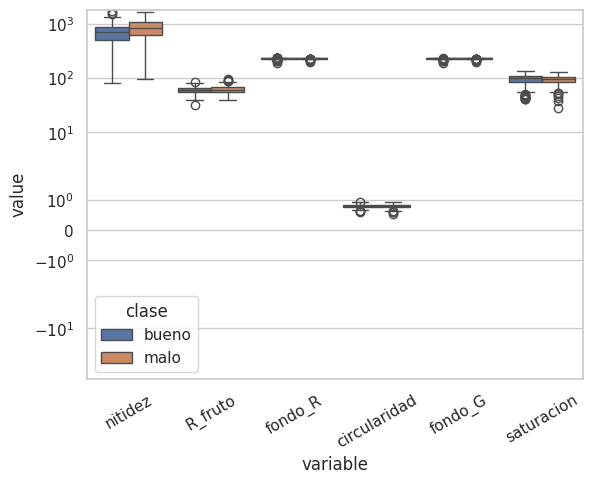

In [34]:
if HAS_DS and HAS_LAB:
    dl = df_q.dropna(subset=["clase"])
    cnt = dl.clase.value_counts()

    display(cnt.to_frame("n").assign(pct=(cnt/cnt.sum()*100).round(1)))
    print("Desbalance:", round(cnt.max()/cnt.min(),2), ":1")

    if len(cnt)==2:
        pos = "malo" if "malo" in cnt.index else cnt.index[-1]
        A, B = dl[dl.clase==pos], dl[dl.clase!=pos]
        res = []

        for f in fx:
            a,b = A[f].dropna(),B[f].dropna()
            u = stats.mannwhitneyu(a,b)
            res.append([f,u.statistic/(len(a)*len(b)),u.pvalue])

        REL = pd.DataFrame(res,columns=["caracteristica","AUC","p"])
        REL["relevancia"] = (2*REL.AUC-1).abs()
        REL = REL.sort_values("relevancia",ascending=False)

        display(REL.head(10).round(4))

        sns.boxplot(data=dl.melt(id_vars="clase",value_vars=REL.caracteristica.head(6)),x="variable",y="value",hue="clase")
        plt.xticks(rotation=30)
        plt.yscale("symlog")
        plt.show()
else:
    print("Sección supervisada pendiente.")

#### Cardinalidad y verificación de sesgo entre clase y sesión de captura

La rúbrica pide revisar la cardinalidad de las variables categóricas, y la nitidez resultó la característica más ligada a la clase mientras que la foto de origen explica gran parte de su varianza (§4.6). Esta celda (1) reporta la cardinalidad y (2) comprueba si la clase está repartida de forma desigual entre periodos de captura y si la relación nitidez↔clase se mantiene dentro de cada periodo. Se ejecuta cuando existen etiquetas.

,valores distintos
clase,2
foto de origen,144
defecto,8


,n,pct
defecto,,
ninguno,239,58.3
cicatriz,59,14.4
flor_seca,34,8.3
deshidratado,29,7.1
coloracion_anormal,22,5.4
golpe,21,5.1
descompuesto,5,1.2
inmaduro,1,0.2


Categorías de defecto con < 10 recortes (se agruparían en 'otros'): ['descompuesto', 'inmaduro']


clase,bueno,malo,pct_malo
periodo,,,
inicio,70,68,49.3
medio,82,55,40.1
final,87,48,35.6


Chi-cuadrada clase × periodo de captura: p = 0.06426 → no hay evidencia de que la clase dependa del periodo


,AUC nitidez,AUC brillo_fruto
periodo,,
global,0.643,0.510
inicio,0.584,0.478
medio,0.707,0.595
final,0.624,0.451


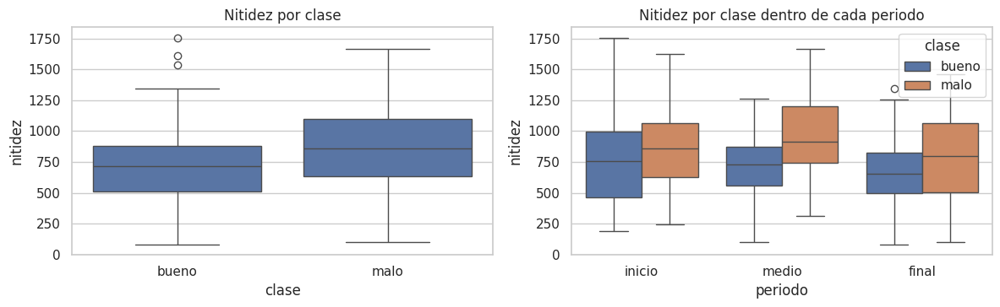

Lectura: si el AUC de la nitidez baja hacia 0.5 dentro de cada periodo, el efecto global se debía a la sesión de captura y no al fruto; si se mantiene, la nitidez sí discrimina (por ejemplo, frutos defectuosos con textura distinta).


In [35]:
if HAS_DS and HAS_LAB:
    dl = df_q.dropna(subset=["clase"]).copy()
    cnt = dl.clase.value_counts()

    # --- Cardinalidad de las variables categóricas ---
    card = {"clase": dl.clase.nunique(), "foto de origen": dl.foto.nunique()}
    if "defecto" in dl and dl.defecto.notna().any():
        card["defecto"] = dl.defecto.nunique()
    display(pd.Series(card, name="valores distintos").to_frame())
    if "defecto" in dl and dl.defecto.notna().any():
        vc = dl.defecto.value_counts()
        display(vc.to_frame("n").assign(pct=(vc/vc.sum()*100).round(1)))
        raras = vc[vc < 10].index.tolist()
        print("Categorías de defecto con < 10 recortes (se agruparían en 'otros'):", raras if raras else "ninguna")

    # --- ¿La clase está confundida con la sesión de captura? (la nitidez es la característica más ligada a la clase) ---
    dl["periodo"] = pd.qcut(dl.foto_n, 3, labels=["inicio", "medio", "final"])
    tab = pd.crosstab(dl.periodo, dl.clase)
    display(tab.assign(pct_malo=(tab.get("malo", 0)/tab.sum(axis=1)*100).round(1)))
    chi2, p_chi, _, _ = stats.chi2_contingency(tab)
    print(f"Chi-cuadrada clase × periodo de captura: p = {p_chi:.4g} → " +
          ("la clase NO es independiente del periodo de captura (posible confusión)" if p_chi < .05 else "no hay evidencia de que la clase dependa del periodo"))

    if len(cnt) == 2:
        pos = "malo" if "malo" in cnt.index else cnt.index[-1]
        def auc(d, f):
            a, b = d[d.clase == pos][f].dropna(), d[d.clase != pos][f].dropna()
            return stats.mannwhitneyu(a, b).statistic / (len(a)*len(b)) if len(a) and len(b) else np.nan
        filas = [{"periodo": "global", "AUC nitidez": auc(dl, "nitidez"), "AUC brillo_fruto": auc(dl, "brillo_fruto")}]
        for per, g in dl.groupby("periodo"):
            filas.append({"periodo": per, "AUC nitidez": auc(g, "nitidez"), "AUC brillo_fruto": auc(g, "brillo_fruto")})
        display(pd.DataFrame(filas).set_index("periodo").round(3))
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
        sns.boxplot(data=dl, x="clase", y="nitidez", ax=ax[0]); ax[0].set_title("Nitidez por clase")
        sns.boxplot(data=dl, x="periodo", y="nitidez", hue="clase", ax=ax[1]); ax[1].set_title("Nitidez por clase dentro de cada periodo")
        plt.tight_layout(); plt.show()
        print("Lectura: si el AUC de la nitidez baja hacia 0.5 dentro de cada periodo, el efecto global se debía a la sesión de captura y no al fruto; "
              "si se mantiene, la nitidez sí discrimina (por ejemplo, frutos defectuosos con textura distinta).")
else:
    print("Verificación pendiente: requiere las etiquetas (etiquetas.csv).")

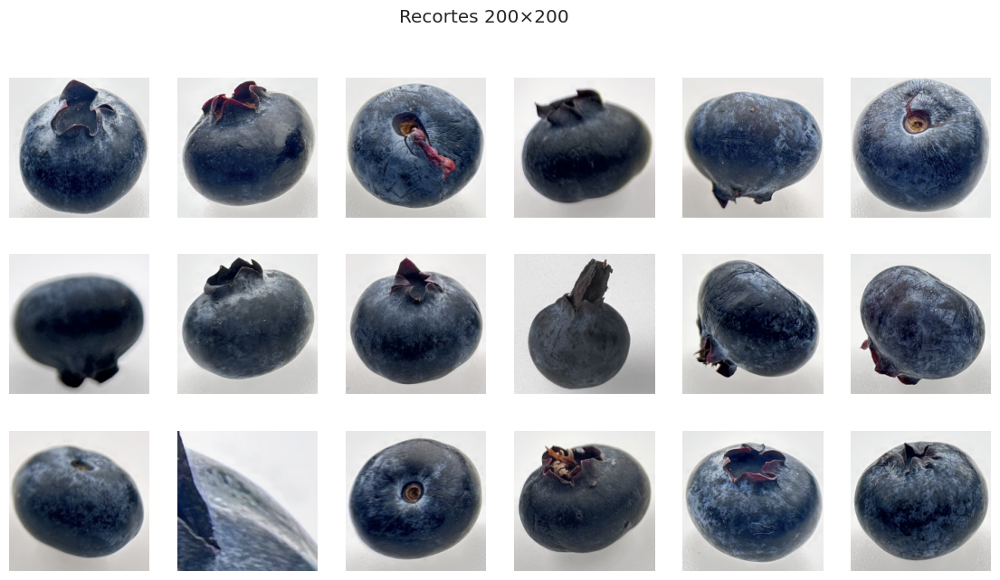

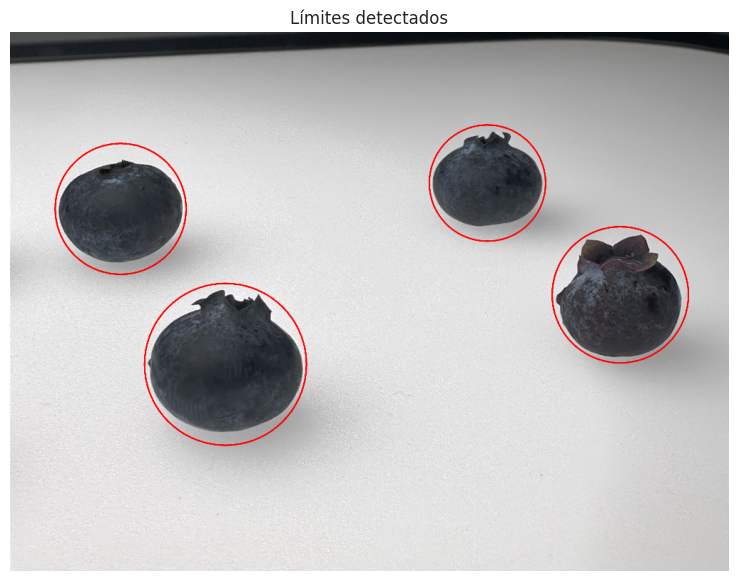

In [36]:
SHOW_IMAGES = os.environ.get("BERRY_SHOW_IMAGES","1")=="1"

if HAS_DS and SHOW_IMAGES:
    n = min(18,len(C200))
    k = np.random.default_rng(1).choice(len(C200),n,replace=False)

    fig,ax = plt.subplots(3,6,figsize=(14,7.2))
    for a in ax.ravel(): a.axis("off")
    for a,i in zip(ax.ravel(),k): a.imshow(C200[i][...,::-1])
    plt.suptitle("Recortes 200×200")
    plt.show()

    ids = df_f.index[df_f.detecciones>=3]
    if len(ids):
        p = orig_files[int(ids[0])]
        img = cv2.imdecode(np.fromfile(str(p),np.uint8),1)
        dets,_ = detectar(img)

        for d in dets:
            cv2.circle(img,(int(d["cx"]),int(d["cy"])),d["radio"]+CROP_PADDING,(0,0,255),8)

        plt.figure(figsize=(10,7))
        plt.imshow(cv2.resize(img,None,fx=.25,fy=.25)[...,::-1])
        plt.axis("off")
        plt.title("Límites detectados")
        plt.show()
else:
    print("Visualización omitida.")

**Decisiones de preprocesamiento y su justificación**

| Problema observado | Decisión | Justificación |
|---|---|---|
| Fotos sin recortes en `output/` y recortes huérfanos | Regenerar los recortes desde `image/` con el extractor integrado | `output/` es una corrida parcial; la regeneración es reproducible y trazable (id de recorte + coordenadas) |
| Recortes de tamaños muy distintos (cuadrados de lado variable) | Reducir con `INTER_AREA` a 200×200 | Entrada uniforme al modelo; solo se reduce, no se inventa información |
| Objetos muy pequeños (radio < 0.5 × mediana: fragmentos o reflejos del fruto, no frutos completos), borrosos o sobreexpuestos | Excluir y listar en `revisar_manual_qc.csv` | Son fallas de extracción/captura, no variación del producto; el filtro de radio del extractor (50 px) deja pasar fragmentos en fotos macro |
| Atípicos en color y forma | Conservar | Un arándano defectuoso es atípico en color/forma por definición |
| Variables sesgadas | Yeo-Johnson (solo análisis tabular) | Admite ceros y negativos y reduce la cola larga |
| Frutos de una misma foto comparten condiciones de captura | Partición 70/15/15 **por foto** | Evita fuga de datos entre entrenamiento y prueba |
| Dataset sin clasificar al llegar | El equipo lo etiquetó; lectura automática de `etiquetas.csv` (y plantilla `etiquetas_plantilla.csv` para lo pendiente) | Habilita el análisis supervisado y el balance de clases sin cambiar la libreta |
| Posible confusión entre la clase y la sesión de captura | Verificación por periodo de captura (celda posterior a la sección supervisada) y partición por foto | La nitidez es la característica más ligada a la clase y depende en buena parte de la foto de origen; hay que separar el efecto del fruto del de la sesión |
| Dataset con ~7× más píxeles por fruto que la cámara de diseño | Estudio de degradación de resolución en el Avance 4 | Fija la resolución mínima real y reemplaza el supuesto de 100 px por fruto |

### 4.8 Vista de banda (foto de la máquina en operación)

Además del dataset macro, existe una **foto de la banda** con muchos frutos a la vez, que representa la óptica de la máquina. Aquí se aplica la cadena de visión para **bandas con muchos frutos** (normalización de fondo, Otsu, *watershed*), se mide la cobertura, la uniformidad de iluminación y la fracción de frutos pegados, y se estudia la escala de trabajo que fija el tiempo de preprocesamiento (§4.3 y §5.3).

**Cadena (por cada imagen):** normalización del fondo (cierre morfológico + desenfoque, se divide) → Otsu → limpieza morfológica → transformada de distancia + *watershed* para frutos pegados → control de calidad por objeto (`borde`, `pequeño`, `fusionado`, `ok`) → recorte 200×200 de los `ok`.

Imagen: muestra_01.jpg


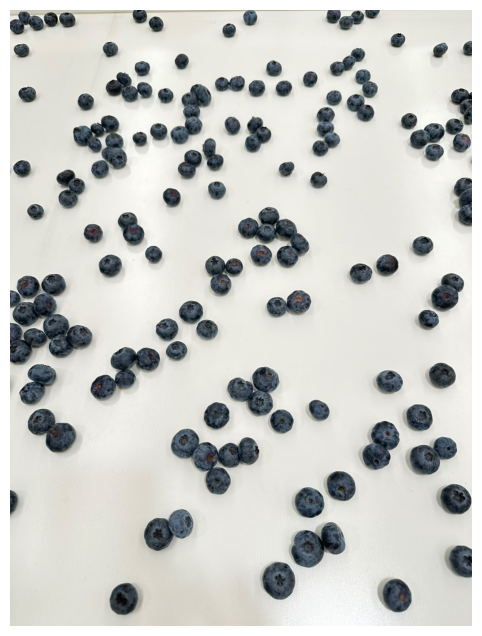

In [37]:
def segment_frame(img, min_peak_frac=.6, ref=1):
    h,w = img.shape[:2]
    g = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    kb,ks,kc = int(81*ref)|1, max(3,int(5*ref)|1), max(3,int(7*ref)|1)

    bg = cv2.morphologyEx(g,cv2.MORPH_CLOSE,cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(kb,kb)))
    bg = cv2.GaussianBlur(bg,(0,0),25*ref)
    norm = np.clip(g.astype(float)/np.maximum(bg,1)*255,0,255).astype(np.uint8)

    _,m = cv2.threshold(cv2.GaussianBlur(norm,(5,5),0),0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m,cv2.MORPH_OPEN,np.ones((ks,ks),np.uint8))
    m = cv2.morphologyEx(m,cv2.MORPH_CLOSE,np.ones((kc,kc),np.uint8))

    n,lab,st,_ = cv2.connectedComponentsWithStats(m)
    radios = []
    for i in range(1,n):
        a = st[i,cv2.CC_STAT_AREA]
        if a < 300*ref**2: continue
        x,y,bw,bh = st[i,:4]
        c = cv2.findContours((lab[y:y+bh,x:x+bw]==i).astype(np.uint8),cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)[0][0]
        hull = cv2.contourArea(cv2.convexHull(c))
        if hull and a/hull > .93: radios.append(np.sqrt(a/np.pi))

    r = np.median(radios) if radios else 23*ref
    dist = cv2.distanceTransform(m,cv2.DIST_L2,5)
    pk = (dist==ndi.maximum_filter(dist,size=int(1.3*r)|1)) & (dist>min_peak_frac*r)
    mk,_ = ndi.label(cv2.dilate(pk.astype(np.uint8),np.ones((ks,ks),np.uint8)))
    bgid = mk.max()+1
    ws = cv2.watershed(img,np.where(m==0,bgid,mk).astype(np.int32))

    objs = []
    for i,s in enumerate(ndi.find_objects(np.where((ws>0)&(ws<bgid),ws,0)),1):
        if s is None: continue
        sub = (ws[s]==i).astype(np.uint8); a = sub.sum()
        if a < 150*ref**2: continue

        c = max(cv2.findContours(sub,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)[0],key=cv2.contourArea)
        hull = cv2.contourArea(cv2.convexHull(c))
        y0,x0 = s[0].start,s[1].start
        bh,bw = sub.shape
        cy,cx = ndi.center_of_mass(sub)

        objs.append(dict(area=a,diam_px=np.sqrt(4*a/np.pi),solidez=a/hull if hull else np.nan,
                         cx=x0+cx,cy=y0+cy,x0=x0,y0=y0,bw=bw,bh=bh,
                         borde=x0<=1 or y0<=1 or x0+bw>=w-1 or y0+bh>=h-1))

    o = pd.DataFrame(objs)
    if len(o):
        med = o.area.median()
        o["estado"] = np.select([o.borde,o.area<.3*med,(o.area>1.6*med)|(o.solidez<.88)],
                                ["borde","pequeño","fusionado"],"ok")
    return o,m,bg,r

def segment_scaled(img,s):
    small = img if s==1 else cv2.resize(img,None,fx=s,fy=s,interpolation=cv2.INTER_AREA)
    o,m,bg,r = segment_frame(small,ref=s)
    if len(o):
        o[["cx","cy","x0","y0","bw","bh","diam_px"]] /= s
        o["area"] /= s**2
    return o,m,bg,r

def recortar(img,o,d_ref,size=CROP_PX,k=2.2):
    half = int(k*d_ref/2)
    pad = cv2.copyMakeBorder(img,half,half,half,half,cv2.BORDER_REPLICATE)
    return [cv2.resize(pad[int(r.cy):int(r.cy)+2*half,int(r.cx):int(r.cx)+2*half],
                       (size,size),interpolation=cv2.INTER_AREA) for r in o.itertuples()]

IMG_PATH = Path("/content/drive/MyDrive/ProyectoIntegrador/Semana3/images/muestra_01.jpg")
HAS_IMG = IMG_PATH.exists()

print("Imagen:", IMG_PATH.name if HAS_IMG else "NO encontrada")

if HAS_IMG:
    img = cv2.imread(str(IMG_PATH))

    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [38]:
if HAS_IMG:
    img = cv2.imdecode(np.fromfile(str(IMG_PATH),np.uint8),cv2.IMREAD_COLOR)
    H_IMG,W_IMG = img.shape[:2]
    MP_IMG = H_IMG*W_IMG/1e6

    objetos,mascara,fondo,r_est = segment_scaled(img,1)
    D_MED_PX = float(objetos.loc[objetos.estado=="ok","diam_px"].median())

    print(f"{W_IMG}×{H_IMG}px | {MP_IMG:.2f}MP | objetos: {len(objetos)} | diámetro: {D_MED_PX:.1f}px")

    base_ok = max((objetos.estado=="ok").sum(),1)
    filas = []

    for sc in [1,.75,.5,.35,.25]:
        tt = []
        for _ in range(3):
            t0 = time.perf_counter()
            o_,_,_,_ = segment_scaled(img,sc)
            tt.append((time.perf_counter()-t0)*1000)

        ok = o_[o_.estado=="ok"]
        d = ok.diam_px.median()

        filas.append([sc,MP_IMG*sc**2,np.median(tt),len(ok),len(ok)/base_ok*100,d,d*sc])

    estudio = pd.DataFrame(filas,columns=["escala","MP","ms","ok","% referencia","diam original","diam trabajo"])

    cumple = estudio[(estudio["% referencia"]>=90) & ((estudio["diam original"]/D_MED_PX-1).abs()<=.05)]
    fila = cumple.sort_values("escala").iloc[0] if len(cumple) else estudio.iloc[0]

    ESCALA_TRABAJO = float(fila.escala)
    T_SEG_MS = float(fila.ms)
    D_TRABAJO_PX = float(fila["diam trabajo"])
    MP_TRABAJO_EJ = MP_IMG*ESCALA_TRABAJO**2

    display(estudio.round(2))
    print(f"Escala: {ESCALA_TRABAJO} | segmentación: {T_SEG_MS:.0f} ms")

    t0 = time.perf_counter()
    for _ in range(5):
        cv2.resize(img,None,fx=ESCALA_TRABAJO,fy=ESCALA_TRABAJO,interpolation=cv2.INTER_AREA)
    T_RESIZE_MS = (time.perf_counter()-t0)/5*1000

    okobj = objetos[objetos.estado=="ok"].head(20)
    t0 = time.perf_counter()
    recortar(img,okobj,D_MED_PX)
    T_CROP_MS = (time.perf_counter()-t0)/max(len(okobj),1)*1000

    print(f"Resize: {T_RESIZE_MS:.1f} ms | crop: {T_CROP_MS:.2f} ms/fruto")

else:
    D_MED_PX,MP_IMG,ESCALA_TRABAJO,T_SEG_MS,D_TRABAJO_PX,T_RESIZE_MS,T_CROP_MS,MP_TRABAJO_EJ = 46,1.92,.5,60,23,3,.3,.48
    objetos = None

1200×1600px | 1.92MP | objetos: 153 | diámetro: 41.0px


,escala,MP,ms,ok,% referencia,diam original,diam trabajo
0,1.00,1.92,525.78,91,100.00,40.98,40.98
1,0.75,1.08,210.44,81,89.01,40.29,30.21
2,0.50,0.48,70.11,88,96.70,39.70,19.85
3,0.35,0.24,57.23,88,96.70,39.09,13.68
4,0.25,0.12,31.69,86,94.51,37.90,9.47


Escala: 0.35 | segmentación: 57 ms
Resize: 8.1 ms | crop: 0.15 ms/fruto


In [39]:
if HAS_IMG:
    resumen = objetos.estado.value_counts().to_frame("n")
    resumen["%"] = (resumen.n/len(objetos)*100).round(1)
    display(resumen)

    cobertura = (mascara>0).mean()
    p5,p95 = np.percentile(fondo,[5,95])
    uniformidad = p5/p95
    mm_px = FRUTO_DIAM_MM/D_MED_PX

    fus_pct = (objetos.estado=="fusionado").mean()*100
    borde_pct = (objetos.estado=="borde").mean()*100
    ok_pct = (objetos.estado=="ok").mean()*100

    print(f"Cobertura: {cobertura*100:.1f}% | Uniformidad: {uniformidad*100:.1f}%")
    print(f"FOV ≈ {W_IMG*mm_px:.0f}×{H_IMG*mm_px:.0f} mm | ok: {ok_pct:.1f}% | fusionados: {fus_pct:.1f}% | borde: {borde_pct:.1f}%")

else:
    cobertura = uniformidad = fus_pct = borde_pct = ok_pct = np.nan

,n,%
estado,,
ok,91,59.5
fusionado,43,28.1
borde,15,9.8
pequeño,4,2.6


Cobertura: 19.0% | Uniformidad: 86.7%
FOV ≈ 410×547 mm | ok: 59.5% | fusionados: 28.1% | borde: 9.8%


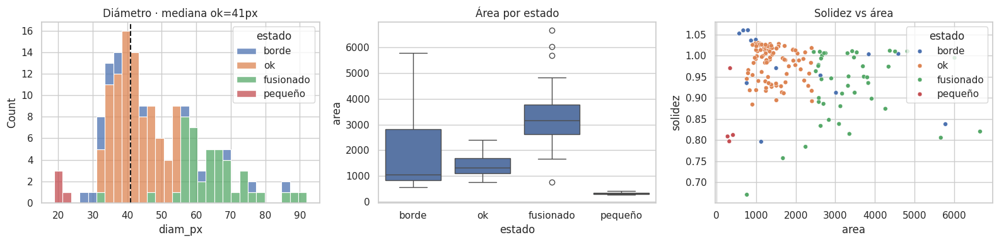

estado           borde  fusionado       ok  pequeño
area    count    15.00      43.00    91.00     4.00
        mean   1948.33    3333.37  1436.68   339.50
        std    1642.55    1088.56   432.94    56.78
        min     574.00     766.00   765.00   279.00
        25%     832.00    2635.00  1107.50   311.25
        50%    1062.00    3172.00  1319.00   332.00
        75%    2821.50    3763.00  1706.00   360.25
        max    5782.00    6657.00  2411.00   415.00
diam_px count    15.00      43.00    91.00     4.00
        mean     46.29      64.30    42.31    20.74
        std      19.04      10.59     6.27     1.72
        min      27.03      31.23    31.21    18.85
        25%      32.54      57.92    37.55    19.90
        50%      36.77      63.55    40.98    20.56
        75%      59.90      69.22    46.61    21.40
        max      85.80      92.06    55.41    22.99
solidez count    15.00      43.00    91.00     4.00
        mean      0.98       0.93     0.98     0.85
        std       0.08       0.08     0.04     0.08
        min       0.80       0.67     0.88     0.80
        25%       0.94       0.88     0.95     0.81
        50%       1.00       0.95     0.99     0.81
        75%       1.04       1.00     1.02     0.85
        max       1.06       1.01     1.03     0.97

In [40]:
if HAS_IMG:
    fig,ax = plt.subplots(1,3,figsize=(16,4))

    sns.histplot(data=objetos,x="diam_px",hue="estado",multiple="stack",bins=30,ax=ax[0])
    ax[0].axvline(D_MED_PX,ls="--",c="k")
    ax[0].set_title(f"Diámetro · mediana ok={D_MED_PX:.0f}px")

    sns.boxplot(data=objetos,x="estado",y="area",ax=ax[1])
    ax[1].set_title("Área por estado")

    sns.scatterplot(data=objetos,x="area",y="solidez",hue="estado",s=25,ax=ax[2])
    ax[2].set_title("Solidez vs área")

    plt.tight_layout()
    plt.show()

    display(objetos.groupby("estado")[["area","diam_px","solidez"]].describe().round(2).T)

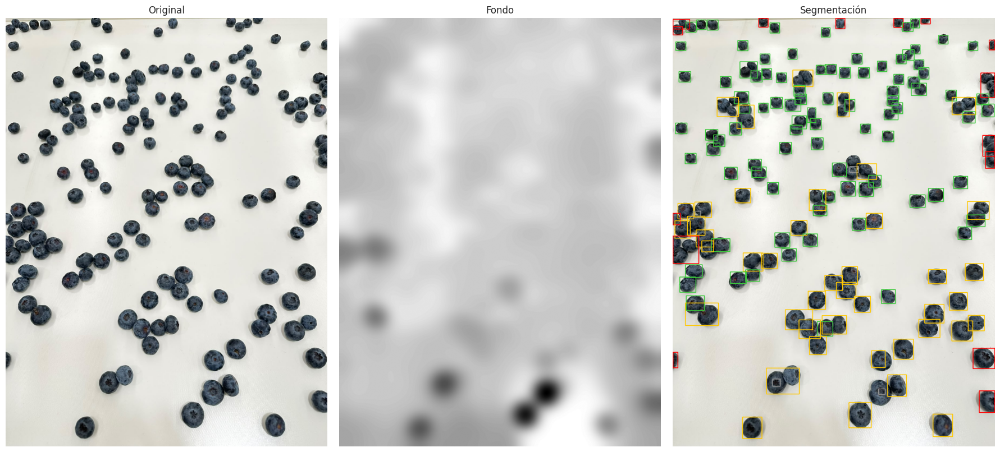

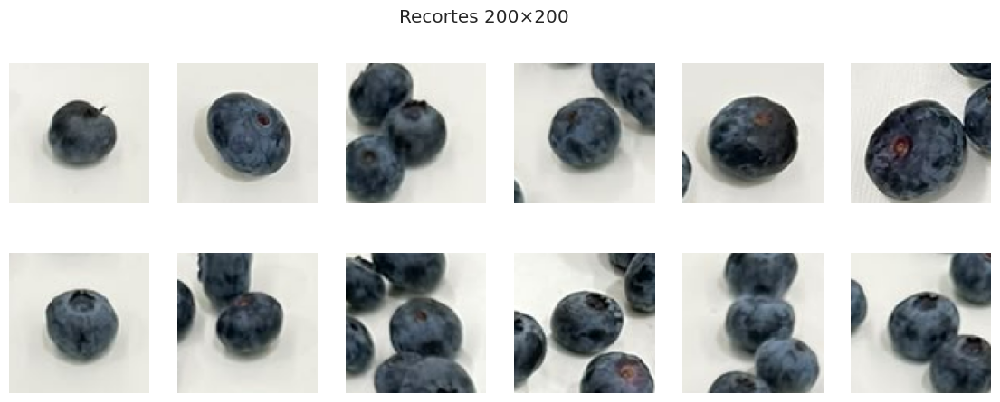

In [41]:
if HAS_IMG and SHOW_IMAGES:
    col = {"ok":(60,200,60),"fusionado":(0,200,255),"borde":(0,0,255),"pequeño":(150,150,150)}
    vis = img.copy()

    for r in objetos.itertuples():
        cv2.rectangle(vis,(int(r.x0),int(r.y0)),(int(r.x0+r.bw),int(r.y0+r.bh)),col[r.estado],2)

    fig,ax = plt.subplots(1,3,figsize=(18,8))
    ax[0].imshow(img[...,::-1]); ax[0].set_title("Original")
    ax[1].imshow(fondo,cmap="gray"); ax[1].set_title("Fondo")
    ax[2].imshow(vis[...,::-1]); ax[2].set_title("Segmentación")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

    ok = objetos[objetos.estado=="ok"]
    if len(ok):
        cr = recortar(img,ok.sample(min(12,len(ok)),random_state=1),D_MED_PX)
        fig,ax = plt.subplots(2,6,figsize=(14,5))
        for a in ax.ravel(): a.axis("off")
        for a,c in zip(ax.ravel(),cr): a.imshow(c[...,::-1])
        plt.suptitle("Recortes 200×200")
        plt.show()
else:
    print("Visualización omitida.")

**Decisiones para la vista de banda y su justificación**

| Problema observado | Decisión | Justificación |
|---|---|---|
| Gradiente de iluminación / sombras en la banda | Normalización dividiendo por el fondo estimado | Un umbral global fallaría en las zonas sombreadas; la división preserva el contraste fruto/banda |
| Frutos en contacto | Distancia + watershed | Separa contactos leves; los casos severos se marcan `fusionado` y **no** se clasifican |
| Frutos cortados en el borde del encuadre | Descarte (`borde`) en la foto de banda; en la máquina `image_processing.py` conserva parte de la imagen anterior y concatena los bloques (§0) | Un fruto parcial produce falsos defectos |
| Objetos pequeños | Descarte (`pequeño`) | Restos de hoja/pedúnculo, no frutos |
| Recorte de tamaño variable | Ventana 2.2× el diámetro → 200×200 | Entrada uniforme al modelo (Avance 0); el contexto de fondo blanco es constante |
| Los racimos densos elevan el % de fusionados | Reducir densidad con la banda de guías cada ~2 cm, que ordena un fruto por canal (§0) | Es más barato separar en la máquina que en software |

## 5. Dimensionamiento de subsistemas (análisis univariante)


Cada subsistema se dimensiona con un criterio explícito. Los gráficos muestran la sensibilidad de la decisión a su parámetro principal.

### 5.1 Cámara lineal: resolución, configuración e interfaz

El dimensionamiento parte de dos criterios de calidad de imagen: el defecto más pequeño (1 mm) debe abarcar al menos 4 px (**criterio A**) y el recorte de 200×200 no debe ampliar la imagen, es decir, el fruto debe medir al menos 100 px (**criterio B**). Se aplica el más exigente. Después se compara cuántas cámaras lineales Linea2 4k se necesitan según el campo de visión que cubre cada una: **A** (dos cámaras, una por mitad del ancho), **B** (dos cámaras enfrentadas, cada una cubriendo todo el ancho) y **C** (cuatro cámaras: dos mitades por dos caras). La resolución longitudinal queda fijada por el *line rate* (10 líneas/mm).

In [42]:
# Criterios de resolución espacial transversal
mm_px_A = DEFECTO_MIN_MM / PX_POR_DEFECTO          # A: el defecto mínimo debe abarcar PX_POR_DEFECTO píxeles
mm_px_B = FRUTO_DIAM_MM / PX_FRUTO_NATIVO          # B: el recorte de 200×200 no debe ampliar la imagen
mm_px_req = min(mm_px_A, mm_px_B)
px_mm_req = 1 / mm_px_req
diam_px_req = FRUTO_DIAM_MM / mm_px_req
mm_linea = 1 / LINEAS_POR_MM                       # resolución longitudinal (una línea cada 0.1 mm)

line_rate = VELOCIDAD_BANDA_MS * 1000 * LINEAS_POR_MM          # líneas/s
mbs_cam = PIXELS_CAMARA * 3 * line_rate / 1e6                   # MB/s por cámara (RGB, uint8)

print(f"A (defecto {DEFECTO_MIN_MM} mm × {PX_POR_DEFECTO} px): {mm_px_A:.3f} mm/px | B (fruto de {PX_FRUTO_NATIVO} px): {mm_px_B:.3f} mm/px")
print(f"Resolución transversal requerida: {mm_px_req:.3f} mm/px = {px_mm_req:.2f} px/mm → el fruto ocupa {diam_px_req:.0f} px")
print(f"Resolución longitudinal de diseño: {LINEAS_POR_MM:.0f} líneas/mm ({mm_linea:.2f} mm/línea) → line rate {line_rate:,.0f} líneas/s a {VELOCIDAD_BANDA_MS} m/s")
print(f"Foto de banda del dataset: {D_MED_PX:.0f} px por fruto → {'insuficiente' if D_MED_PX < PX_FRUTO_NATIVO else 'suficiente'} para el criterio B")

sensor_mm = PIXELS_CAMARA * PIXEL_UM / 1000
filas = []
for nombre, n_cam, fov, caras in [("A: 2 cámaras, una por mitad", 2, ANCHO_TOTAL_MM / 2, 1),
                                  ("B: 2 cámaras enfrentadas (800 mm c/u)", 2, ANCHO_TOTAL_MM, 2),
                                  ("C: 4 cámaras (2 mitades × 2 caras)", 4, ANCHO_TOTAL_MM / 2, 2)]:
    px_mm = PIXELS_CAMARA / fov
    mag = sensor_mm / fov
    filas.append({"configuración": nombre, "cámaras": n_cam, "FOV por cámara (mm)": fov, "px/mm transversal": px_mm,
                  "diámetro del fruto (px)": FRUTO_DIAM_MM * px_mm, "cumple A": (1 / px_mm) <= mm_px_A, "cumple B": (1 / px_mm) <= mm_px_B,
                  "relación px/mm ÷ líneas/mm": px_mm / LINEAS_POR_MM, "magnificación": mag, "distancia de trabajo (mm)": FOCAL_MM * (1 + 1 / mag),
                  "caras del fruto inspeccionadas": caras, "MB/s totales (RGB)": n_cam * mbs_cam})
CONFIGS = pd.DataFrame(filas).set_index("configuración")
display(CONFIGS.round(2))
CONFIG_ELEGIDA = next((n for n, r in CONFIGS.iterrows() if r["cumple A"] and r["cumple B"]), CONFIGS.index[0])   # la de menos cámaras que cumple A y B
print(f"→ Configuración que cumple los criterios con menos cámaras: {CONFIG_ELEGIDA}")
print("La configuración B (cada cámara cubre 800 mm) no alcanza los 100 px por fruto y deja la resolución transversal en la mitad de la longitudinal; "
      "la configuración C duplica el costo de cámaras a cambio de inspeccionar las dos caras del fruto.")

A (defecto 1.0 mm × 4 px): 0.250 mm/px | B (fruto de 100 px): 0.140 mm/px
Resolución transversal requerida: 0.140 mm/px = 7.14 px/mm → el fruto ocupa 100 px
Resolución longitudinal de diseño: 10 líneas/mm (0.10 mm/línea) → line rate 20,000 líneas/s a 2.0 m/s
Foto de banda del dataset: 41 px por fruto → insuficiente para el criterio B


,cámaras,FOV por cámara (mm),px/mm transversal,diámetro del fruto (px),cumple A,cumple B,relación px/mm ÷ líneas/mm,magnificación,distancia de trabajo (mm),caras del fruto inspeccionadas,MB/s totales (RGB)
configuración,,,,,,,,,,,
"A: 2 cámaras, una por mitad",2,400.0,10.24,143.36,True,True,1.02,0.07,299.02,1,491.52
B: 2 cámaras enfrentadas (800 mm c/u),2,800.0,5.12,71.68,True,False,0.51,0.04,578.04,2,491.52
C: 4 cámaras (2 mitades × 2 caras),4,400.0,10.24,143.36,True,True,1.02,0.07,299.02,2,983.04


→ Configuración que cumple los criterios con menos cámaras: A: 2 cámaras, una por mitad
La configuración B (cada cámara cubre 800 mm) no alcanza los 100 px por fruto y deja la resolución transversal en la mitad de la longitudinal; la configuración C duplica el costo de cámaras a cambio de inspeccionar las dos caras del fruto.


In [43]:
mm_px_ds = FRUTO_DIAM_MM/DS_DIAM_PX

print(f"Dataset: {DS_DIAM_PX:.0f}px/fruto | {mm_px_ds:.3f} mm/px")
print(f"Diseño cámara: {diam_px_req:.0f}px/fruto | {mm_px_req:.3f} mm/px")
print(f"Dataset tiene {DS_DIAM_PX/diam_px_req:.1f}× más píxeles por fruto.")

print("Existe brecha de dominio → evaluar varias resoluciones antes de fijar la resolución mínima de cámara.")

Dataset: 728px/fruto | 0.019 mm/px
Diseño cámara: 100px/fruto | 0.140 mm/px
Dataset tiene 7.3× más píxeles por fruto.
Existe brecha de dominio → evaluar varias resoluciones antes de fijar la resolución mínima de cámara.


,interfaz,MB/s útiles (aprox.),% de uso por cámara,cumple (≤ 80% de uso),margen de ancho de banda
0,GigE,115,213.7,False,0.5
1,USB3,350,70.2,True,1.4
2,5GigE,550,44.7,True,2.2
3,10GigE,1100,22.3,True,4.5
4,CoaXPress-12,1250,19.7,True,5.1


Cada cámara genera 246 MB/s en RGB (82 MB/s si fuera monocromática); con dos cámaras se requieren dos enlaces independientes (una tarjeta de red por cámara).


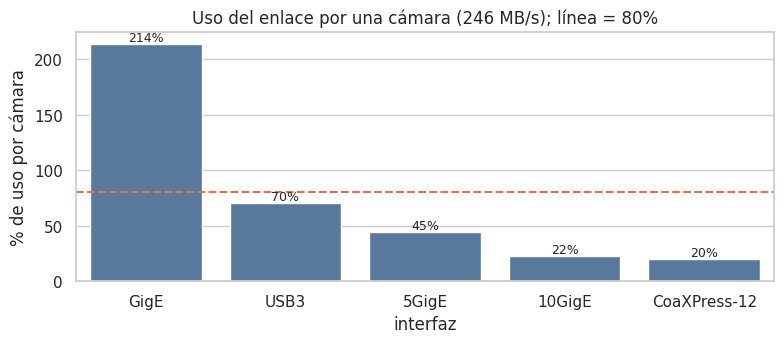

In [44]:
interfaces = pd.DataFrame({"interfaz": ["GigE", "USB3", "5GigE", "10GigE", "CoaXPress-12"], "MB/s útiles (aprox.)": [115, 350, 550, 1100, 1250]})
interfaces["% de uso por cámara"] = mbs_cam / interfaces["MB/s útiles (aprox.)"] * 100
interfaces["cumple (≤ 80% de uso)"] = interfaces["% de uso por cámara"] <= 80
interfaces["margen de ancho de banda"] = interfaces["MB/s útiles (aprox.)"] / mbs_cam
MBS_5GIGE = float(interfaces.loc[interfaces.interfaz == "5GigE", "MB/s útiles (aprox.)"].iloc[0])
display(interfaces.round(1))
print(f"Cada cámara genera {mbs_cam:.0f} MB/s en RGB ({mbs_cam/3:.0f} MB/s si fuera monocromática); con dos cámaras se requieren dos enlaces independientes (una tarjeta de red por cámara).")

plt.figure(figsize=(8, 3.6))
ax = sns.barplot(data=interfaces, x="interfaz", y="% de uso por cámara", color="#4c78a8")
ax.axhline(80, ls="--", c="#e76f51"); ax.set_title(f"Uso del enlace por una cámara ({mbs_cam:.0f} MB/s); línea = 80%")
for p in ax.patches: ax.annotate(f"{p.get_height():.0f}%", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

### 5.2 Iluminación y exposición

In [45]:
periodo_us = 1e6 / line_rate
t_exp_max_us = EXPOSICION_MAX_BLUR_LINEAS * mm_linea / (VELOCIDAD_BANDA_MS * 1000) * 1e6
t_exp_max_ms = t_exp_max_us / 1000
blur_periodo = VELOCIDAD_BANDA_MS * 1000 * (periodo_us / 1e6) / mm_linea
print(f"Periodo entre líneas a {VELOCIDAD_BANDA_MS} m/s: {periodo_us:.0f} µs (el fruto avanza {mm_linea:.2f} mm por línea)")
print(f"Con exposición igual al periodo ({periodo_us:.0f} µs) el desenfoque equivale a {blur_periodo:.1f} línea; para ≤ {EXPOSICION_MAX_BLUR_LINEAS} línea la exposición máxima es {t_exp_max_us:.0f} µs.")
print("Implicación: se requiere iluminación LED intensa y sincronizada (trigger rápido) para tener señal suficiente con exposiciones de decenas de µs; "
      "el rango de exposición de la cámara (5–3000 µs) lo permite.")
if HAS_IMG: print(f"Uniformidad de iluminación medida en la foto de banda: {uniformidad*100:.0f}% (objetivo de diseño ≥ 90% a lo ancho de la inspección).")

Periodo entre líneas a 2.0 m/s: 50 µs (el fruto avanza 0.10 mm por línea)
Con exposición igual al periodo (50 µs) el desenfoque equivale a 1.0 línea; para ≤ 0.5 línea la exposición máxima es 25 µs.
Implicación: se requiere iluminación LED intensa y sincronizada (trigger rápido) para tener señal suficiente con exposiciones de decenas de µs; el rango de exposición de la cámara (5–3000 µs) lo permite.
Uniformidad de iluminación medida en la foto de banda: 87% (objetivo de diseño ≥ 90% a lo ancho de la inspección).


### 5.3 Cómputo: preprocesamiento (CPU) e inferencia (GPU)

Bloque de 256 líneas = 12.8 ms (78 bloques/s por cámara, 1.05 MP) · frutos por bloque: 0.9 (típico) / 10 (pico)
Preprocesamiento del bloque (medido en la foto de banda y escalado): reducción 4.4 ms + segmentación 4.8 ms (0.020 MP de trabajo) + recortes 1.5 ms = 10.7 ms
Inferencia en el caso pico (2.0 ms/recorte, supuesto): 20 ms
Uso del tiempo de bloque en un solo hilo (pico): 240% → excede el periodo del bloque: se requiere segmentación e inferencia en núcleos distintos (pipeline), como prevé Main
Referencia: el extractor del dataset sin reducir tarda ≈48 ms por foto de 12 MP; reducir antes de segmentar evita ese costo.


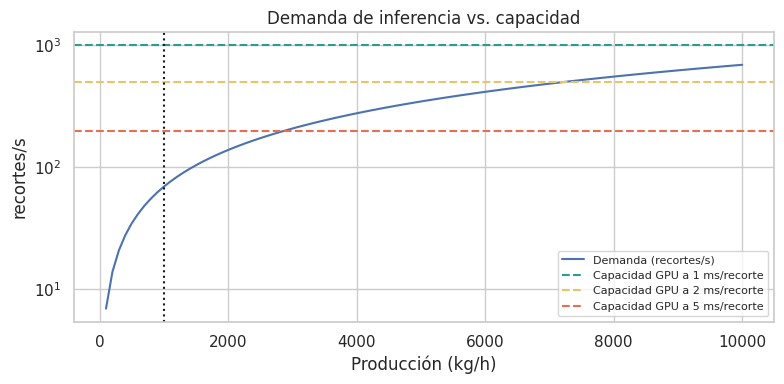

In [46]:
t_bloque_ms = BLOQUE_LINEAS / line_rate * 1000
bloques_s = line_rate / BLOQUE_LINEAS
frutos_bloque_tip = FRUTOS_POR_S * t_bloque_ms / 1000
mp_bloque = BLOQUE_LINEAS * PIXELS_CAMARA / 1e6              # megapíxeles de un bloque por cámara
f_red = D_TRABAJO_PX / diam_px_req                            # reducción hasta el tamaño de trabajo de la segmentación (§4.8)
mp_trab = mp_bloque * f_red ** 2

T_PRE_RED = T_RESIZE_MS * mp_bloque / MP_IMG
T_PRE_SEG = T_SEG_MS * mp_trab / MP_TRABAJO_EJ
T_PRE_MS = T_PRE_RED + T_PRE_SEG + FRUTOS_POR_BLOQUE_PICO * T_CROP_MS
inf_ms = FRUTOS_POR_BLOQUE_PICO * INFER_MS_CROP

print(f"Bloque de {BLOQUE_LINEAS} líneas = {t_bloque_ms:.1f} ms ({bloques_s:.0f} bloques/s por cámara, {mp_bloque:.2f} MP) · frutos por bloque: {frutos_bloque_tip:.1f} (típico) / {FRUTOS_POR_BLOQUE_PICO} (pico)")
print(f"Preprocesamiento del bloque (medido en la foto de banda y escalado): reducción {T_PRE_RED:.1f} ms + segmentación {T_PRE_SEG:.1f} ms ({mp_trab:.3f} MP de trabajo) + recortes {FRUTOS_POR_BLOQUE_PICO*T_CROP_MS:.1f} ms = {T_PRE_MS:.1f} ms")
print(f"Inferencia en el caso pico ({INFER_MS_CROP} ms/recorte, supuesto): {inf_ms:.0f} ms")
print(f"Uso del tiempo de bloque en un solo hilo (pico): {(T_PRE_MS + inf_ms)/t_bloque_ms*100:.0f}% → "
      + ("cabe en un hilo" if (T_PRE_MS + inf_ms) <= t_bloque_ms else "excede el periodo del bloque: se requiere segmentación e inferencia en núcleos distintos (pipeline), como prevé Main"))
print(f"Referencia: el extractor del dataset sin reducir tarda ≈{T_EXTRACT_MS:.0f} ms por foto de {DS_MP:.0f} MP; reducir antes de segmentar evita ese costo.")

kgh = np.linspace(100, 10000, 100)
fr = kgh * 1000 / 3600 / FRUTO_PESO_G
plt.figure(figsize=(8, 4))
plt.plot(kgh, fr, label="Demanda (recortes/s)")
for ms, c in [(1, "#2a9d8f"), (2, "#e9c46a"), (5, "#e76f51")]: plt.axhline(1000 / ms, ls="--", c=c, label=f"Capacidad GPU a {ms} ms/recorte")
plt.axvline(PRODUCCION_KG_H, ls=":", c="k"); plt.xlabel("Producción (kg/h)"); plt.ylabel("recortes/s"); plt.yscale("log")
plt.title("Demanda de inferencia vs. capacidad"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

### 5.4 Actuadores: eyectores y ventana de actuación

In [47]:
n_canales = math.ceil(ANCHO_TOTAL_MM / ANCHO_GUIA_MM)
n_usb = math.ceil(n_canales / USB_SALIDAS)
t_foto = math.sqrt(2 * ALTURA_FOTO_M / G_MS2); t_rechazo = math.sqrt(2 * ALTURA_RECHAZO_M / G_MS2)
vx = VELOCIDAD_BANDA_MS; vy = G_MS2 * t_rechazo; v_rech = math.hypot(vx, vy)
ventana_ms = FRUTO_DIAM_MM / (v_rech * 1000) * 1000
print(f"Canales de eyección: ⌈{ANCHO_TOTAL_MM:.0f}/{ANCHO_GUIA_MM:.0f}⌉ = {n_canales} → {n_usb} módulos USB-5856 ({USB_SALIDAS} salidas c/u) = {n_usb*USB_SALIDAS} salidas disponibles")
print(f"Velocidad del fruto al llegar a la boquilla: horizontal {vx:.2f} m/s, vertical {vy:.2f} m/s → {v_rech:.2f} m/s")
print(f"Ventana de actuación: {FRUTO_DIAM_MM:.0f} mm a {v_rech:.2f} m/s = {ventana_ms:.1f} ms → apertura de la válvula ({T_VALVULA_MS:.0f} ms) + aire ({T_AIRE_MS:.0f} ms) ocupan casi toda la ventana")
print(f"Jitter admisible: ≪ {ventana_ms/2:.1f} ms; el jitter supuesto del comando USB/sistema operativo ({T_USB_OS_MS:.0f} ms) lo excede → los eventos deben programarse con anticipación y verificarse con temporización por hardware (§9)")
print(f"Eyecciones por canal con 10% de rechazo: {FRUTOS_POR_S*0.1/n_canales:.2f}/s en promedio")

Canales de eyección: ⌈800/20⌉ = 40 → 2 módulos USB-5856 (32 salidas c/u) = 64 salidas disponibles
Velocidad del fruto al llegar a la boquilla: horizontal 2.00 m/s, vertical 2.43 m/s → 3.14 m/s
Ventana de actuación: 14 mm a 3.14 m/s = 4.5 ms → apertura de la válvula (2 ms) + aire (2 ms) ocupan casi toda la ventana
Jitter admisible: ≪ 2.2 ms; el jitter supuesto del comando USB/sistema operativo (5 ms) lo excede → los eventos deben programarse con anticipación y verificarse con temporización por hardware (§9)
Eyecciones por canal con 10% de rechazo: 0.17/s en promedio


## 6. Relaciones entre parámetros (análisis bi/multivariante)


En lugar de correlaciones entre columnas de un dataset, se estudian las **relaciones entre los parámetros de diseño**, que determinan el compromiso de la arquitectura.

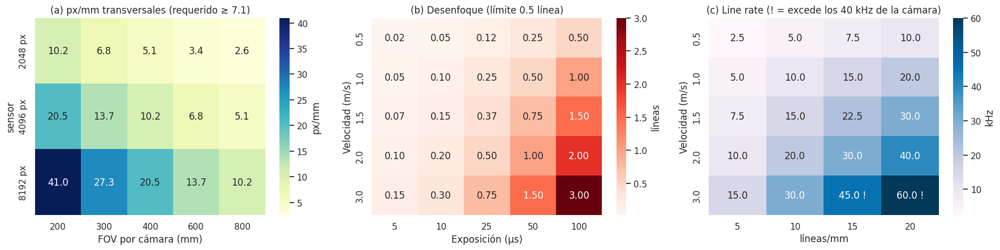

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))

# (a) píxeles por mm transversales según el sensor y el campo de visión de cada cámara
px_s = np.array([2048, 4096, 8192]); fovs = np.array([200, 300, 400, 600, 800])
M = pd.DataFrame([[p / f for f in fovs] for p in px_s], index=[f"{p} px" for p in px_s], columns=fovs)
sns.heatmap(M, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax[0], cbar_kws={"label": "px/mm"})
ax[0].set_title(f"(a) px/mm transversales (requerido ≥ {px_mm_req:.1f})"); ax[0].set_xlabel("FOV por cámara (mm)"); ax[0].set_ylabel("sensor")

# (b) desenfoque de movimiento, en líneas de barrido, según velocidad y exposición
vel = np.array([.5, 1, 1.5, 2, 3]); exp_us = np.array([5, 10, 25, 50, 100])
B = pd.DataFrame([[v * 1000 * (e / 1e6) / mm_linea for e in exp_us] for v in vel], index=vel, columns=exp_us)
sns.heatmap(B, annot=True, fmt=".2f", cmap="Reds", ax=ax[1], cbar_kws={"label": "líneas"})
ax[1].set_title(f"(b) Desenfoque (límite {EXPOSICION_MAX_BLUR_LINEAS} línea)"); ax[1].set_xlabel("Exposición (µs)"); ax[1].set_ylabel("Velocidad (m/s)")

# (c) line rate (kHz) según velocidad y resolución longitudinal; ✗ = excede el máximo de la cámara
lpm = np.array([5, 10, 15, 20])
L = pd.DataFrame([[v * 1000 * l / 1000 for l in lpm] for v in vel], index=vel, columns=lpm)
sns.heatmap(L, annot=L.round(1).astype(str) + np.where(L * 1000 > LINE_RATE_MAX_HZ, " !", ""), fmt="", cmap="PuBu", ax=ax[2], cbar_kws={"label": "kHz"})
ax[2].set_title(f"(c) Line rate (! = excede los {LINE_RATE_MAX_HZ/1000:.0f} kHz de la cámara)"); ax[2].set_xlabel("líneas/mm"); ax[2].set_ylabel("Velocidad (m/s)")
plt.tight_layout(); plt.show()

Densidad de diseño en la banda: 43 frutos/m² → cobertura ≈ 0.67% (a 1000 kg/h, 2.0 m/s y 800 mm)
Foto de banda del dataset: cobertura 19.0% | fusionados 28.1% | borde 9.8% | útiles 59.5%
→ La banda con guías (~2 cm) fija un canal por fruto y mantiene la cobertura muy por debajo de la de la foto, lo que reduce los frutos fusionados.


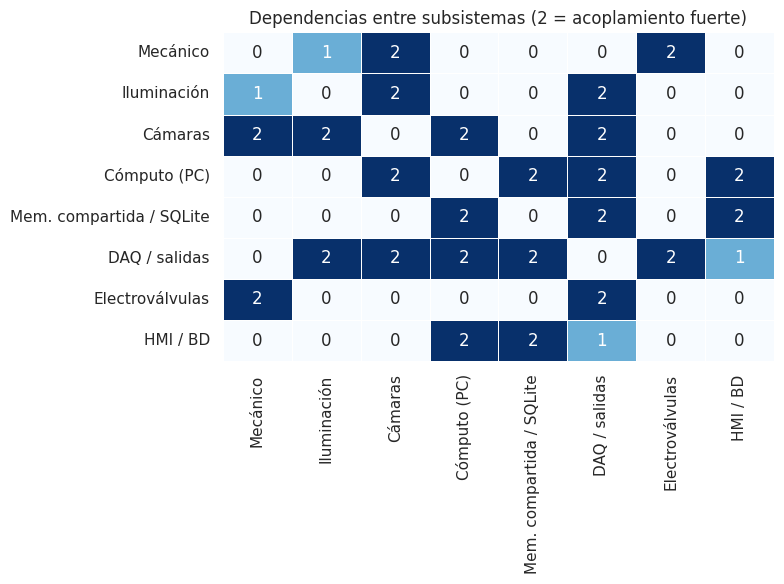

In [49]:
dens = FRUTOS_POR_S / (VELOCIDAD_BANDA_MS * ANCHO_TOTAL_MM / 1000)
cob = dens * np.pi * (FRUTO_DIAM_MM / 2000) ** 2
print(f"Densidad de diseño en la banda: {dens:.0f} frutos/m² → cobertura ≈ {cob*100:.2f}% (a {PRODUCCION_KG_H:.0f} kg/h, {VELOCIDAD_BANDA_MS} m/s y {ANCHO_TOTAL_MM:.0f} mm)")
if HAS_IMG:
    print(f"Foto de banda del dataset: cobertura {cobertura*100:.1f}% | fusionados {fus_pct:.1f}% | borde {borde_pct:.1f}% | útiles {ok_pct:.1f}%")
    print("→ La banda con guías (~2 cm) fija un canal por fruto y mantiene la cobertura muy por debajo de la de la foto, lo que reduce los frutos fusionados.")

sub = ["Mecánico", "Iluminación", "Cámaras", "Cómputo (PC)", "Mem. compartida / SQLite", "DAQ / salidas", "Electroválvulas", "HMI / BD"]
dep = pd.DataFrame(0, index=sub, columns=sub)
def link(a, b, v): dep.loc[a, b] = dep.loc[b, a] = v
for a, b, v in [("Mecánico", "Iluminación", 1), ("Mecánico", "Cámaras", 2), ("Mecánico", "Electroválvulas", 2), ("Iluminación", "Cámaras", 2),
                ("Iluminación", "DAQ / salidas", 2), ("Cámaras", "DAQ / salidas", 2), ("Cámaras", "Cómputo (PC)", 2),
                ("Cómputo (PC)", "Mem. compartida / SQLite", 2), ("Mem. compartida / SQLite", "DAQ / salidas", 2), ("Cómputo (PC)", "DAQ / salidas", 2),
                ("DAQ / salidas", "Electroválvulas", 2), ("Cómputo (PC)", "HMI / BD", 2), ("Mem. compartida / SQLite", "HMI / BD", 2), ("DAQ / salidas", "HMI / BD", 1)]:
    link(a, b, v)
plt.figure(figsize=(8, 6))
sns.heatmap(dep, annot=True, cmap="Blues", cbar=False, linewidths=.5)
plt.title("Dependencias entre subsistemas (2 = acoplamiento fuerte)"); plt.tight_layout(); plt.show()

## 7. Presupuesto de latencia y sincronización


El fruto se fotografía a 20 cm de caída libre y se expulsa a 30 cm; el tiempo disponible entre ambos (≈45 ms) depende solo de esas alturas, no de la velocidad de la banda. La suma de las latencias del sistema —cierre de bloque, transferencia, preprocesamiento, inferencia, comunicación con el DAQ, válvula y aire— debe ser menor que ese tiempo. De ahí sale la geometría de la máquina.

,Captura restante del fruto,Cierre del bloque,Transferencia del bloque,Preprocesamiento,Inferencia,Tracking + set_actions,USB + sistema operativo,Optoacoplador DAQ,Electroválvula,Aire hasta la boquilla
ms,3.5,12.8,5.72,10.69,20.0,2.0,5.0,0.1,2.0,2.0


Tiempo disponible (caída de 20 a 30 cm): 45.4 ms
Latencia estimada: 63.8 ms · con margen de 25%: 79.8 ms → NO CUMPLE (excede en 34.4 ms)
Altura de rechazo necesaria con esa latencia: 39 cm de caída (hoy 30 cm) → 9 cm adicionales


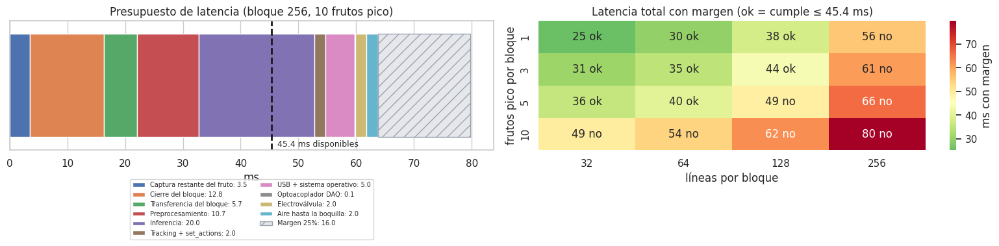

Combinaciones que cumplen: [(32, 1), (64, 1), (128, 1), (32, 3), (64, 3), (128, 3), (32, 5), (64, 5)]


In [50]:
T_DISP_MS = (t_rechazo - t_foto) * 1000       # tiempo disponible entre la línea de captura y las boquillas: depende solo de las alturas de caída

def latencia_ms(bloque_lineas, frutos_pico):
    t_bloque = bloque_lineas / line_rate * 1000
    mb_bloque = bloque_lineas * PIXELS_CAMARA * 3 / 1e6
    mp_b = bloque_lineas * PIXELS_CAMARA / 1e6
    t_pre = T_RESIZE_MS * mp_b / MP_IMG + T_SEG_MS * (mp_b * f_red ** 2) / MP_TRABAJO_EJ + frutos_pico * T_CROP_MS
    return pd.Series({
        "Captura restante del fruto": (FRUTO_DIAM_MM / 2) * LINEAS_POR_MM / line_rate * 1000,
        "Cierre del bloque": t_bloque,
        "Transferencia del bloque": mb_bloque / MBS_5GIGE * 1000,
        "Preprocesamiento": t_pre,
        "Inferencia": frutos_pico * INFER_MS_CROP,
        "Tracking + set_actions": T_COLA_TRACK_MS,
        "USB + sistema operativo": T_USB_OS_MS,
        "Optoacoplador DAQ": T_DAQ_OPTO_MS,
        "Electroválvula": T_VALVULA_MS,
        "Aire hasta la boquilla": T_AIRE_MS})

etapas = latencia_ms(BLOQUE_LINEAS, FRUTOS_POR_BLOQUE_PICO)
T_total = etapas.sum() * (1 + MARGEN_LATENCIA)
display(etapas.round(2).to_frame("ms").T)
print(f"Tiempo disponible (caída de {ALTURA_FOTO_M*100:.0f} a {ALTURA_RECHAZO_M*100:.0f} cm): {T_DISP_MS:.1f} ms")
print(f"Latencia estimada: {etapas.sum():.1f} ms · con margen de {MARGEN_LATENCIA*100:.0f}%: {T_total:.1f} ms → " + ("CUMPLE" if T_total <= T_DISP_MS else f"NO CUMPLE (excede en {T_total-T_DISP_MS:.1f} ms)"))
h_req = 0.5 * G_MS2 * (t_foto + T_total / 1000) ** 2
print(f"Altura de rechazo necesaria con esa latencia: {h_req*100:.0f} cm de caída (hoy {ALTURA_RECHAZO_M*100:.0f} cm) → {max(h_req-ALTURA_RECHAZO_M,0)*100:.0f} cm adicionales")

bs = [32, 64, 128, 256]; pk = [1, 3, 5, 10]
S = pd.DataFrame([[latencia_ms(b, p).sum() * (1 + MARGEN_LATENCIA) for b in bs] for p in pk], index=pk, columns=bs)
fig, ax = plt.subplots(1, 2, figsize=(16, 4.2))
left = 0
for k, v in etapas.items():
    ax[0].barh(0, v, left=left, label=f"{k}: {v:.1f}"); left += v
ax[0].barh(0, etapas.sum() * MARGEN_LATENCIA, left=left, color="#e5e7eb", hatch="//", edgecolor="#9ca3af", label=f"Margen {MARGEN_LATENCIA*100:.0f}%: {etapas.sum()*MARGEN_LATENCIA:.1f}")
ax[0].axvline(T_DISP_MS, c="k", ls="--", lw=2); ax[0].text(T_DISP_MS + 1, -0.42, f"{T_DISP_MS:.1f} ms disponibles", fontsize=9, va="top")
ax[0].set_ylim(-0.5, 0.5); ax[0].set_yticks([]); ax[0].set_xlabel("ms"); ax[0].set_title(f"Presupuesto de latencia (bloque {BLOQUE_LINEAS}, {FRUTOS_POR_BLOQUE_PICO} frutos pico)")
ax[0].legend(fontsize=7, loc="upper center", bbox_to_anchor=(.5, -.2), ncol=2)
sns.heatmap(S, annot=S.round(0).astype(int).astype(str) + np.where(S <= T_DISP_MS, " ok", " no"), fmt="", cmap="RdYlGn_r", center=T_DISP_MS, ax=ax[1], cbar_kws={"label": "ms con margen"})
ax[1].set_title(f"Latencia total con margen (ok = cumple ≤ {T_DISP_MS:.1f} ms)"); ax[1].set_xlabel("líneas por bloque"); ax[1].set_ylabel("frutos pico por bloque")
plt.tight_layout(); plt.show()
ok_cfg = [(b, p) for p in pk for b in bs if S.loc[p, b] <= T_DISP_MS]
print("Combinaciones que cumplen:", ok_cfg if ok_cfg else "ninguna con los supuestos actuales")

**Sincronización.** La referencia de posición es el **encoder / line trigger por hardware**: la cámara captura una línea por cada 0.1 mm de avance sin depender del reloj del PC, de modo que la resolución longitudinal se conserva aunque cambie la velocidad. Cada fruto se registra con su posición y su línea/timestamp; `set_actions` convierte los frutos malos en acciones con canal e instante objetivo y las guarda en un buffer circular de memoria compartida, y `actions` las ejecuta por el DAQ. Como el comando USB y el sistema operativo no son deterministas, las acciones se programan con anticipación y la temporización fina de las salidas debería migrar a hardware si la ventana de actuación (≈4.5 ms) lo exige. Este es el principio que se desarrolla en el Avance 2 (tracking y sincronización).

## 8. Arquitectura general y flujo de información

El diagrama de bloques de la arquitectura de referencia está en §1. Aquí se presenta la secuencia temporal de un fruto rechazado y el mapeo entre la arquitectura industrial y el MVP del equipo.

In [51]:
# Funciones de dibujo para los wireframes de la HMI (§11)
def box(ax, x, y, w, h, text, fc="#dbeafe", ec="#1e40af", fs=9, bold=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08", fc=fc, ec=ec, lw=1.4))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, fontweight="bold" if bold else "normal", wrap=True)

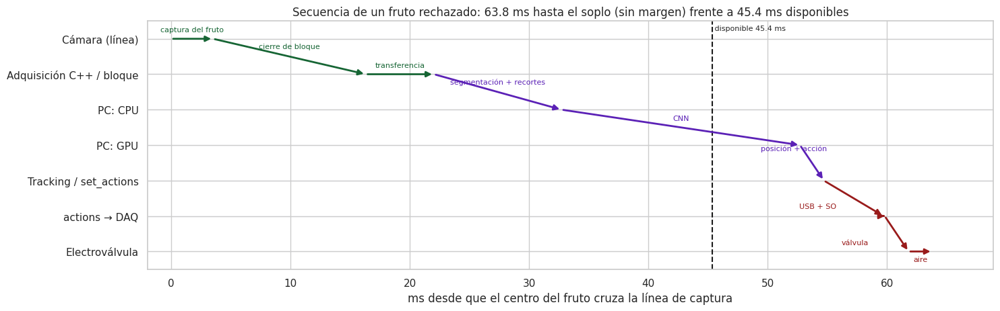

In [52]:
lanes = ["Cámara (línea)", "Adquisición C++ / bloque", "PC: CPU", "PC: GPU", "Tracking / set_actions", "actions → DAQ", "Electroválvula"]
e = etapas
segs = [("Captura restante del fruto", 0, 0, "captura del fruto", "#166534"),
        ("Cierre del bloque", 0, 1, "cierre de bloque", "#166534"),
        ("Transferencia del bloque", 1, 1, "transferencia", "#166534"),
        ("Preprocesamiento", 1, 2, "segmentación + recortes", "#5b21b6"),
        ("Inferencia", 2, 3, "CNN", "#5b21b6"),
        ("Tracking + set_actions", 3, 4, "posición + acción", "#5b21b6"),
        ("USB + sistema operativo", 4, 5, "USB + SO", "#991b1b"),
        ("Optoacoplador DAQ", 5, 5, "DAQ", "#991b1b"),
        ("Electroválvula", 5, 6, "válvula", "#991b1b"),
        ("Aire hasta la boquilla", 6, 6, "aire", "#991b1b")]
t0 = 0.0; marcas = []
for nombre, la, lb, txt, c in segs:
    t1 = t0 + float(e[nombre]); marcas.append((t0, t1, la, lb, txt, c)); t0 = t1
fig, ax = plt.subplots(figsize=(15, 4.8)); ax.set_ylim(-.5, len(lanes) - .5); ax.invert_yaxis()
for i in range(len(lanes)): ax.axhline(i, c="#d1d5db", lw=.8, zorder=0)
dy_lab = [-.2, -.22, -.2, -.22, -.2, -.35, .28, None, .3, .28]            # separación vertical de cada etiqueta (None = sin etiqueta)
dx_lab = [0, 0, 0, 0, 0, -1.5, -3, 0, -3.5, 0]
for k, (a, b, la, lb, txt, c) in enumerate(marcas):
    ax.annotate("", xy=(b, lb), xytext=(a, la), arrowprops=dict(arrowstyle="-|>", color=c, lw=2))
    if dy_lab[k] is not None:
        ax.text((a + b) / 2 + dx_lab[k], (la + lb) / 2 + dy_lab[k], txt, ha="center", fontsize=8, color=c)
ax.axvline(T_DISP_MS, c="k", ls="--"); ax.text(T_DISP_MS, -.4, f" disponible {T_DISP_MS:.1f} ms", fontsize=8, va="top")
ax.set_xlim(-2, max(t0, T_DISP_MS) * 1.08); ax.set_yticks(range(len(lanes))); ax.set_yticklabels(lanes); ax.set_xlabel("ms desde que el centro del fruto cruza la línea de captura")
ax.set_title(f"Secuencia de un fruto rechazado: {t0:.1f} ms hasta el soplo (sin margen) frente a {T_DISP_MS:.1f} ms disponibles")
plt.tight_layout(); plt.show()

### Mapeo arquitectura industrial → MVP del equipo

| Componente industrial (SOLID México) | Sustituto en el MVP (alcance académico) | Qué se valida |
|---|---|---|
| Banda con guías (~2 cm) y caída libre | Fotografías estáticas del dataset y de la banda | Segmentación y clasificación por fruto |
| 2 cámaras lineales Linea2 4k (5GigE) con iluminación de trigger rápido | Cámara web o smartphone en soporte estático con iluminación LED constante | Preprocesamiento, calidad del recorte, modelo |
| PC industrial con GPU; procesos asíncronos coordinados por Main | Equipo del equipo (GPU de escritorio o CPU) | Tiempo de inferencia por recorte y pipeline entre procesos |
| Memoria compartida y buffer circular de acciones | Igual: se implementa en el MVP | Desacople entre visión y actuación |
| Tracking físico y salidas reales (USB-5856, relevadores y 40 electroválvulas) | Simulación: ID y posición virtual, más un simulador de salidas que registra canal e instante | Lógica de asociación, formato y temporización de las órdenes (Avance 2) |
| HMI industrial (Advantech SPC-821) | Dashboard web (resultado, confianza, historial) | Visualización y trazabilidad |
| SQLite de producción | SQLite local | Parámetros, registro y estadísticas de lote |

## 9. Selección de componentes


Con base en los resultados obtenidos en la memoria de cálculo, se realiza la selección de los principales componentes que conforman el sistema de visión y rechazo. La selección se lleva a cabo considerando los requerimientos de velocidad, resolución, distancia de trabajo, tiempo de procesamiento y sincronización necesarios para garantizar el funcionamiento adecuado del sistema.

En esta sección se evaluarán y seleccionarán los siguientes elementos:

- **Cámara lineal:** seleccionada de acuerdo con la resolución requerida, el *line rate* calculado, el ancho de inspección y la velocidad máxima de operación de la banda.
- **Lente:** seleccionado en función del tamaño del sensor de la cámara, el campo de visión requerido, la distancia de trabajo y la resolución necesaria sobre el producto.
- **Distancia de instalación de la cámara:** determinada a partir de las características ópticas del lente, el campo de visión requerido y las condiciones mecánicas disponibles para la integración del sistema.
- **Módulo de procesamiento y salidas:** seleccionado de acuerdo con el tiempo disponible entre la adquisición de la imagen y el punto de rechazo, así como con la cantidad de salidas y la velocidad de respuesta necesaria para accionar las electroválvulas.
- **Sistema de control de iluminación:** seleccionado considerando el tipo de iluminación utilizada, la potencia requerida, la posibilidad de sincronización con la cámara y la velocidad de conmutación necesaria durante la adquisición de las imágenes.

El objetivo de esta selección es asegurar que cada componente tenga la capacidad suficiente para operar dentro de los parámetros definidos en la memoria de cálculo y que, en conjunto, el sistema pueda adquirir, procesar y clasificar los arándanos en tiempo real, generando la señal de rechazo dentro del tiempo disponible antes de que el producto alcance el punto de separación.

### Selección de componentes vinculados a velocidad de respuesta

La selección de componentes se realiza a partir de los requerimientos obtenidos en la memoria de cálculo. El sistema deberá mantener una resolución longitudinal de **10 líneas/mm** y disponer de aproximadamente **45.4 ms** entre la toma de la imagen, ubicada a **20 cm de caída**, y el punto de rechazo, ubicado a **30 cm**.

Por lo tanto, la cámara, la iluminación, el procesamiento y el accionamiento neumático deben trabajar dentro de este presupuesto temporal.

---

## Cámara lineal

Se propone utilizar **dos cámaras Teledyne DALSA Linea2 L2-GC-04k04T-00**, una para cada mitad del ancho de inspección (configuración A de la comparación de §5.1; la B, con cámaras enfrentadas que cubren 800 mm cada una, no alcanza los 100 px por fruto, y la C, con cuatro cámaras, permitiría inspeccionar ambas caras).

Cada cámara cuenta con las siguientes características relevantes:

- Resolución: **4096 píxeles**
- Tamaño de píxel: **7 µm**
- Interfaz: **5GigE**
- *Line rate* máximo: **40 kHz**
- Campo de visión por cámara: **400 mm**

Al cubrir 400 mm por cámara se obtiene una resolución transversal de:

$$
\frac{4096\ \mathrm{px}}{400\ \mathrm{mm}}
=
10.24\ \mathrm{px/mm}
$$

Para mantener una resolución longitudinal de **10 líneas/mm**, con una velocidad de banda de:

$$
V = 2\ \mathrm{m/s}
$$

se requiere un *line rate* de:

$$
f_L
=
2\ \mathrm{m/s}
\times
1000\ \mathrm{mm/m}
\times
10\ \mathrm{líneas/mm}
$$

$$
f_L = 20{,}000\ \mathrm{líneas/s}
$$

El periodo entre líneas será:

$$
T
=
\frac{1}{20{,}000}
=
50\ \mu\mathrm{s}
$$

La capacidad máxima de **40 kHz** de la cámara permite una velocidad teórica máxima de:

$$
V_{\mathrm{max}}
=
\frac{40{,}000}
{10\times1000}
=
4\ \mathrm{m/s}
$$

manteniendo una resolución de **10 líneas/mm**.

El rango de exposición de la cámara es de **5 µs a 3000 µs**.

A una velocidad de banda de 2 m/s, una exposición de 50 µs corresponde a un desplazamiento del producto de:

$$
d
=
2\ \mathrm{m/s}
\times
50\times10^{-6}\ \mathrm{s}
$$

$$
d
=
0.0001\ \mathrm{m}
=
0.1\ \mathrm{mm}
$$

Este desplazamiento corresponde aproximadamente a una muestra longitudinal cuando se trabaja a 10 líneas/mm.

Por lo tanto, para reducir el desenfoque por movimiento se recomienda trabajar con tiempos de exposición iguales o inferiores al periodo entre líneas, utilizando iluminación suficiente para mantener una intensidad adecuada en la imagen.

---

## Lente

Se propone utilizar el lente **Hikrobot MVL-AF2045M-M42**.

Características principales:

- Distancia focal: **20 mm**
- Montura: **M42**
- Tamaño máximo de imagen: **30 mm**
- Compatible con cámaras lineales **4K**
- Compatible con píxel de **7 µm**
- Rango aproximado de magnificación: **0.02× a 0.1×**

El sensor de la cámara tiene un ancho activo de:

$$
4096
\times
7\ \mu\mathrm{m}
=
28.672\ \mathrm{mm}
$$

Para cubrir un campo de visión de 400 mm, la magnificación requerida es:

$$
M
=
\frac{28.672}{400}
$$

$$
M
\approx
0.0717
$$

Este valor se encuentra dentro del rango de operación del lente.

Utilizando una aproximación de lente delgado:

$$
\frac{1}{f}
=
\frac{1}{u}
+
\frac{1}{v}
$$

y considerando:

$$
M=\frac{v}{u}
$$

se obtiene una distancia nominal de trabajo cercana a:

$$
\boxed{WD \approx 300\ \mathrm{mm}}
$$

Esta distancia deberá utilizarse como referencia inicial para el diseño mecánico. La posición definitiva de la cámara deberá ajustarse durante el proceso de enfoque y validarse con el montaje real.

---

## Control de iluminación

Para el control rápido de la iluminación se propone utilizar el módulo **NI-9474**.

Características relevantes:

- **8 salidas digitales**
- Salidas tipo **sourcing**
- Voltaje de operación: **5 a 30 VDC**
- Retardo máximo de salida: aproximadamente **1 µs**

El tiempo de respuesta del módulo es considerablemente menor que el periodo de adquisición de la cámara.

Para una adquisición de:

$$
f_L = 20\ \mathrm{kHz}
$$

el periodo entre líneas es:

$$
T
=
\frac{1}{20{,}000}
=
50\ \mu\mathrm{s}
$$

Por lo tanto, un retardo de aproximadamente:

$$
t_{\mathrm{NI}} \approx 1\ \mu\mathrm{s}
$$

representa únicamente una pequeña fracción del periodo disponible.

La proporción aproximada es:

$$
\frac{1\ \mu\mathrm{s}}
{50\ \mu\mathrm{s}}
\times100
=
2\%
$$

Para aprovechar esta velocidad se deberá utilizar **temporización por hardware** mediante un chasis compatible, evitando depender de instrucciones individuales ejecutadas desde Windows para generar cada pulso.

---

## Iluminación principal

La iluminación principal propuesta es:

**Metaphase Exolight v2.0 ISO2-25-RGBWIR850-24-ILZFT5**

La familia ISO2 trabaja a:

- Alimentación: **24 VDC**
- Iluminación: **RGB + White + IR**
- Longitud de onda IR: **850 nm**
- Control de intensidad: **0–10 V**
- Driver con **Fast Trigger**

El driver **ILZFT** permite realizar disparos rápidos de la iluminación.

Metaphase especifica que sus drivers Fast Trigger pueden aceptar señales de hasta aproximadamente:

$$
f_{\mathrm{trigger,max}}
\approx
300\ \mathrm{kHz}
$$

Este valor es considerablemente superior al *line rate* esperado de:

$$
f_L
=
20\ \mathrm{kHz}
$$

La relación disponible es aproximadamente:

$$
\frac{300\ \mathrm{kHz}}
{20\ \mathrm{kHz}}
=
15
$$

por lo que la capacidad de disparo del sistema de iluminación es aproximadamente **15 veces superior** a la frecuencia requerida para una operación de 20 kHz.

Durante la integración deberá verificarse el diagrama eléctrico específico de la versión utilizada y la compatibilidad de los niveles de disparo con las salidas del **NI-9474**.

---

## Iluminación alternativa

Como segunda alternativa se considera la:

**Smart Vision Lights LXE300**

Esta luminaria incorpora su propio driver y puede trabajar en:

- Modo continuo
- Modo **OverDrive Strobe**

El modo OverDrive permite pulsos desde aproximadamente:

$$
t_{\mathrm{pulso,min}}
\approx
10\ \mu\mathrm{s}
$$

y presenta un ciclo de trabajo máximo aproximado de:

$$
D_{\mathrm{max}}
\approx
10\%
$$

Debido a que el periodo entre líneas a 20 kHz es:

$$
T=50\ \mu\mathrm{s}
$$

un pulso de 10 µs representaría un ciclo de trabajo de:

$$
D
=
\frac{10}{50}
\times100
=
20\%
$$

Este valor supera un ciclo de trabajo del 10 %, por lo que el modo OverDrive deberá analizarse cuidadosamente si se pretende disparar una vez por cada línea adquirida.

Por esta razón, para una aplicación de *line scan* de alta frecuencia, esta alternativa resulta más conveniente inicialmente en **modo continuo**, salvo que el fabricante valide una estrategia de disparo compatible con la frecuencia requerida.

---

## Control de electroválvulas

Para controlar las salidas de rechazo se propone utilizar el módulo:

**Advantech USB-5856**

Características principales:

- **32 salidas digitales aisladas**
- Interfaz: **USB 3.0**
- Tipo de salida: **sinking**
- Voltaje de carga: **5 a 40 VDC**
- Corriente máxima aproximada por canal: **350 mA a 25 °C**
- Tiempo de respuesta del optoacoplador: aproximadamente **100 µs**

Con guías cada ~2 cm sobre un ancho de 800 mm se requieren 40 canales de eyección, por lo que se necesitan **dos módulos USB-5856** (64 salidas).

El tiempo disponible entre la fotografía y el punto de rechazo es aproximadamente:

$$
t_{\mathrm{disponible}}
=
45.4\ \mathrm{ms}
$$

El tiempo de respuesta del optoacoplador es:

$$
t_{\mathrm{USB5856}}
\approx
100\ \mu\mathrm{s}
=
0.1\ \mathrm{ms}
$$

La proporción respecto al tiempo disponible es:

$$
\frac{0.1\ \mathrm{ms}}
{45.4\ \mathrm{ms}}
\times100
\approx
0.22\%
$$

Por lo tanto, el tiempo electrónico interno del módulo representa una fracción pequeña del tiempo total disponible.

Sin embargo, debe considerarse que el **USB-5856 utiliza salidas tipo sinking**, mientras que la electroválvula seleccionada requiere una señal de comando de **24 VDC**.

Por esta razón, no debe asumirse una conexión eléctrica directa entre ambos componentes.

Será necesario:

- Incorporar una etapa de interfaz adecuada.
- Utilizar relevadores de estado sólido o drivers intermedios.
- O evaluar un módulo de salidas tipo **sourcing** compatible directamente con las electroválvulas.

Adicionalmente, aunque el optoacoplador presenta un tiempo de respuesta aproximado de 100 µs, la latencia completa del comando USB y del sistema operativo no es determinista.

Por esta razón, el software deberá programar anticipadamente los eventos de rechazo o utilizar una estrategia de temporización determinista si se requiere una elevada precisión de posicionamiento.

---

## Electroválvulas de rechazo

Se propone utilizar la electroválvula:

**Matrix 821 ISD — modelo POX821.1E0C2YY**

Características principales:

- Tipo: **normalmente cerrada**
- Voltaje de operación: **24 VDC**
- Driver de aceleración integrado
- Tiempo de apertura: **< 2 ms**
- Tiempo de cierre: **< 2 ms**
- Frecuencia máxima de operación: **300 Hz**
- Presión de operación: **2 a 8 bar**
- Flujo aproximado: hasta **180 Nl/min a 6 bar**, dependiendo de la configuración seleccionada

El tiempo máximo aproximado de apertura considerado es:

$$
t_{\mathrm{válvula}}
<
2\ \mathrm{ms}
$$

comparado con un tiempo disponible de:

$$
t_{\mathrm{disponible}}
=
45.4\ \mathrm{ms}
$$

Por lo tanto:

$$
\frac{2}{45.4}
\times100
\approx
4.4\%
$$

El tiempo de apertura de la válvula representa menos del **5 % del tiempo disponible** entre fotografía y rechazo.

Sin embargo, además del tiempo eléctrico y mecánico de apertura deberá considerarse el tiempo de propagación del aire desde la electroválvula hasta la boquilla de rechazo.

Por esta razón, las electroválvulas deberán instalarse **lo más cerca posible del punto de expulsión**, minimizando la longitud y el volumen de las mangueras neumáticas.

---

## HMI

Se propone utilizar el:

**Advantech SPC-821(M) V2**

El modelo corresponde a un monitor industrial multitáctil de:

- Tamaño de pantalla: **21.5 pulgadas**
- Resolución: **Full HD**
- Comunicación: **HDBase-T**

Su función deberá limitarse principalmente a:

- Interfaz de operación.
- Configuración del sistema.
- Visualización del estado de la máquina.
- Visualización de resultados de clasificación.
- Alarmas y estadísticas de producción.

La HMI no deberá formar parte del lazo crítico de:

**Adquisición → procesamiento → clasificación → rechazo**

De esta forma, la actualización de la interfaz gráfica no afectará la temporización del sistema de visión.

### Geometría de la configuración B (cámaras enfrentadas)

La figura siguiente muestra la geometría de la configuración **B** de §5.1, con dos cámaras enfrentadas que observan cada una el ancho completo de 800 mm: inspecciona ambas caras del fruto, pero con 5.12 px/mm el fruto ocupa ≈72 px (menos de los 100 px del criterio B) y la resolución transversal es la mitad de la longitudinal. Se conserva como referencia; la configuración propuesta es la A (§5.1).

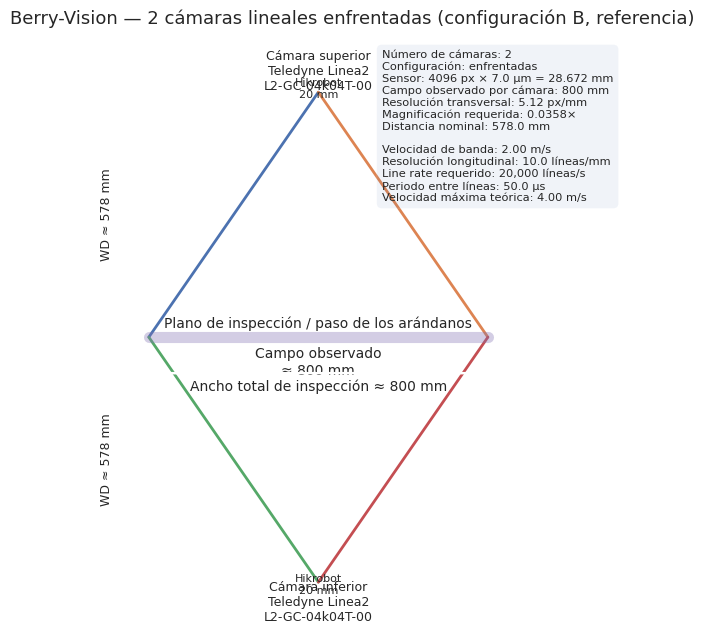

RESULTADOS DE DISEÑO
------------------------------------------------------
Número total de cámaras          : 2
Ancho total de inspección        : 800.0 mm
Ancho activo del sensor          : 28.672 mm
Resolución transversal           : 5.120 px/mm
Magnificación requerida          : 0.03584x
Distancia nominal por cámara     : 578.0 mm

Velocidad de banda               : 2.000 m/s
Line rate requerido              : 20,000 líneas/s
Periodo entre líneas             : 50.00 µs
Line rate máximo de cámara       : 40,000 líneas/s
Velocidad máxima a 10 líneas/mm  : 4.00 m/s

NOTA:
Con 800 mm por cámara la resolución transversal es 5.12 px/mm: el fruto de 14 mm ocupa ≈72 px (< 100 px del criterio B) y es la mitad de la resolución longitudinal (10 líneas/mm).
Esta configuración inspecciona ambas caras del fruto, pero no cumple el criterio de resolución; ver las configuraciones A y C en §5.1.


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================================================
# BERRY-VISION
# GEOMETRÍA DE 2 CÁMARAS ENFRENTADAS — CONFIGURACIÓN B (REFERENCIA)
# - 1 cámara arriba
# - 1 cámara abajo
# - ambas apuntándose una a la otra
# - ambas observan el mismo ancho de inspección
# =========================================================

# -----------------------------
# PARÁMETROS DEL SISTEMA
# -----------------------------

ANCHO_TOTAL_MM = 800.0

PIXELS_CAMARA = 4096
PIXEL_SIZE_UM = 7.0
FOCAL_MM = 20.0

# Teledyne Linea2 L2-GC-04k04T-00
LINE_RATE_MAX_HZ = 40000.0

# Requerimiento longitudinal
LINEAS_POR_MM = 10.0

# Velocidad de ejemplo
VELOCIDAD_BANDA_M_S = 2.0

# -----------------------------
# CÁLCULOS ÓPTICOS
# -----------------------------

sensor_mm = PIXELS_CAMARA * PIXEL_SIZE_UM / 1000.0

# Como solo hay 2 cámaras enfrentadas y ambas ven la misma zona,
# aquí se asume que cada cámara cubre todo el ancho de 800 mm
magnificacion = sensor_mm / ANCHO_TOTAL_MM

# Modelo de lente delgado:
# u = f * (1 + 1/m)
distancia_objeto_mm = FOCAL_MM * (1.0 + 1.0 / magnificacion)

# Resolución transversal real
px_por_mm = PIXELS_CAMARA / ANCHO_TOTAL_MM

# -----------------------------
# CÁLCULOS DE VELOCIDAD
# -----------------------------

velocidad_mm_s = VELOCIDAD_BANDA_M_S * 1000.0
line_rate_requerido = velocidad_mm_s * LINEAS_POR_MM
periodo_linea_us = 1e6 / line_rate_requerido
velocidad_max_m_s = LINE_RATE_MAX_HZ / (1000.0 * LINEAS_POR_MM)

# -----------------------------
# POSICIONES DEL DIBUJO
# -----------------------------

WD = distancia_objeto_mm

x_centro = 0.0
y_inspeccion = 0.0
y_cam_superior = -WD
y_cam_inferior = WD

cam_w = 105
cam_h = 48
lens_w = 55
lens_h = 22

# Figura más "skinny"
fig, ax = plt.subplots(figsize=(7, 10))

# =========================================================
# CÁMARA SUPERIOR
# =========================================================

ax.add_patch(Rectangle(
    (x_centro - cam_w/2, y_cam_superior - cam_h - 24),
    cam_w, cam_h,
    fill=False, linewidth=2
))

ax.text(
    x_centro, y_cam_superior - cam_h/2 - 24,
    "Cámara superior\nTeledyne Linea2\nL2-GC-04k04T-00",
    ha="center", va="center", fontsize=9
)

# Lente superior
ax.add_patch(Rectangle(
    (x_centro - lens_w/2, y_cam_superior - 18),
    lens_w, lens_h,
    fill=False, linewidth=2
))

ax.text(
    x_centro, y_cam_superior - 7,
    "Hikrobot\n20 mm",
    ha="center", va="center", fontsize=8
)

# Rayos / campo de visión superior
ax.plot([x_centro, -ANCHO_TOTAL_MM/2], [y_cam_superior, y_inspeccion], linewidth=2)
ax.plot([x_centro,  ANCHO_TOTAL_MM/2], [y_cam_superior, y_inspeccion], linewidth=2)

# Flecha dirección cámara superior
ax.annotate(
    "",
    xy=(x_centro, -60),
    xytext=(x_centro, y_cam_superior + 35),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# =========================================================
# CÁMARA INFERIOR
# =========================================================

ax.add_patch(Rectangle(
    (x_centro - cam_w/2, y_cam_inferior + 24),
    cam_w, cam_h,
    fill=False, linewidth=2
))

ax.text(
    x_centro, y_cam_inferior + cam_h/2 + 24,
    "Cámara inferior\nTeledyne Linea2\nL2-GC-04k04T-00",
    ha="center", va="center", fontsize=9
)

# Lente inferior
ax.add_patch(Rectangle(
    (x_centro - lens_w/2, y_cam_inferior - 4),
    lens_w, lens_h,
    fill=False, linewidth=2
))

ax.text(
    x_centro, y_cam_inferior + 7,
    "Hikrobot\n20 mm",
    ha="center", va="center", fontsize=8
)

# Rayos / campo de visión inferior
ax.plot([x_centro, -ANCHO_TOTAL_MM/2], [y_cam_inferior, y_inspeccion], linewidth=2)
ax.plot([x_centro,  ANCHO_TOTAL_MM/2], [y_cam_inferior, y_inspeccion], linewidth=2)

# Flecha dirección cámara inferior
ax.annotate(
    "",
    xy=(x_centro, 60),
    xytext=(x_centro, y_cam_inferior - 35),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

# =========================================================
# PLANO DE INSPECCIÓN
# =========================================================

ax.plot(
    [-ANCHO_TOTAL_MM/2, ANCHO_TOTAL_MM/2],
    [y_inspeccion, y_inspeccion],
    linewidth=8, alpha=0.35
)

ax.text(
    0, -14,
    "Plano de inspección / paso de los arándanos",
    ha="center", va="bottom", fontsize=10
)

# Etiqueta del campo
ax.text(
    0, 24,
    f"Campo observado\n≈ {ANCHO_TOTAL_MM:.0f} mm",
    ha="center", va="top", fontsize=10
)

# =========================================================
# DIMENSIÓN TOTAL
# =========================================================

y_dim = 85

ax.annotate(
    "",
    xy=(-ANCHO_TOTAL_MM/2, y_dim),
    xytext=(ANCHO_TOTAL_MM/2, y_dim),
    arrowprops=dict(arrowstyle="<->", linewidth=1.8)
)

ax.text(
    0, y_dim + 14,
    "Ancho total de inspección ≈ 800 mm",
    ha="center", va="top", fontsize=10
)

# =========================================================
# DISTANCIA DE TRABAJO
# =========================================================

x_dim = -470

# Superior
ax.annotate(
    "",
    xy=(x_dim, y_cam_superior),
    xytext=(x_dim, y_inspeccion),
    arrowprops=dict(arrowstyle="<->", linewidth=1.7)
)

ax.text(
    x_dim - 14, y_cam_superior / 2,
    f"WD ≈ {WD:.0f} mm",
    rotation=90, ha="right", va="center", fontsize=9
)

# Inferior
ax.annotate(
    "",
    xy=(x_dim, y_inspeccion),
    xytext=(x_dim, y_cam_inferior),
    arrowprops=dict(arrowstyle="<->", linewidth=1.7)
)

ax.text(
    x_dim - 14, y_cam_inferior / 2,
    f"WD ≈ {WD:.0f} mm",
    rotation=90, ha="right", va="center", fontsize=9
)

# =========================================================
# INFORMACIÓN DEL CÁLCULO
# =========================================================

info = (
    f"Número de cámaras: 2\n"
    f"Configuración: enfrentadas\n"
    f"Sensor: {PIXELS_CAMARA} px × {PIXEL_SIZE_UM:.1f} µm = {sensor_mm:.3f} mm\n"
    f"Campo observado por cámara: {ANCHO_TOTAL_MM:.0f} mm\n"
    f"Resolución transversal: {px_por_mm:.2f} px/mm\n"
    f"Magnificación requerida: {magnificacion:.4f}×\n"
    f"Distancia nominal: {WD:.1f} mm\n"
    f"\n"
    f"Velocidad de banda: {VELOCIDAD_BANDA_M_S:.2f} m/s\n"
    f"Resolución longitudinal: {LINEAS_POR_MM:.1f} líneas/mm\n"
    f"Line rate requerido: {line_rate_requerido:,.0f} líneas/s\n"
    f"Periodo entre líneas: {periodo_linea_us:.1f} µs\n"
    f"Velocidad máxima teórica: {velocidad_max_m_s:.2f} m/s"
)

ax.text(
    150, y_cam_superior - 100,
    info,
    ha="left", va="top", fontsize=8.2,
    bbox=dict(boxstyle="round,pad=0.45", alpha=0.08)
)

# =========================================================
# FORMATO
# =========================================================

ax.set_title(
    "Berry-Vision — 2 cámaras lineales enfrentadas (configuración B, referencia)",
    fontsize=13
)

ax.set_xlim(-560, 720)
ax.set_ylim(y_cam_superior - 140, y_cam_inferior + 120)

ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()   # eje invertido: la cámara superior queda arriba
ax.axis("off")

plt.show()

# =========================================================
# RESULTADOS NUMÉRICOS
# =========================================================

print("RESULTADOS DE DISEÑO")
print("------------------------------------------------------")
print(f"Número total de cámaras          : 2")
print(f"Ancho total de inspección        : {ANCHO_TOTAL_MM:.1f} mm")
print(f"Ancho activo del sensor          : {sensor_mm:.3f} mm")
print(f"Resolución transversal           : {px_por_mm:.3f} px/mm")
print(f"Magnificación requerida          : {magnificacion:.5f}x")
print(f"Distancia nominal por cámara     : {WD:.1f} mm")
print()
print(f"Velocidad de banda               : {VELOCIDAD_BANDA_M_S:.3f} m/s")
print(f"Line rate requerido              : {line_rate_requerido:,.0f} líneas/s")
print(f"Periodo entre líneas             : {periodo_linea_us:.2f} µs")
print(f"Line rate máximo de cámara       : {LINE_RATE_MAX_HZ:,.0f} líneas/s")
print(f"Velocidad máxima a 10 líneas/mm  : {velocidad_max_m_s:.2f} m/s")

print()
print("NOTA:")
print(f"Con {ANCHO_TOTAL_MM:.0f} mm por cámara la resolución transversal es {px_por_mm:.2f} px/mm: el fruto de {FRUTO_DIAM_MM:.0f} mm ocupa ≈{FRUTO_DIAM_MM*px_por_mm:.0f} px "
      f"(< {PX_FRUTO_NATIVO} px del criterio B) y es la mitad de la resolución longitudinal ({LINEAS_POR_MM:.0f} líneas/mm).")
print("Esta configuración inspecciona ambas caras del fruto, pero no cumple el criterio de resolución; ver las configuraciones A y C en §5.1.")

Cada decisión se evalúa con criterios ponderados (1–5; 5 = mejor). Las **puntuaciones son una propuesta del equipo** a validar con SOLID México y con cotizaciones; los pesos son editables y la elección se recalcula. El puntaje de ancho de banda de la interfaz de cámara no es una apreciación: se calcula con el margen real sobre los ≈246 MB/s que genera una cámara (§5.1).

In [54]:
def decidir(titulo, pesos, opciones):
    crit = list(pesos)
    df = pd.DataFrame(opciones)[crit]
    w = pd.Series(pesos) / sum(pesos.values())
    df["Puntaje"] = (df[crit] * w).sum(axis=1).round(2)
    df = df.sort_values("Puntaje", ascending=False)
    display(Markdown(f"**{titulo}** → **{df.index[0]}** ({df.iloc[0].Puntaje})"))
    display(df)
    return df.index[0]

d_computo = decidir("Plataforma de cómputo",
    {"Desempeño GPU": 5, "Robustez industrial": 4, "Costo": 3, "Facilidad de desarrollo": 4, "Escalabilidad": 3},
    {"Desempeño GPU": {"PC industrial + GPU dedicada": 5, "Módulo embebido (Jetson-class)": 3, "Laptop / equipo de escritorio (solo MVP)": 4},
     "Robustez industrial": {"PC industrial + GPU dedicada": 4, "Módulo embebido (Jetson-class)": 4, "Laptop / equipo de escritorio (solo MVP)": 1},
     "Costo": {"PC industrial + GPU dedicada": 2, "Módulo embebido (Jetson-class)": 4, "Laptop / equipo de escritorio (solo MVP)": 5},
     "Facilidad de desarrollo": {"PC industrial + GPU dedicada": 5, "Módulo embebido (Jetson-class)": 3, "Laptop / equipo de escritorio (solo MVP)": 5},
     "Escalabilidad": {"PC industrial + GPU dedicada": 4, "Módulo embebido (Jetson-class)": 3, "Laptop / equipo de escritorio (solo MVP)": 2}})

# Interfaz de cámara: el puntaje de ancho de banda sale del margen real sobre lo que genera una cámara (§5.1), no de una apreciación
mbs_if = {"GigE Vision": 115, "USB3 Vision": 350, "5GigE Vision": 550, "10GigE Vision": 1100, "CoaXPress": 1250}
sc_bw = lambda mbs: 1 if mbs < mbs_cam else (3 if mbs < 1.5 * mbs_cam else 5)    # <1×: no alcanza · <1.5×: justo · ≥1.5×: holgado
bw = {k: sc_bw(v) for k, v in mbs_if.items()}
print({k: f"{v/mbs_cam:.1f}× → {bw[k]}" for k, v in mbs_if.items()}, "(margen sobre una cámara de %.0f MB/s)" % mbs_cam)
d_cam = decidir("Interfaz de cámara",
    {"Ancho de banda": 5, "Longitud de cable": 3, "Costo": 3, "Soporte de disparo por hardware": 4, "Madurez": 3},
    {"Ancho de banda": bw,
     "Longitud de cable": {"GigE Vision": 5, "USB3 Vision": 2, "5GigE Vision": 4, "10GigE Vision": 4, "CoaXPress": 4},
     "Costo": {"GigE Vision": 5, "USB3 Vision": 5, "5GigE Vision": 4, "10GigE Vision": 3, "CoaXPress": 2},
     "Soporte de disparo por hardware": {"GigE Vision": 5, "USB3 Vision": 4, "5GigE Vision": 5, "10GigE Vision": 5, "CoaXPress": 5},
     "Madurez": {"GigE Vision": 5, "USB3 Vision": 4, "5GigE Vision": 4, "10GigE Vision": 4, "CoaXPress": 3}})

d_act = decidir("Actuador de separación",
    {"Tiempo de respuesta": 5, "Fragilidad del fruto": 5, "Mantenimiento": 3, "Costo": 3, "Precisión por fruto": 4},
    {"Tiempo de respuesta": {"Soplo neumático (electroválvula rápida)": 5, "Deflector mecánico": 3, "Brazo / paleta": 2},
     "Fragilidad del fruto": {"Soplo neumático (electroválvula rápida)": 5, "Deflector mecánico": 3, "Brazo / paleta": 2},
     "Mantenimiento": {"Soplo neumático (electroválvula rápida)": 4, "Deflector mecánico": 3, "Brazo / paleta": 2},
     "Costo": {"Soplo neumático (electroválvula rápida)": 3, "Deflector mecánico": 4, "Brazo / paleta": 3},
     "Precisión por fruto": {"Soplo neumático (electroválvula rápida)": 4, "Deflector mecánico": 2, "Brazo / paleta": 3}})

d_ilum = decidir("Iluminación",
    {"Uniformidad": 5, "Intensidad (exposición corta)": 5, "Vida útil": 3, "Costo": 3, "Estabilidad en el tiempo": 4},
    {"Uniformidad": {"Barra LED difusa + domo": 5, "Panel LED difuso (backlight/ring)": 4, "Foco LED directo": 1},
     "Intensidad (exposición corta)": {"Barra LED difusa + domo": 4, "Panel LED difuso (backlight/ring)": 4, "Foco LED directo": 5},
     "Vida útil": {"Barra LED difusa + domo": 5, "Panel LED difuso (backlight/ring)": 5, "Foco LED directo": 4},
     "Costo": {"Barra LED difusa + domo": 3, "Panel LED difuso (backlight/ring)": 4, "Foco LED directo": 5},
     "Estabilidad en el tiempo": {"Barra LED difusa + domo": 5, "Panel LED difuso (backlight/ring)": 5, "Foco LED directo": 3}})

**Plataforma de cómputo** → **PC industrial + GPU dedicada** (4.16)

,Desempeño GPU,Robustez industrial,Costo,Facilidad de desarrollo,Escalabilidad,Puntaje
PC industrial + GPU dedicada,5,4,2,5,4,4.16
Laptop / equipo de escritorio (solo MVP),4,1,5,5,2,3.42
Módulo embebido (Jetson-class),3,4,4,3,3,3.37


{'GigE Vision': '0.5× → 1', 'USB3 Vision': '1.4× → 3', '5GigE Vision': '2.2× → 5', '10GigE Vision': '4.5× → 5', 'CoaXPress': '5.1× → 5'} (margen sobre una cámara de 246 MB/s)


**Interfaz de cámara** → **5GigE Vision** (4.5)

,Ancho de banda,Longitud de cable,Costo,Soporte de disparo por hardware,Madurez,Puntaje
5GigE Vision,5,4,4,5,4,4.50
10GigE Vision,5,4,3,5,4,4.33
CoaXPress,5,4,2,5,3,4.00
GigE Vision,1,5,5,5,5,3.89
USB3 Vision,3,2,5,4,4,3.56


**Actuador de separación** → **Soplo neumático (electroválvula rápida)** (4.35)

,Tiempo de respuesta,Fragilidad del fruto,Mantenimiento,Costo,Precisión por fruto,Puntaje
Soplo neumático (electroválvula rápida),5,5,4,3,4,4.35
Deflector mecánico,3,3,3,4,2,2.95
Brazo / paleta,2,2,2,3,3,2.35


**Iluminación** → **Barra LED difusa + domo** (4.45)

,Uniformidad,Intensidad (exposición corta),Vida útil,Costo,Estabilidad en el tiempo,Puntaje
Barra LED difusa + domo,5,4,5,3,5,4.45
Panel LED difuso (backlight/ring),4,4,5,4,5,4.35
Foco LED directo,1,5,4,5,3,3.45


In [55]:
# Módulo de salidas: comparación cualitativa (sin puntaje: la decisión depende del determinismo que exija la ventana de actuación)
d_daq = "Advantech USB-5856 (MVP)"
daq = pd.DataFrame([
    ["Advantech USB-5856 (propuesto para el MVP)", f"{USB_SALIDAS} aisladas por módulo → {n_usb} módulos para {n_canales} canales", "Bajo: comando USB + sistema operativo; los eventos se programan con anticipación", "Salida sinking: requiere relevadores de estado sólido o drivers para 24 V", "Bajo", "API directa desde Python"],
    ["Chasis NI con módulos de salida (p. ej. NI-9474 para la iluminación)", "8 por módulo → 5 módulos para 40 canales", "Alto: temporización por hardware", "NI-9474: sourcing 5–30 V, compatible con 24 V", "Alto", "API nidaqmx (Python)"],
    ["PLC compacto con salidas rápidas (referencia industrial)", "Según modelo", "Alto: ciclo de control determinista", "Salidas 24 V nativas", "Medio", "OPC UA / Modbus TCP"],
], columns=["Opción", "Canales", "Determinismo de la salida", "Interfaz con electroválvula 24 V", "Costo relativo", "Integración con el software"])
display(daq)
print(f"La ventana de actuación es de {ventana_ms:.1f} ms (§5.4): el MVP puede arrancar con USB-5856 si los eventos se anticipan, pero un sistema industrial debería migrar a salidas con temporización por hardware.")

,Opción,Canales,Determinismo de la salida,Interfaz con electroválvula 24 V,Costo relativo,Integración con el software
0,Advantech USB-5856 (propuesto para el MVP),32 aisladas por módulo → 2 módulos para 40 canales,Bajo: comando USB + sistema operativo; los eventos se programan con anticipación,Salida sinking: requiere relevadores de estado sólido o drivers para 24 V,Bajo,API directa desde Python
1,Chasis NI con módulos de salida (p. ej. NI-9474 para la iluminación),8 por módulo → 5 módulos para 40 canales,Alto: temporización por hardware,"NI-9474: sourcing 5–30 V, compatible con 24 V",Alto,API nidaqmx (Python)
2,PLC compacto con salidas rápidas (referencia industrial),Según modelo,Alto: ciclo de control determinista,Salidas 24 V nativas,Medio,OPC UA / Modbus TCP


La ventana de actuación es de 4.5 ms (§5.4): el MVP puede arrancar con USB-5856 si los eventos se anticipan, pero un sistema industrial debería migrar a salidas con temporización por hardware.


**Lista preliminar de componentes dimensionados (BOM conceptual)**

In [56]:
bom = pd.DataFrame([
 ["Cámaras lineales", f"{CONFIGS.loc[CONFIG_ELEGIDA,'cámaras']:.0f} × Teledyne DALSA Linea2 L2-GC-04k04T-00 ({CONFIG_ELEGIDA})", f"{PIXELS_CAMARA} px, {PIXEL_UM:.0f} µm, 5GigE; {CONFIGS.loc[CONFIG_ELEGIDA,'px/mm transversal']:.2f} px/mm; line rate {line_rate/1000:.0f} kHz de {LINE_RATE_MAX_HZ/1000:.0f} kHz; ≈{mbs_cam:.0f} MB/s por cámara", "Defecto mínimo, fruto nativo, velocidad"],
 ["Lente", "Hikrobot MVL-AF2045M-M42 (20 mm, M42)", f"Magnificación ≈{CONFIGS.loc[CONFIG_ELEGIDA,'magnificación']:.3f}×; distancia de trabajo ≈{CONFIGS.loc[CONFIG_ELEGIDA,'distancia de trabajo (mm)']:.0f} mm", "FOV por cámara y tamaño del sensor"],
 ["Iluminación", f"{d_ilum}; propuesta concreta: Metaphase Exolight ISO2 RGBWIR850 con driver Fast Trigger (alternativa: Smart Vision Lights LXE300)", f"Trigger hasta ≈300 kHz frente a {line_rate/1000:.0f} kHz; exposición ≤ {t_exp_max_us:.0f} µs; uniformidad ≥ 90%", f"Uniformidad medida en la foto de banda: {uniformidad*100:.0f}%" if HAS_IMG else "Medir en la imagen real"],
 ["Control de iluminación", "NI-9474 (8 salidas sourcing, ~1 µs)", "Disparo sincronizado con la línea; temporización por hardware", "Periodo entre líneas"],
 ["Cómputo", d_computo, f"Segmentación/preproceso y CNN en núcleos distintos; bloque de {BLOQUE_LINEAS} líneas; GPU para {FRUTOS_POR_S:.0f} recortes/s (pico {FRUTOS_POR_BLOQUE_PICO} por bloque)", "Tasa de frutos y tiempo de inferencia"],
 ["Interfaz de cámara", d_cam, f"Un enlace por cámara ({mbs_cam:.0f} MB/s de {MBS_5GIGE:.0f} MB/s útiles)", "Ancho de banda por cámara"],
 ["Salidas de rechazo", f"{d_daq}", f"{n_usb} módulos ({n_usb*USB_SALIDAS} salidas) para {n_canales} canales + interfaz 24 V (relevadores de estado sólido, porque el USB-5856 es sinking)", "Canales de eyección"],
 ["Electroválvulas", f"{n_canales} × Matrix 821 ISD POX821.1E0C2YY (24 VDC, NC)", f"Apertura < {T_VALVULA_MS:.0f} ms, hasta 300 Hz, 2–8 bar; instaladas lo más cerca posible de la boquilla", "Ventana de actuación"],
 ["Encoder", "Incremental A/B; dispositivo de lectura por definir", "Referencia de posición y de line trigger", "Resolución longitudinal"],
 ["HMI", "Advantech SPC-821(M) V2 (21.5\", Full HD, multitáctil)", "Operación, configuración, estado y alarmas; fuera del lazo crítico", "§11"],
 ["Datos", "Memoria compartida (tiempo real) + SQLite (parámetros, eventos, estadísticas)", "SQLite no se usa como canal de tiempo real", "§3"],
 ["Sensores auxiliares", "Presostato neumático, sensores de presencia, paro de emergencia", "Alarmas y seguridad", "§12"],
], columns=["Componente", "Selección / tipo", "Especificación dimensionada", "Parámetro que la fija"])
display(bom)

,Componente,Selección / tipo,Especificación dimensionada,Parámetro que la fija
0,Cámaras lineales,"2 × Teledyne DALSA Linea2 L2-GC-04k04T-00 (A: 2 cámaras, una por mitad)","4096 px, 7 µm, 5GigE; 10.24 px/mm; line rate 20 kHz de 40 kHz; ≈246 MB/s por cámara","Defecto mínimo, fruto nativo, velocidad"
1,Lente,"Hikrobot MVL-AF2045M-M42 (20 mm, M42)",Magnificación ≈0.072×; distancia de trabajo ≈299 mm,FOV por cámara y tamaño del sensor
2,Iluminación,Barra LED difusa + domo; propuesta concreta: Metaphase Exolight ISO2 RGBWIR850 con dri...,Trigger hasta ≈300 kHz frente a 20 kHz; exposición ≤ 25 µs; uniformidad ≥ 90%,Uniformidad medida en la foto de banda: 87%
3,Control de iluminación,"NI-9474 (8 salidas sourcing, ~1 µs)",Disparo sincronizado con la línea; temporización por hardware,Periodo entre líneas
4,Cómputo,PC industrial + GPU dedicada,Segmentación/preproceso y CNN en núcleos distintos; bloque de 256 líneas; GPU para 69 ...,Tasa de frutos y tiempo de inferencia
5,Interfaz de cámara,5GigE Vision,Un enlace por cámara (246 MB/s de 550 MB/s útiles),Ancho de banda por cámara
6,Salidas de rechazo,Advantech USB-5856 (MVP),"2 módulos (64 salidas) para 40 canales + interfaz 24 V (relevadores de estado sólido, ...",Canales de eyección
7,Electroválvulas,"40 × Matrix 821 ISD POX821.1E0C2YY (24 VDC, NC)","Apertura < 2 ms, hasta 300 Hz, 2–8 bar; instaladas lo más cerca posible de la boquilla",Ventana de actuación
8,Encoder,Incremental A/B; dispositivo de lectura por definir,Referencia de posición y de line trigger,Resolución longitudinal
9,HMI,"Advantech SPC-821(M) V2 (21.5"", Full HD, multitáctil)","Operación, configuración, estado y alarmas; fuera del lazo crítico",§11


## 10. Comunicaciones y E/S

In [57]:
com = pd.DataFrame([
 ["Cámaras → PC", d_cam, "Líneas de imagen (bloques)", f"≈{mbs_cam:.0f} MB/s por cámara", "Un enlace dedicado por cámara"],
 ["DAQ → Cámaras / Iluminación", "Salida digital con temporización por hardware (NI-9474)", "Line trigger y strobe", "hasta ≈20 kHz", "Sincronización por hardware, sin depender de Windows"],
 ["Adquisición C++ → Python", "Memoria compartida", "Bloques de imagen", "≈80 bloques/s por cámara", "Concatena bloques y conserva el fruto incompleto"],
 ["Procesos internos del PC", "Memoria compartida / buffer circular", "Recortes, posiciones, resultados, acciones", "alta velocidad", "Desacopla visión y actuación"],
 ["HMI ↔ PC", "SQLite", "Parámetros, estados y comandos", "baja frecuencia", "Main detecta los cambios"],
 ["actions → DAQ", "API Advantech / NI", "Máscaras binarias de salida", "ms", f"{n_canales} canales; eventos programados con anticipación"],
 ["DAQ → Electroválvulas", "Salidas digitales (interfaz 24 V)", "Pulso por canal", "ms", f"{n_canales} canales"],
 ["PC → BD / HMI", "SQL", "Resultados, eventos y trazabilidad", "1–5 Hz", "Información no crítica"],
], columns=["Enlace", "Medio / protocolo", "Contenido", "Orden de magnitud", "Notas de diseño"])
display(com)

io = pd.DataFrame([
 ["Entradas digitales", "Encoder A/B (posición y line trigger)", 2],
 ["Entradas digitales", "Sensores de presencia / estado", 2],
 ["Entradas digitales", "Paro / seguridad / alarmas", 4],
 ["Entradas digitales", "Estado de presión neumática", 1],
 ["Salidas digitales", "Electroválvulas de eyección", n_canales],
 ["Salidas digitales", "Iluminación (enable / strobe) y line trigger", 2],
 ["Salidas digitales", "Baliza / señales auxiliares", 2]
], columns=["Tipo", "Señal", "Cantidad"])
display(io.groupby("Tipo").Cantidad.sum().to_frame("Total de canales"))
display(io)

,Enlace,Medio / protocolo,Contenido,Orden de magnitud,Notas de diseño
0,Cámaras → PC,5GigE Vision,Líneas de imagen (bloques),≈246 MB/s por cámara,Un enlace dedicado por cámara
1,DAQ → Cámaras / Iluminación,Salida digital con temporización por hardware (NI-9474),Line trigger y strobe,hasta ≈20 kHz,"Sincronización por hardware, sin depender de Windows"
2,Adquisición C++ → Python,Memoria compartida,Bloques de imagen,≈80 bloques/s por cámara,Concatena bloques y conserva el fruto incompleto
3,Procesos internos del PC,Memoria compartida / buffer circular,"Recortes, posiciones, resultados, acciones",alta velocidad,Desacopla visión y actuación
4,HMI ↔ PC,SQLite,"Parámetros, estados y comandos",baja frecuencia,Main detecta los cambios
5,actions → DAQ,API Advantech / NI,Máscaras binarias de salida,ms,40 canales; eventos programados con anticipación
6,DAQ → Electroválvulas,Salidas digitales (interfaz 24 V),Pulso por canal,ms,40 canales
7,PC → BD / HMI,SQL,"Resultados, eventos y trazabilidad",1–5 Hz,Información no crítica


,Total de canales
Tipo,
Entradas digitales,9
Salidas digitales,44


,Tipo,Señal,Cantidad
0,Entradas digitales,Encoder A/B (posición y line trigger),2
1,Entradas digitales,Sensores de presencia / estado,2
2,Entradas digitales,Paro / seguridad / alarmas,4
3,Entradas digitales,Estado de presión neumática,1
4,Salidas digitales,Electroválvulas de eyección,40
5,Salidas digitales,Iluminación (enable / strobe) y line trigger,2
6,Salidas digitales,Baliza / señales auxiliares,2


### Inputs / Outputs

La máquina deberá contar principalmente con dos grupos de salidas: **control de iluminación** y **control de electroválvulas de rechazo**.

#### Iluminación

La iluminación deberá controlarse de forma sincronizada con la adquisición de la cámara lineal. La intención es utilizar una salida digital para habilitar, encender o disparar el sistema de iluminación durante el periodo de captura.

Dependiendo del sistema seleccionado, esta salida podrá funcionar como señal de **enable** o como señal de **strobe**, de manera que la iluminación entregue la intensidad necesaria durante tiempos de exposición cortos y ayude a reducir el desenfoque de los arándanos durante la caída libre.

El control final dependerá del modelo de iluminación seleccionado y de las características de su controlador.

#### Electroválvulas de rechazo

Las principales salidas digitales estarán destinadas al control de las **electroválvulas neumáticas** encargadas de rechazar los arándanos defectuosos.

Después de que la red neuronal clasifique un arándano como malo, el sistema deberá utilizar su posición para determinar qué canal de eyección corresponde. Esta información se convertirá en una orden digital que deberá mantenerse en memoria hasta el momento correcto de actuación.

Cuando el fruto llegue a la zona de rechazo, la computadora deberá enviar la señal correspondiente a una tarjeta de adquisición de datos **Advantech o NI**. La tarjeta activará la salida digital asociada a la electroválvula correspondiente.

Cada electroválvula controlará un pulso de aire que deberá desviar únicamente al arándano defectuoso, mientras los frutos clasificados como buenos continuarán su trayectoria normal.

La cantidad de salidas dependerá del número final de canales de eyección. La arquitectura propuesta deberá permitir agrupar las salidas en palabras binarias para transmitir y ejecutar varias señales de manera eficiente.

El flujo propuesto será:

**CNN → posición del fruto → cálculo de acción → memoria compartida → control de salidas → tarjeta NI/Advantech → electroválvula → pulso de aire**

Para la iluminación:

**Main / adquisición → señal de sincronización → controlador de iluminación → iluminación de la zona de captura**

El objetivo es que ambas salidas trabajen con tiempos de respuesta suficientemente cortos para mantener sincronizada la captura de imagen con la posición física de cada arándano y ejecutar el rechazo antes de que el fruto abandone la zona de actuación.

## 11. Interfaces HMI (wireframes)


Tres perfiles: **operador** (arranque/paro, contadores, alarmas), **ingeniería** (umbrales, calibración, diagnóstico) y **dashboard web de monitoreo** (el entregable del MVP).

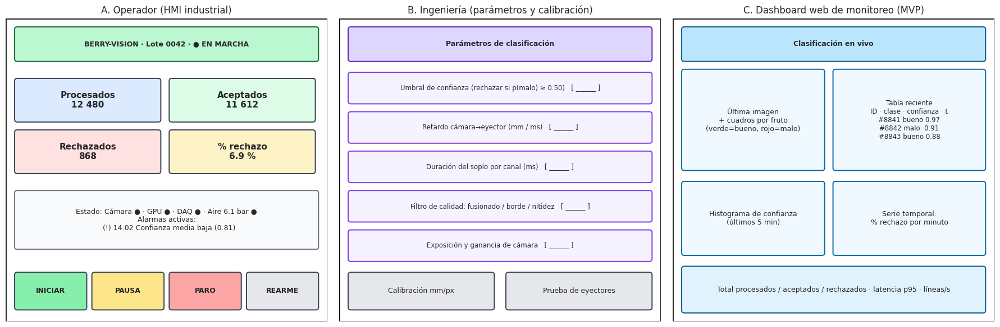

In [58]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax in axs: ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off"); ax.add_patch(Rectangle((0, 0), 10, 10, fc="white", ec="#111", lw=2))

ax = axs[0]; ax.set_title("A. Operador (HMI industrial)")
box(ax, .3, 8.6, 9.4, 1.1, "BERRY-VISION · Lote 0042 · ● EN MARCHA", "#bbf7d0", "#166534", bold=True)
for i, (n, v, c) in enumerate([("Procesados", "12 480", "#dbeafe"), ("Aceptados", "11 612", "#dcfce7"), ("Rechazados", "868", "#fee2e2"), ("% rechazo", "6.9 %", "#fef3c7")]):
    box(ax, .3 + (i % 2) * 4.8, 6.6 - (i // 2) * 1.7, 4.5, 1.4, f"{n}\n{v}", c, "#374151", fs=11, bold=True)
box(ax, .3, 2.4, 9.4, 1.9, "Estado: Cámara ● · GPU ● · DAQ ● · Aire 6.1 bar ●\nAlarmas activas:\n  (!) 14:02 Confianza media baja (0.81)", "#f9fafb", "#6b7280", fs=9)
for i, t_ in enumerate(["INICIAR", "PAUSA", "PARO", "REARME"]): box(ax, .3 + i * 2.4, .4, 2.2, 1.2, t_, ["#86efac", "#fde68a", "#fca5a5", "#e5e7eb"][i], "#374151", bold=True)

ax = axs[1]; ax.set_title("B. Ingeniería (parámetros y calibración)")
box(ax, .3, 8.6, 9.4, 1.1, "Parámetros de clasificación", "#ddd6fe", "#5b21b6", bold=True)
for i, t_ in enumerate(["Umbral de confianza (rechazar si p(malo) ≥ 0.50)", "Retardo cámara→eyector (mm / ms)", "Duración del soplo por canal (ms)", "Filtro de calidad: fusionado / borde / nitidez", "Exposición y ganancia de cámara"]):
    box(ax, .3, 7.2 - i * 1.3, 9.4, 1.0, f"{t_}   [ ______ ]", "#f5f3ff", "#7c3aed", fs=8.5)
box(ax, .3, .4, 4.5, 1.2, "Calibración mm/px", "#e5e7eb", "#374151"); box(ax, 5.2, .4, 4.5, 1.2, "Prueba de eyectores", "#e5e7eb", "#374151")

ax = axs[2]; ax.set_title("C. Dashboard web de monitoreo (MVP)")
box(ax, .3, 8.6, 9.4, 1.1, "Clasificación en vivo", "#bae6fd", "#075985", bold=True)
box(ax, .3, 5.0, 4.4, 3.3, "Última imagen\n+ cuadros por fruto\n(verde=bueno, rojo=malo)", "#f0f9ff", "#0369a1", fs=9)
box(ax, 5.0, 5.0, 4.7, 3.3, "Tabla reciente\nID · clase · confianza · t\n#8841 bueno 0.97\n#8842 malo  0.91\n#8843 bueno 0.88", "#f0f9ff", "#0369a1", fs=8.5)
box(ax, .3, 2.2, 4.4, 2.4, "Histograma de confianza\n(últimos 5 min)", "#f0f9ff", "#0369a1", fs=9); box(ax, 5.0, 2.2, 4.7, 2.4, "Serie temporal:\n% rechazo por minuto", "#f0f9ff", "#0369a1", fs=9)
box(ax, .3, .3, 9.4, 1.5, "Total procesados / aceptados / rechazados · latencia p95 · líneas/s", "#e0f2fe", "#075985", fs=9)
plt.tight_layout(); plt.show()

## 12. Manejo de errores, seguridad, trazabilidad, escalabilidad y riesgos


**Política fail-safe:** ante cualquier incertidumbre se **rechaza** el fruto (el costo de dejar pasar uno defectuoso es mayor que el de rechazar uno bueno) y, si la falla es del sistema y no del fruto, la máquina pasa a un estado seguro.

### Manejo de fallas y acciones fail-safe

| Falla | Detección | Acción (fail-safe) | Registro / alarma |
|---|---|---|---|
| Bloque de líneas perdido o corrupto | Contador de líneas / checksum | El fruto afectado se rechaza si no se recupera; el traslape entre bloques cubre los frutos en el límite | Alarma si >1% en 1 min |
| Fruto fusionado / cortado / pequeño | Reglas de calidad del recorte (§4.7) | Se espera al siguiente bloque; si nunca se obtiene un recorte válido → **RECHAZAR** | Registro con motivo |
| Latencia mayor que el tiempo disponible (≈45 ms) | Latencia p95 por bloque frente al tiempo disponible (§7) | Descartar bloques atrasados y **RECHAZAR** los frutos sin resultado a tiempo | Alarma y degradación controlada |
| Baja confianza del modelo | Confianza < umbral configurable | **RECHAZAR** (política conservadora) | Contador por lote |
| Pérdida de comunicación con el módulo de salidas (DAQ) | Error de la API y heartbeat del proceso `actions`, supervisado por Main | Electroválvulas normalmente cerradas: sin señal no soplan; se detiene la alimentación y se avisa al operador | Alarma crítica |
| Falla de cámara o iluminación | Histograma de brillo fuera de rango / ausencia de líneas | Paro controlado de la línea | Alarma crítica |
| Presión neumática baja | Presostato | Paro de alimentación; no se confía en la eyección | Alarma crítica |
| Atasco o desalineación mecánica | Fotocelda / conteo inconsistente | Paro y aviso al operador | Alarma |
| Deriva de iluminación / modelo | Brillo de fondo y distribución de confianza vs. línea base | Recalibración y reentrenamiento según CRISP-ML(Q) | Tendencia en dashboard |

### Seguridad, confidencialidad y trazabilidad

| Ámbito | Medida | Referencia |
|---|---|---|
| Seguridad funcional | Paro de emergencia en circuito cableado independiente del PC; guardas con interruptor de seguridad; rearme manual | Normatividad aplicable de seguridad de maquinaria, a definir por SOLID |
| Higiene / inocuidad | Materiales aptos para contacto con fruta fresca en banda y eyectores; iluminación sin vidrio expuesto | Requerimientos de la planta empacadora |
| Ciberseguridad | Red de control aislada de la red corporativa; cuentas por rol en HMI/dashboard; sin credenciales en el repositorio | Buenas prácticas OT/IT |
| Confidencialidad | Imágenes y criterios de calidad de SOLID no se publican; solo código, documentación y resultados agregados | Convenio firmado (Avance 0, Anexo A) |

### Registro de trazabilidad por fruto

| Campo | Ejemplo |
|---|---|
| id_fruto | L0042-000123 |
| lote | L0042 |
| t_captura | 2026-10-04T10:15:32.412 |
| bloque_id | 8841 |
| x_mm | 212.4 |
| y_mm | 31.0 |
| diametro_mm | 14.2 |
| clase | 1 |
| confianza | 0.91 |
| modelo | mobilenetv2_v0.3 |
| t_inferencia_ms | 2.1 |
| decision | rechazar |
| canal_eyector | 12 |
| t_eyeccion | 2026-10-04T10:15:32.790 |
| motivo_rechazo | clase=malo |
| ruta_imagen | auditoria/L0042/8841_123.png |

### Escalabilidad de la arquitectura

| Necesidad | Cómo escala la arquitectura | Evidencia / cifra |
|---|---|---|
| Más producción | Más carriles por banda o cámaras en paralelo; más GPU y procesamiento por lotes | La capacidad aumenta aproximadamente de forma proporcional al número de carriles, cámaras y eyectores |
| Más ancho de banda | Más cámaras con solape de FOV y unificación de coordenadas | Cada cámara cubre una sección del ancho total; los eyectores mantienen su separación definida |
| Más defectos (Fase 2) | Cabezal multietiqueta y segmentación sobre los mismos recortes; incorporación de canal NIR | Se reutilizan adquisición, tracking y comunicaciones; cambia principalmente la etapa de inferencia |
| Nuevos criterios de calidad | Umbrales configurables en HMI por categoría de defecto | Permite modificar criterios sin modificar el software de salidas |
| Nuevas variedades / temporadas | Reentrenamiento utilizando el flujo de auditoría de imágenes | Pipeline de datos y modelos versionado mediante MLOps |
| Mantenimiento remoto | Telemetría y registro centralizado | Integración mediante API del servicio de inferencia |

### Matriz de riesgos

| Riesgo | Probabilidad | Impacto | Mitigación | Métrica de verificación (CRISP-ML(Q)) |
|---|---|---|---|---|
| Resolución insuficiente para el defecto mínimo | Alta | Alto | Dimensionar la cámara con la resolución espacial requerida y validar con defectos reales | mm/px medido; recall por defecto |
| Desenfoque de movimiento | Media | Alto | Exposición corta e iluminación estroboscópica | Nitidez mediante varianza del Laplaciano ≥ umbral |
| Frutos pegados / cobertura alta | Alta | Medio | Banda con guías (~2 cm); rechazo de fusionados; traslape entre bloques | % de frutos fusionados ≤ objetivo |
| Latencia mayor que el tiempo disponible (≈45 ms entre captura y rechazo) | Alta | Alto | Bloques cortos (32–128 líneas con pocos frutos pico), pipeline en núcleos distintos, inferencia por lotes optimizada o mayor altura de caída | Latencia total ≤ 45.4 ms (estimada hoy en ≈80 ms con margen y bloques de 256 líneas, §7) |
| Jitter del comando USB y del sistema operativo frente a la ventana de actuación (≈4.5 ms) | Alta | Alto | Eventos programados con anticipación; temporización por hardware (NI) si es necesario | Error del instante de rechazo ≪ 2 ms |
| Deriva de iluminación entre sesiones | Media | Medio | Iluminación controlada y monitoreo continuo del brillo del fondo | Variación de brillo entre sesiones |
| Etiquetado subjetivo / dataset pequeño | Alta | Alto | Criterio documentado con SOLID; transfer learning; aumento de datos | Acuerdo entre etiquetadores; curva de aprendizaje |
| Pérdida de comunicación con el DAQ | Baja | Alto | Heartbeat de `actions`, válvulas normalmente cerradas y paro de alimentación | Tiempo de detección < 100 ms |
| Brecha de dominio entre dataset de celular y cámara industrial | Alta | Alto | Estudio de degradación de resolución y captura con cámara e iluminación finales antes del entrenamiento definitivo | Desempeño estable al reducir la resolución por fruto |
| Dataset sin clasificar y desbalance sin medir | Alta | Alto | Plantilla de etiquetado; criterio acordado con SOLID; pesos de clase y métricas por clase | Número de recortes etiquetados; acuerdo entre etiquetadores |
| Mismo fruto en varias fotos (fuga de datos) | Media | Alto | Partición por foto; revisión de casi-duplicados; confirmar si se repiten frutos | Pares casi-duplicados entre particiones = 0 |
| Extractor con parámetros fijos ajustados a fotos macro | Media | Medio | Parametrizar según resolución y utilizar la cadena de procesamiento de banda en la máquina | Frutos útiles recuperados / frutos reales |
| Salida sinking del USB-5856 incompatible con electroválvulas de 24 V | Media | Medio | Relevadores de estado sólido o drivers intermedios, o un módulo sourcing | Pruebas de conmutación en banco |
| Resolución transversal insuficiente si cada cámara cubre 800 mm (≈72 px por fruto) | Media | Alto | Configuración A o C, con cámaras de 400 mm de campo | Píxeles por fruto ≥ 100 |

## 13. Conclusiones

### Condiciones de diseño y resultados

- **Arquitectura.** Banda con guías (~2 cm), caída libre, dos cámaras lineales 4k (configuración A), PC *soft real-time* con procesos asíncronos coordinados por Main (memoria compartida y SQLite), módulos de salida USB-5856 y 40 electroválvulas; la HMI queda fuera del lazo crítico. El MVP cubre captura, preprocesamiento, inferencia, registro y dashboard; SOLID México aporta la parte mecánica y de actuación.

- **Resolución.** Para que el defecto de 1 mm abarque 4 px y el recorte de 200×200 no se amplíe se requieren al menos 7.1 px/mm. Con 400 mm por cámara la Linea2 4k da 10.24 px/mm (fruto de ≈143 px) y 10 líneas/mm. La configuración con cámaras enfrentadas de 800 mm cada una da 5.12 px/mm (≈72 px por fruto) y no cumple.

- **Exposición e iluminación.** A 2 m/s el periodo entre líneas es de 50 µs y el fruto avanza 0.1 mm por línea; para mantener el desenfoque en 0.5 línea o menos la exposición debe ser de 25 µs o menos, lo que exige iluminación intensa con trigger rápido (el driver Fast Trigger admite ≈300 kHz frente a 20 kHz).

- **Interfaz de cámara.** Cada cámara genera ≈246 MB/s en RGB; 5GigE (≈550 MB/s útiles) la soporta con ≈45% de uso, con un enlace por cámara. GigE no alcanza y la matriz de decisión favorece 5GigE.

- **Latencia y geometría.** Entre la captura (20 cm de caída) y el rechazo (30 cm) hay 45.4 ms. La latencia estimada es de ≈64 ms (≈80 ms con margen de 25%) con bloques de 256 líneas y 10 frutos simultáneos, por lo que **con la geometría y los supuestos actuales el sistema no cumple**. Cumpliría con bloques de 32 a 128 líneas y 1–3 frutos simultáneos (o de 32 a 64 líneas con 5), o elevando el punto de rechazo a ≈39 cm de caída.

- **Actuación.** Se requieren 40 canales (2 módulos USB-5856). La ventana de actuación por fruto es de ≈4.5 ms, comparable con la apertura de la válvula (2 ms) más el aire (2 ms) y menor que el jitter supuesto del USB y el sistema operativo (5 ms); por eso los eventos se programan con anticipación y la salida fina debería migrar a temporización por hardware.

- **Cómputo.** 69 frutos/s a 1000 kg/h; una GPU a 2 ms por recorte rinde ≈500 recortes/s. El preprocesamiento (≈11 ms por bloque) y la inferencia en el caso pico (20 ms) exceden el periodo del bloque (12.8 ms) en un solo hilo, por lo que se requiere un pipeline en núcleos distintos.

- **Dataset real.** 161 fotografías originales y 480 recortes individuales normalizados a **200×200 px**; 33 recortes excluidos por calidad, 447 utilizables y 410 con etiqueta (239 buenos y 171 malos, 1.4:1). Los objetos que no cumplen los criterios de calidad se excluyen del entrenamiento. La clase binaria tiene 2 valores; los defectos tienen 8 categorías y dos de ellas (`descompuesto`, 5 recortes, e `inmaduro`, 1) tienen menos de 10 recortes, por lo que se agruparían en «otros» para el modelo de la Fase 2.

- **Estructura y deriva.** PCA y k-means exploraron la estructura interna sin etiquetas, y se analizó la variación asociada a la fotografía de origen para evitar que capturas de una misma foto queden en entrenamiento y validación a la vez. La verificación de §4.7 muestra que la proporción de frutos malos baja de 49% a 36% entre el primer y el último tercio de las capturas (chi-cuadrada p = 0.064, sin evidencia concluyente de dependencia) y que el AUC de la nitidez se mantiene dentro de cada periodo (0.58, 0.71 y 0.62), por lo que su relación con la clase no se explica solo por la sesión de captura.

- **Imagen real de la banda.** La segmentación identifica frutos utilizables, fusionados y cortados por el borde, y permite evaluar la iluminación de la zona de captura.

- **Componentes preliminares.** Cámaras Teledyne DALSA Linea2 L2-GC-04k04T-00 (×2) con lente Hikrobot 20 mm, iluminación Metaphase Exolight ISO2 con control NI-9474, PC con GPU, módulos Advantech USB-5856 (×2), electroválvulas Matrix 821 ISD y HMI Advantech SPC-821.

### Preguntas guía de la rúbrica, adaptadas a Berry-Vision

| Pregunta original | Adaptación y respuesta |
|---|---|
| ¿Hay valores faltantes? ¿Patrones de ausencia? | Fotos sin recorte, recortes huérfanos y objetos sin fruto válido (§4.2–4.4); bloques de líneas perdidos con política de manejo (§12). |
| ¿Estadísticas resumidas? | Tamaños de fotos y recortes, color, brillo, nitidez, geometría (§4.4), tiempos de CPU y tasas de datos (§2, §3 y §5). |
| ¿Hay valores atípicos? | Recortes muy pequeños, borrosos o sobreexpuestos se excluyen; los atípicos de color/forma se conservan (§4.7). En la banda: fusionados y cortados (§4.8). |
| ¿Cardinalidad de las categóricas? | Salida binaria (2 clases); 8 etiquetas de defecto en Fase 2; 40 canales de eyección (§5.4, §10). |
| ¿Distribuciones sesgadas / transformación no lineal? | Asimetría y curtosis por característica (§4.4–4.5); Yeo-Johnson para las sesgadas (§4.7). |
| ¿Tendencias temporales? | Orden de captura (IMG_####) como proxy temporal: deriva del fondo, brillo y nitidez (§4.6); monitoreo en operación (§12). |
| ¿Correlación entre variables? | Correlaciones, redundancia, PCA y agrupamiento del dataset (§4.6); relaciones entre parámetros de diseño (§6–7). Con etiquetas, característica ↔ clase (§4.7). |
| ¿Distribución por categorías? | Por foto de origen, grupos k-means y, por clase (§4.6–4.7). |
| ¿Normalizar imágenes para visualizarlas? | Recortes reducidos a 200×200 con `INTER_AREA`; normalización del fondo en la vista de banda (§4.7–4.8). |
| ¿Desequilibrio de clases? | 1.4:1 en los 410 recortes etiquetados (239 buenos y 171 malos): desbalance moderado. Se usan pesos de clase, métricas por clase (en particular el recall de *malo*), aumento solo en entrenamiento y partición estratificada por foto (§4.7); la política fail-safe rechaza ante incertidumbre. |

### Pendientes con SOLID México
1. Confirmar velocidad de banda (diseño: 2 m/s), producción objetivo (kg/h), ancho útil (800 mm) y separación de guías (~2 cm).
2. Confirmar el diámetro/peso de las variedades y el defecto más pequeño que debe detectarse.
3. Presión neumática disponible, interfaz eléctrica de las electroválvulas (24 V) y dispositivo de lectura del encoder.
4. Definir quién provee la cámara y la iluminación para el MVP y su resolución real.
5. Autorización para mostrar imágenes de ejemplo en la documentación (hoy se omiten por confidencialidad).
6. Criterio de etiquetado bueno/malo y plan para etiquetar los recortes (insumo del Avance 3); confirmar las proporciones de clases que conoce SOLID.
7. Confirmar si los mismos frutos aparecen en varias fotos y si las fotos son HEIC originales o procesadas ("enhanced").
8. Foto o video de la banda real con la cámara y la iluminación finales, para cerrar la brecha de dominio.
9. Decidir la configuración de cámaras (A, B o C; §5.1) y las alturas de captura y rechazo (hoy 20 y 30 cm), porque la latencia estimada excede los 45.4 ms disponibles (§7).

El desarrollo de este avance permitió caracterizar tanto el conjunto de datos disponible como las principales condiciones técnicas que deberán cumplirse para implementar Berry-Vision como un sistema de clasificación automática de arándanos. Los resultados muestran que el proyecto cuenta con una base de datos y una arquitectura conceptual suficientes para continuar hacia el entrenamiento y validación de modelos de visión artificial, aunque también se identificaron limitaciones importantes que deberán resolverse antes de considerar viable una implementación industrial en tiempo real.

En el análisis del dataset se procesaron 161 fotografías originales, a partir de las cuales se generaron 480 recortes individuales de arándanos. El control de calidad identificó 33 recortes con problemas de extracción o captura, principalmente objetos demasiado pequeños, imágenes borrosas o regiones que no representan adecuadamente un fruto completo. Después de este filtrado permanecen 447 recortes potencialmente utilizables, de los cuales 410 cuentan actualmente con una etiqueta de calidad. La distribución de estos datos etiquetados corresponde a 239 frutos buenos (58.3%) y 171 frutos malos (41.7%), equivalente a una relación aproximada de 1.4:1. Por lo tanto, existe un desbalance moderado, pero no suficientemente severo como para considerar que una de las dos clases se encuentra escasamente representada.

El análisis exploratorio mostró variaciones importantes en tamaño, color, brillo, nitidez y condiciones de captura. Las características extraídas no presentan valores faltantes, pero varias muestran distribuciones asimétricas y correlaciones elevadas entre sí, lo que confirma la existencia de información redundante. Adicionalmente, se observó un efecto considerable asociado a la fotografía de origen en variables como saturación, brillo, nitidez y tamaño. Esto indica que las condiciones particulares de cada captura pueden influir de forma importante en los datos, por lo que la separación entre entrenamiento, validación y prueba no debe realizarse aleatoriamente por recorte. La partición deberá mantenerse agrupada por fotografía o, idealmente, por fruto físico y sesión de adquisición cuando esta información esté disponible, evitando así fuga de información entre los conjuntos.

El análisis mediante PCA y k-means permitió identificar estructura interna en las características extraídas, obteniéndose una mejor solución con dos grupos y un coeficiente de silueta aproximado de 0.47. Sin embargo, estos grupos no deben interpretarse directamente como las categorías bueno y malo. El agrupamiento fue obtenido sin utilizar las etiquetas de calidad y puede estar capturando diferencias de iluminación, nitidez, tamaño o sesión de adquisición. Por esta razón, será necesario comparar posteriormente los grupos obtenidos con las etiquetas reales para determinar qué características explican la variabilidad observada.

El análisis supervisado preliminar refuerza esta observación. Entre las características individuales evaluadas, la nitidez presentó la mayor relación con la clase, con un AUC univariante aproximado de 0.64, mientras que las variables simples de color, tamaño, saturación y geometría mostraron capacidades de separación considerablemente menores. Esto sugiere que la clasificación bueno/malo depende de combinaciones más complejas de textura, forma y patrones espaciales que no pueden representarse adecuadamente mediante una sola característica estadística. En consecuencia, se justifica el uso de una red neuronal convolucional para aprender directamente estas características a partir de las imágenes. No obstante, la nitidez también depende de la sesión de captura (la foto de origen explica cerca de la mitad de su varianza), por lo que en §4.7 se incorporó una verificación que compara la clase por periodo de captura y recalcula el AUC dentro de cada periodo. El resultado es que la proporción de frutos malos baja de 49% a 36% entre el primer y el último tercio de las capturas (chi-cuadrada p = 0.064, sin evidencia concluyente de dependencia) y que el AUC de la nitidez se mantiene dentro de cada periodo (0.58, 0.71 y 0.62), de modo que su relación con la clase no se explica solo por la sesión de captura. Queda pendiente descartar que refleje diferencias de tamaño o de enfoque entre las fotos de frutos buenos y malos, porque la foto de origen sigue explicando buena parte de su varianza.

También se identificó una brecha importante entre las imágenes utilizadas para construir el dataset y las condiciones esperadas en la máquina. En las fotografías individuales el diámetro mediano del fruto es aproximadamente 728 píxeles, mientras que en la fotografía representativa de la banda el diámetro mediano de los frutos correctamente segmentados es cercano a 41 píxeles. Esta diferencia confirma la existencia de una brecha de dominio en resolución, iluminación, densidad de producto y condiciones ópticas. Por ello, antes de fijar definitivamente la resolución de la cámara industrial será necesario realizar un estudio de degradación de resolución y validar el modelo con imágenes adquiridas bajo condiciones similares a las de operación real.

La prueba de segmentación sobre la imagen de banda permitió detectar 153 objetos, de los cuales aproximadamente 59.5% fueron considerados utilizables, 28.1% se identificaron como frutos fusionados, 9.8% correspondieron a objetos en el borde y 2.6% a objetos demasiado pequeños. Estos resultados demuestran que la estrategia de normalización de fondo, segmentación y watershed es capaz de procesar imágenes con múltiples frutos, pero también muestran que la separación física del producto y las condiciones de adquisición tendrán un impacto directo en el desempeño del sistema. Una proporción de frutos fusionados cercana al 28% sería demasiado elevada para una operación industrial, por lo que la singularización mecánica y la mejora de la segmentación deberán desarrollarse conjuntamente. De manera similar, la uniformidad de iluminación medida fue de aproximadamente 86.7%, inferior al objetivo establecido de 90%, por lo que la iluminación todavía requiere optimización.

Desde el punto de vista de la arquitectura industrial, la memoria de cálculo confirma que la resolución espacial, el line rate, la exposición, la iluminación y la latencia son parámetros estrechamente relacionados. Sin embargo, el análisis también reveló una restricción crítica de tiempo. Con la fotografía localizada a 20 cm de caída y el rechazo a 30 cm, el fruto dispone de aproximadamente 45.4 ms entre la captura y la actuación. El presupuesto de latencia calculado en §7 (≈64 ms, y ≈80 ms con un margen de 25%, con bloques de 256 líneas y hasta 10 frutos simultáneos por bloque) es superior a ese intervalo, por lo que con la geometría y los supuestos actuales todavía no puede afirmarse que el sistema cumpla el requisito de operación en tiempo real. El análisis de sensibilidad muestra que se cumpliría con bloques de 32 a 128 líneas y 1 a 3 frutos simultáneos por bloque (o de 32 a 64 líneas con 5), o elevando el punto de rechazo a ≈39 cm de caída. Además, la ventana de actuación por fruto es de apenas ≈4.5 ms, por lo que el jitter del comando USB y del sistema operativo debe controlarse con eventos programados con anticipación o con temporización por hardware.

Por lo tanto, el principal resultado de este avance no es únicamente la selección preliminar de componentes, sino la identificación cuantitativa de los factores que limitan el sistema. El dataset presenta información suficiente para iniciar el modelado supervisado; la distribución de clases es razonablemente balanceada; las características simples no parecen suficientes para resolver por sí mismas la clasificación; y la segmentación sobre la banda demuestra la viabilidad del concepto, aunque todavía requiere mejorar la separación de frutos y la iluminación. Al mismo tiempo, la restricción de latencia demuestra que la arquitectura física, el sistema de adquisición y el procesamiento de visión deben diseñarse como un único sistema integrado.

Como siguiente etapa se deberá consolidar y revisar el etiquetado, definir una partición agrupada y estratificada de entrenamiento, validación y prueba, entrenar un primer modelo CNN binario y evaluar su desempeño mediante métricas como precisión, recall, F1, matriz de confusión y, particularmente, el recall de la clase defectuosa. Paralelamente deberán validarse experimentalmente la resolución mínima necesaria, el tiempo real de inferencia, la iluminación, la capacidad de segmentación a distintas densidades de producto y el tiempo total desde la adquisición hasta la activación del rechazo. Estos experimentos permitirán sustituir los supuestos actuales por valores medidos y determinar si la arquitectura propuesta puede cumplir de manera confiable con los requerimientos de Berry-Vision en condiciones reales de operación.

## Referencias y fuentes de las especificaciones

- Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., & Müller, K.-R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality assurance methodology. *Machine Learning and Knowledge Extraction, 3*(2), 392–413. https://doi.org/10.3390/make3020020
- Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q). The ML Lifecycle Process. MLOps.* INNOQ. https://ml-ops.org/content/crisp-ml
- Hojas de datos de los fabricantes (verificar la versión vigente antes de comprar o dimensionar): Teledyne DALSA Linea2 L2-GC-04k04T-00; Hikrobot MVL-AF2045M-M42; Metaphase Exolight ISO2 (driver Fast Trigger); Smart Vision Lights LXE300; National Instruments NI-9474; Advantech USB-5856 y SPC-821(M) V2; Matrix 821 ISD POX821.1E0C2YY.
- Las especificaciones de cada componente citadas en §9 (resolución, line rate, tiempos de respuesta, canales) provienen de esas hojas de datos y deben validarse con el proveedor; los tiempos marcados como **SUPUESTO** en §4.0 se medirán en los Avances 2 y 4.